# Exercise
* GVHD: TS.Lê Thành Sách

* Thành viên **Nhóm 5**
  - Hà Thanh Bình - 2470732
  - Trần Đăng Hùng - 2470750
  - Nguyễn Võ Thái Triều - 2470577

* Dataset: **CIFAR-10** (Canadian Institute For Advanced Research - 10 categories)

* Nội dung bài tập:
  -  Phần 1 — Xây dựng các mô hình phân loại: **Softmax regression**, **MLP**, **CNN**, **SimpleVIT**
  - Phần 2 — Huấn luyện, đánh giá và so sánh
  - Phần 3 — Mô hình tự hiện thực TransformerEncoder và ViT: **Custom VIT**
  - Phần 4 — Các kiến trúc kết hợp: **CNN+Transformer**, **Channel as Token**, **VIT - OVerlap patch**
  - Phần 5 — Mô hình phân loại dựa trên LSTM/GRU: **LSTM row-wise**, **LSTM patch-wise**, **GRU row-wise**


# Hàm tiện ích dùng chung

In [1]:
import os
import random
import numpy as np
import math
import torch
import torch.nn as nn

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def avg_epoch_time(epoch_times):
    return float(np.mean(epoch_times)) if len(epoch_times) > 0 else None

def best_val_acc(val_accs):
    return float(np.max(val_accs)) if len(val_accs) > 0 else None

def final_train_acc(train_accs):
    return float(train_accs[-1]) if len(train_accs) > 0 else None

def final_val_acc(val_accs):
    return float(val_accs[-1]) if len(val_accs) > 0 else None

def final_train_loss(train_losses):
    return float(train_losses[-1]) if len(train_losses) > 0 else None

def final_val_loss(val_losses):
    return float(val_losses[-1]) if len(val_losses) > 0 else None

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

# Generic PatchEmbedding (adapted from original ViT, made more flexible)
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, stride=None, in_channels=3, embed_dim=64):
        super().__init__()
        stride = stride if stride is not None else patch_size

        self.img_size = img_size
        self.patch_size = patch_size
        self.stride = stride

        # Calculate grid size and num_patches based on potential overlap
        grid_size_h = ((img_size - patch_size) // stride) + 1
        grid_size_w = ((img_size - patch_size) // stride) + 1
        self.num_patches = grid_size_h * grid_size_w
        self.grid_size = grid_size_h # Assuming square images/patches for simplicity

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=stride
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

# Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, dropout=0.1):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5 # Use this scale for compatibility with nn.TransformerEncoderLayer default

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        attn_output = torch.matmul(attn_weights, v)

        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(B, N, D)

        out = self.out_proj(attn_output)
        out = self.proj_dropout(out)

        return out, attn_weights

# Feed Forward Network
class FeedForward(nn.Module):
    def __init__(self, embed_dim=64, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

# Transformer Encoder Block (Custom)
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = FeedForward(
            embed_dim=embed_dim,
            mlp_dim=mlp_dim,
            dropout=dropout
        )

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out

        ffn_out = self.ffn(self.norm2(x))
        x = x + ffn_out

        return x, attn_weights

# Helper for RNN models: image to row sequence
def image_to_row_sequence(x):
    B, C, H, W = x.shape
    x = x.permute(0, 2, 3, 1)      # [B, H, W, C]
    x = x.reshape(B, H, W * C)     # [B, 32, 96] for CIFAR-10 (32x32)
    return x

# Helper for RNN models: image to patch sequence
def image_to_patch_sequence(x, patch_size=4):
    B, C, H, W = x.shape

    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch_size"

    x = x.unfold(2, patch_size, patch_size)
    x = x.unfold(3, patch_size, patch_size)

    x = x.permute(0, 2, 3, 1, 4, 5)

    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    num_patches = num_patches_h * num_patches_w
    patch_dim = C * patch_size * patch_size

    x = x.reshape(B, num_patches, patch_dim)

    return x


# Generic train_one_epoch function

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy



# Generic evaluate function

@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

# Write the content to utils.py
with open('utils.py', 'w') as f:
    f.write('''
import os
import random
import numpy as np
import math
import torch
import torch.nn as nn

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def avg_epoch_time(epoch_times):
    return float(np.mean(epoch_times)) if len(epoch_times) > 0 else None

def best_val_acc(val_accs):
    return float(np.max(val_accs)) if len(val_accs) > 0 else None

def final_train_acc(train_accs):
    return float(train_accs[-1]) if len(train_accs) > 0 else None

def final_val_acc(val_accs):
    return float(val_accs[-1]) if len(val_accs) > 0 else None

def final_train_loss(train_losses):
    return float(train_losses[-1]) if len(train_losses) > 0 else None

def final_val_loss(val_losses):
    return float(val_losses[-1]) if len(val_losses) > 0 else None

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

# Generic PatchEmbedding (adapted from original ViT, made more flexible)
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, stride=None, in_channels=3, embed_dim=64):
        super().__init__()
        stride = stride if stride is not None else patch_size

        self.img_size = img_size
        self.patch_size = patch_size
        self.stride = stride

        # Calculate grid size and num_patches based on potential overlap
        grid_size_h = ((img_size - patch_size) // stride) + 1
        grid_size_w = ((img_size - patch_size) // stride) + 1
        self.num_patches = grid_size_h * grid_size_w
        self.grid_size = grid_size_h # Assuming square images/patches for simplicity

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=stride
        )

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

# Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, dropout=0.1):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5 # Use this scale for compatibility with nn.TransformerEncoderLayer default

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, N, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        attn_output = torch.matmul(attn_weights, v)

        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(B, N, D)

        out = self.out_proj(attn_output)
        out = self.proj_dropout(out)

        return out, attn_weights

# Feed Forward Network
class FeedForward(nn.Module):
    def __init__(self, embed_dim=64, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

# Transformer Encoder Block (Custom)
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = FeedForward(
            embed_dim=embed_dim,
            mlp_dim=mlp_dim,
            dropout=dropout
        )

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out

        ffn_out = self.ffn(self.norm2(x))
        x = x + ffn_out

        return x, attn_weights

# Helper for RNN models: image to row sequence
def image_to_row_sequence(x):
    B, C, H, W = x.shape
    x = x.permute(0, 2, 3, 1)      # [B, H, W, C]
    x = x.reshape(B, H, W * C)     # [B, 32, 96] for CIFAR-10 (32x32)
    return x

# Helper for RNN models: image to patch sequence
def image_to_patch_sequence(x, patch_size=4):
    B, C, H, W = x.shape

    assert H % patch_size == 0 and W % patch_size == 0, "Image size must be divisible by patch_size"

    x = x.unfold(2, patch_size, patch_size)
    x = x.unfold(3, patch_size, patch_size)

    x = x.permute(0, 2, 3, 1, 4, 5)

    num_patches_h = H // patch_size
    num_patches_w = W // patch_size
    num_patches = num_patches_h * num_patches_w
    patch_dim = C * patch_size * patch_size

    x = x.reshape(B, num_patches, patch_dim)

    return x


# Generic train_one_epoch function
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

# Generic evaluate function
@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy
''')
print("Created utils.py with common utility functions and classes.")


Created utils.py with common utility functions and classes.


#1 CIFAR-10 Dataset
## Chuẩn hóa pipeline dữ liệu
- Cố định seed
- Khai báo transform cho train/validation/test
- Tải CIFAR-10 (Canadian Institute For Advanced Research - 10 categories)
- Tách train/validation
- Tạo DataLoader
- Kiểm tra shape dữ liệu
- Hiển thị một vài ảnh mẫu
- Tính mean/std từ tập huấn luyện nếu cần


In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import math
import time
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import datasets, transforms

# Force reload of utils to ensure latest definitions are used
import sys
if 'utils' in sys.modules:
    del sys.modules['utils']
from utils import *

print('Torch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)

Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


In [3]:
# 1. Cố định seed để tái lập kết quả
SEED = 42

set_seed(SEED)
print('Seed fixed:', SEED)

Seed fixed: 42


In [4]:
# 2. Thiết bị chạy
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


In [5]:
# 3. Cấu hình dataset / dataloader
DATA_DIR = './data'
BATCH_SIZE = 128
EPOCHS = 30

NUM_WORKERS = 2
VAL_RATIO = 0.1

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print('DATA_DIR     =', DATA_DIR)
print('EPOCHS   =', EPOCHS)
print('BATCH_SIZE   =', BATCH_SIZE)
print('NUM_WORKERS  =', NUM_WORKERS)
print('VAL_RATIO    =', VAL_RATIO)


DATA_DIR     = ./data
EPOCHS   = 30
BATCH_SIZE   = 128
NUM_WORKERS  = 2
VAL_RATIO    = 0.1


## Thiết kế transform

Pipeline được chuẩn hóa như sau:

- **Train transform**:
  - RandomCrop(32, padding=4)
  - RandomHorizontalFlip()
  - ToTensor()
  - Normalize(mean, std)

- **Validation/Test transform**:
  - ToTensor()
  - Normalize(mean, std)

In [6]:
# 4. Khai báo transform
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # Ảnh gốc 32x32 + padding 4x4 = 40x40 --> RandCrop về 32x32
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

print(train_transform)
print('-' * 60)
print(test_transform)


Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)
------------------------------------------------------------
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


Ảnh gốc 32x32 + padding 4x4 = 40x40 --> RandCrop về 32x32 --> Giúp model học tính bất biến theo vị trí (translation invariance)

PIL Image (H, W, C) [0,255] --> Tensor (C, H, W) [0,1] để đưa vào model PyTorch


Normalize(mean, std) Chuẩn hóa từng kênh màu: 𝑥′ = (𝑥 − 𝜇)/𝜎

## Tải dataset và tách train/validation

In [7]:
# 5. Tải CIFAR-10
full_train_aug = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform
)

full_train_plain = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=test_transform
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=test_transform
)

num_train_total = len(full_train_aug)
num_val = int(VAL_RATIO * num_train_total)
num_train = num_train_total - num_val

print('Total train samples:', num_train_total)    # 50.000
print('Train split        :', num_train)          # 45.000
print('Validation split   :', num_val)            # 5.000
print('Test samples       :', len(test_dataset))  # 10.000
print('CIFAR-10 Labels    :', CLASS_NAMES)


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


Total train samples: 50000
Train split        : 45000
Validation split   : 5000
Test samples       : 10000
CIFAR-10 Labels    : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [8]:
# 6. Tách chỉ số train/val một cách tái lập được
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(num_train_total, generator=generator).tolist()

train_indices = indices[:num_train]
val_indices = indices[num_train:]

train_dataset = Subset(full_train_aug, train_indices)
val_dataset = Subset(full_train_plain, val_indices)

print('len(train_dataset) =', len(train_dataset))
print('len(val_dataset)   =', len(val_dataset))
print('len(test_dataset)  =', len(test_dataset))


len(train_dataset) = 45000
len(val_dataset)   = 5000
len(test_dataset)  = 10000


In [9]:
# 7. DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print('Number of train batches:', len(train_loader))
print('Number of val batches  :', len(val_loader))
print('Number of test batches :', len(test_loader))


Number of train batches: 352
Number of val batches  : 40
Number of test batches : 79


In [10]:
# 8. Kiểm tra 1 batch dữ liệu
images, labels = next(iter(train_loader))

print('images.shape =', images.shape)   # [B, 3, 32, 32] input cho CNN
print('labels.shape =', labels.shape)   # [B]
print('images.dtype =', images.dtype)
print('labels.dtype =', labels.dtype)
print('Min pixel after normalize =', images.min().item())
print('Max pixel after normalize =', images.max().item())


images.shape = torch.Size([128, 3, 32, 32])
labels.shape = torch.Size([128])
images.dtype = torch.float32
labels.dtype = torch.int64
Min pixel after normalize = -1.9894737005233765
Max pixel after normalize = 2.12648868560791


## Hàm denormalize để hiển thị ảnh


In [11]:
# 9. Hàm khôi phục ảnh để trực quan hóa
mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std = torch.tensor(CIFAR10_STD).view(3, 1, 1)

def denormalize(img_tensor):
    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)
    return img


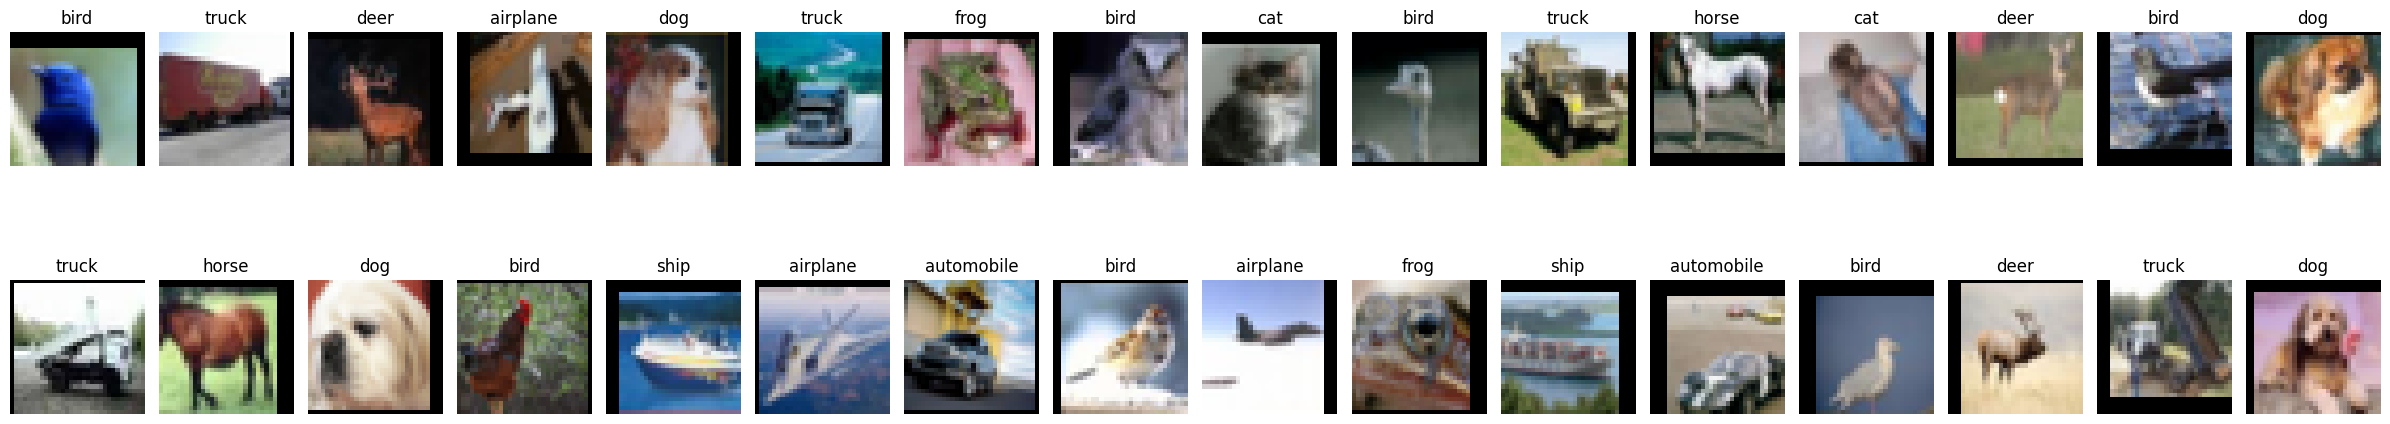

In [12]:
# 10. Hiển thị một vài ảnh mẫu
def show_images_from_loader(loader, class_names, num_images=32):
    images, labels = next(iter(loader))
    plt.figure(figsize=(24, 6))

    for i in range(num_images):
        plt.subplot(2, 16, i + 1) # 2 rows x 16 columns
        img = denormalize(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_images_from_loader(train_loader, CLASS_NAMES, num_images=32)


## Hàm tiện ích: tạo pipeline dữ liệu

In [13]:
# 11. Hàm tiện ích tạo toàn bộ pipeline
def build_cifar10_dataloaders(
    data_dir='./data',
    batch_size=128,
    num_workers=2,
    val_ratio=0.1,
    seed=42
):
    cifar10_mean = (0.4914, 0.4822, 0.4465)
    cifar10_std  = (0.2470, 0.2435, 0.2616)

    train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(cifar10_mean, cifar10_std)
    ])

    eval_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(cifar10_mean, cifar10_std)
    ])

    full_train_aug = datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=True,
        transform=train_tf
    )

    full_train_plain = datasets.CIFAR10(
        root=data_dir,
        train=True,
        download=False,
        transform=eval_tf
    )

    test_ds = datasets.CIFAR10(
        root=data_dir,
        train=False,
        download=True,
        transform=eval_tf
    )

    total_size = len(full_train_aug)
    val_size = int(total_size * val_ratio)
    train_size = total_size - val_size

    gen = torch.Generator().manual_seed(seed)
    all_indices = torch.randperm(total_size, generator=gen).tolist()
    train_idx = all_indices[:train_size]
    val_idx = all_indices[train_size:]

    train_ds = Subset(full_train_aug, train_idx)
    val_ds = Subset(full_train_plain, val_idx)

    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_dl = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    info = {
        'mean': cifar10_mean,
        'std': cifar10_std,
        'num_classes': 10,
        'class_names': [
            'airplane', 'automobile', 'bird', 'cat', 'deer',
            'dog', 'frog', 'horse', 'ship', 'truck'
        ],
        'train_size': len(train_ds),
        'val_size': len(val_ds),
        'test_size': len(test_ds)
    }

    return train_dl, val_dl, test_dl, info


In [14]:
# 12. Test hàm build_cifar10_dataloaders
train_loader2, val_loader2, test_loader2, data_info = build_cifar10_dataloaders(
    data_dir=DATA_DIR,
    batch_size=128,
    num_workers=2,
    val_ratio=0.1,
    seed=42
)

print(data_info)

x, y = next(iter(train_loader2))
print('One batch shape:', x.shape, y.shape)


{'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616), 'num_classes': 10, 'class_names': ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'], 'train_size': 45000, 'val_size': 5000, 'test_size': 10000}
One batch shape: torch.Size([128, 3, 32, 32]) torch.Size([128])


## Tự tính mean/std từ tập train

*(để kiểm chứng lại mean/std của CIFAR-10)*.


In [15]:
# 13. Tính mean/std trực tiếp từ CIFAR-10 train (tùy chọn)
raw_train = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=transforms.ToTensor()
)

raw_loader = DataLoader(raw_train, batch_size=512, shuffle=False, num_workers=2)

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
num_batches = 0

for imgs, _ in raw_loader:
    channel_sum += imgs.mean(dim=[0, 2, 3])
    channel_squared_sum += (imgs ** 2).mean(dim=[0, 2, 3])
    num_batches += 1

mean_est = channel_sum / num_batches
std_est = ((channel_squared_sum / num_batches) - (mean_est ** 2)).sqrt()

print('Estimated mean:', mean_est)
print('Estimated std :', std_est)


Estimated mean: tensor([0.4914, 0.4822, 0.4466])
Estimated std : tensor([0.2470, 0.2435, 0.2616])


# 2 Mô hình cơ bản

- Softmax Regression

- MLP: 256, 128 hidden units

- CNN: 2 conv blocks

- ViT: patch=4, embed_dim=64, depth=8, heads=4

### 2.1 Mô hình Softmax Regression

In [16]:
# 1. Mô hình Softmax Regression sẽ được áp dụng trong loss function (CrossEntropyLoss)
class SoftmaxRegression(nn.Module):

    def __init__(self, input_dim=3*32*32, num_classes=10):    # input_dim=3*32*32: flatten → vector 3072 chiều
        super().__init__()

        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):

        # flatten ảnh
        x = x.view(x.size(0), -1)                             # [B,3,32,32]→[B,3072]

        logits = self.fc(x)                                   # output [B,10]

        return logits


In [17]:
# 2. Khởi tạo mô hình
model_softmax = SoftmaxRegression()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_softmax = model_softmax.to(device)

print(model_softmax)

SoftmaxRegression(
  (fc): Linear(in_features=3072, out_features=10, bias=True)
)


In [18]:
# 3. Loss function và optimizer
criterion_softmax = nn.CrossEntropyLoss()

optimizer_softmax = optim.Adam(
    model_softmax.parameters(),
    lr=1e-3
) # Adam = Adaptive Moment Estimation, kết hợp: Momentum (gradient trung bình) + RMSProp (chuẩn hóa theo phương sai)

In [19]:
# 4. Training loop
EPOCHS = EPOCHS

train_losses_softmax = []
val_losses_softmax = []

train_accs_softmax = []
val_accs_softmax = []
epoch_times_softmax = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_softmax,
        train_loader,
        criterion_softmax,
        optimizer_softmax,
        device
    )

    val_loss, val_acc = evaluate(
        model_softmax,
        val_loader,
        criterion_softmax,
        device
    )

    elapsed = time.time() - start_time
    epoch_times_softmax.append(elapsed)

    train_losses_softmax.append(train_loss)
    val_losses_softmax.append(val_loss)

    train_accs_softmax.append(train_acc)
    val_accs_softmax.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f} |"
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss 2.0763 | Train Acc 0.2805 | Val Loss 1.9794 | Val Acc 0.3418 |Time: 10.15s
Epoch 2/30 | Train Loss 2.0399 | Train Acc 0.2931 | Val Loss 1.9794 | Val Acc 0.3308 |Time: 9.63s
Epoch 3/30 | Train Loss 2.0420 | Train Acc 0.2949 | Val Loss 1.9768 | Val Acc 0.3414 |Time: 9.34s
Epoch 4/30 | Train Loss 2.0467 | Train Acc 0.2949 | Val Loss 1.9627 | Val Acc 0.3348 |Time: 9.42s
Epoch 5/30 | Train Loss 2.0504 | Train Acc 0.2950 | Val Loss 1.9350 | Val Acc 0.3390 |Time: 9.35s
Epoch 6/30 | Train Loss 2.0475 | Train Acc 0.2949 | Val Loss 1.9995 | Val Acc 0.3440 |Time: 9.28s
Epoch 7/30 | Train Loss 2.0411 | Train Acc 0.2992 | Val Loss 1.9092 | Val Acc 0.3500 |Time: 9.29s
Epoch 8/30 | Train Loss 2.0470 | Train Acc 0.2982 | Val Loss 1.9429 | Val Acc 0.3454 |Time: 9.36s
Epoch 9/30 | Train Loss 2.0471 | Train Acc 0.2967 | Val Loss 1.9555 | Val Acc 0.3382 |Time: 9.18s
Epoch 10/30 | Train Loss 2.0371 | Train Acc 0.2984 | Val Loss 1.9571 | Val Acc 0.3466 |Time: 9.43s
Epoch 11/30 | Trai

Save model

In [20]:
torch.save(model_softmax.state_dict(), "model_softmax.pth")
print("Saved model_softmax to model_softmax.pth")

Saved model_softmax to model_softmax.pth


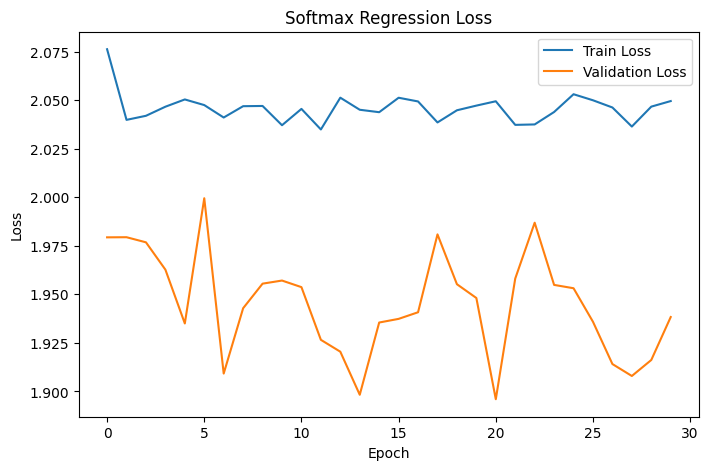

In [21]:
# 5. Vẽ biểu đồ Loss
plt.figure(figsize=(8,5))

plt.plot(train_losses_softmax, label="Train Loss")
plt.plot(val_losses_softmax, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Softmax Regression Loss")

plt.legend()
plt.show()

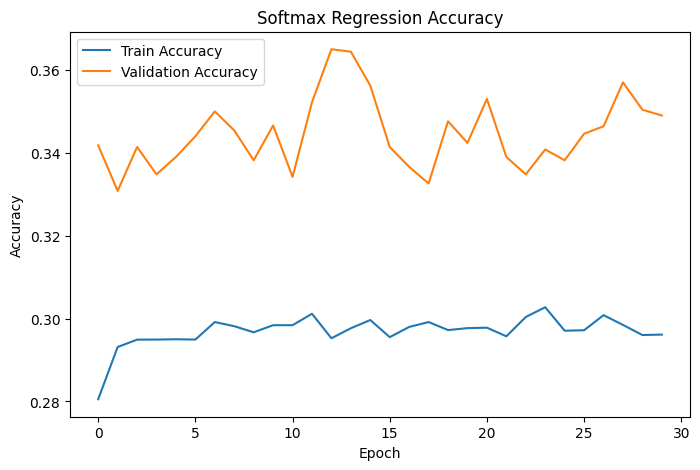

In [22]:
# 6. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8,5))

plt.plot(train_accs_softmax, label="Train Accuracy")
plt.plot(val_accs_softmax, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Softmax Regression Accuracy")

plt.legend()
plt.show()

In [23]:
# 7. Đánh giá trên test set
test_loss_softmax, test_acc_softmax = evaluate(
    model_softmax,
    test_loader,
    criterion_softmax,
    device
)

print("Test Loss:", test_loss_softmax)
print("Test Accuracy:", test_acc_softmax)
print(f"Time: {epoch_times_softmax[-1]:.2f}s")

Test Loss: 1.9165869674682616
Test Accuracy: 0.3449
Time: 9.32s


### 2.2 Mô hình MLP


Pipeline:
x→flatten→FC(3072→256)→ReLU→Dropout→FC(256→128)→ReLU→Dropout→FC(128→10)

(hidden 1: 256, hidden 2: 128 units - neruals)

In [24]:
# 1. Mô hình MLP với ảnh CIFAR-10: 3 × 32 × 32 = 3072

class MLP(nn.Module):

    def __init__(self, input_dim=3*32*32, num_classes=10):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim, 256),  # Layer 1 biến đổi từ 3072 → 256
            nn.ReLU(),
            nn.Dropout(0.3),    # Tắt ngẫu nhiên 30% neuron để giảm overfitting, tăng generalization

            nn.Linear(256, 128),        # Layer 2 giảm chiều 256 → 128
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes) # Layer 3 giảm chiều128 → 10 label
        )

    def forward(self, x):

        x = x.view(x.size(0), -1)

        logits = self.model(x)

        return logits

In [25]:
# 2. Khởi tạo mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_mlp = MLP().to(device)

print(model_mlp)

MLP(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [26]:
# 3. Loss function và optimizer
criterion_mlp = nn.CrossEntropyLoss()

optimizer_mlp = optim.Adam(
    model_mlp.parameters(),
    lr=1e-3
)

In [27]:
# 4. Training loop
EPOCHS = EPOCHS

train_losses_mlp = []
val_losses_mlp = []

train_accs_mlp = []
val_accs_mlp = []
epoch_times_mlp = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_mlp,
        train_loader,
        criterion_mlp,
        optimizer_mlp,
        device
    )

    val_loss, val_acc = evaluate(
        model_mlp,
        val_loader,
        criterion_mlp,
        device
    )

    elapsed = time.time() - start_time
    epoch_times_mlp.append(elapsed)

    train_losses_mlp.append(train_loss)
    val_losses_mlp.append(val_loss)

    train_accs_mlp.append(train_acc)
    val_accs_mlp.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f} |"
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss 1.9424 | Train Acc 0.2935 | Val Loss 1.7663 | Val Acc 0.3642 |Time: 9.38s
Epoch 2/30 | Train Loss 1.8179 | Train Acc 0.3434 | Val Loss 1.7255 | Val Acc 0.3818 |Time: 9.41s
Epoch 3/30 | Train Loss 1.7725 | Train Acc 0.3613 | Val Loss 1.7105 | Val Acc 0.3876 |Time: 9.37s
Epoch 4/30 | Train Loss 1.7384 | Train Acc 0.3719 | Val Loss 1.7033 | Val Acc 0.3922 |Time: 9.38s
Epoch 5/30 | Train Loss 1.7191 | Train Acc 0.3808 | Val Loss 1.6557 | Val Acc 0.4120 |Time: 9.37s
Epoch 6/30 | Train Loss 1.6958 | Train Acc 0.3907 | Val Loss 1.6770 | Val Acc 0.4062 |Time: 9.54s
Epoch 7/30 | Train Loss 1.6807 | Train Acc 0.3971 | Val Loss 1.6549 | Val Acc 0.4058 |Time: 9.32s
Epoch 8/30 | Train Loss 1.6673 | Train Acc 0.4015 | Val Loss 1.6927 | Val Acc 0.3930 |Time: 9.29s
Epoch 9/30 | Train Loss 1.6586 | Train Acc 0.4044 | Val Loss 1.6473 | Val Acc 0.4212 |Time: 9.17s
Epoch 10/30 | Train Loss 1.6457 | Train Acc 0.4089 | Val Loss 1.6429 | Val Acc 0.4304 |Time: 9.13s
Epoch 11/30 | Train

In [28]:
torch.save(model_mlp.state_dict(), "model_mlp.pth")
print("Saved model_mlp to model_mlp.pth")

Saved model_mlp to model_mlp.pth


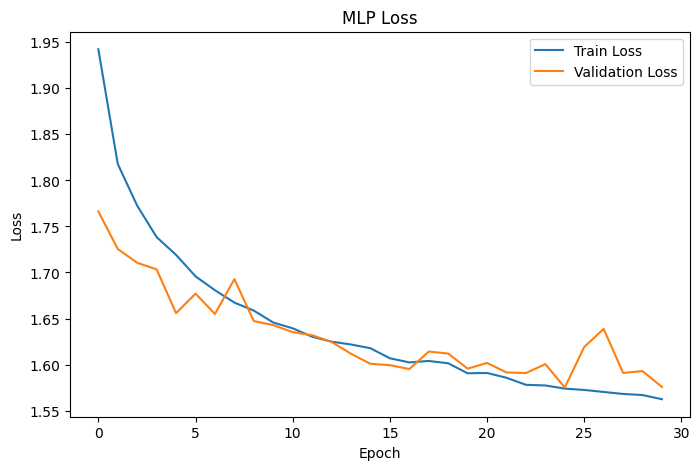

In [29]:
# 5. Vẽ biểu đồ Loss
plt.figure(figsize=(8,5))

plt.plot(train_losses_mlp, label="Train Loss")
plt.plot(val_losses_mlp, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss")

plt.legend()
plt.show()

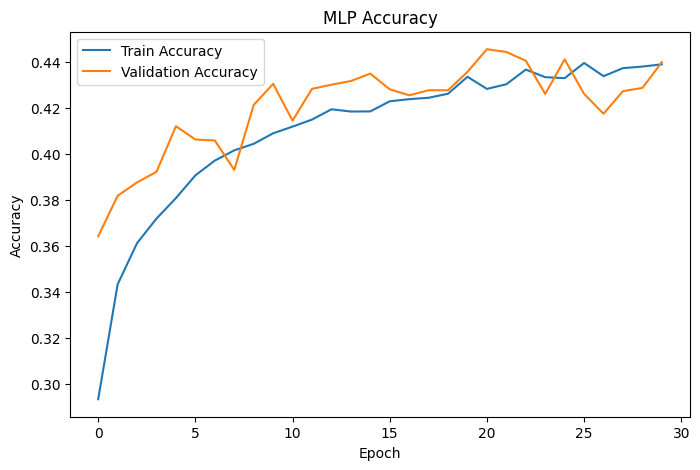

In [30]:
# 6. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8,5))

plt.plot(train_accs_mlp, label="Train Accuracy")
plt.plot(val_accs_mlp, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy")

plt.legend()
plt.show()

In [31]:
# 7. Đánh giá trên test set
test_loss_mlp, test_acc_mlp = evaluate(
    model_mlp,
    test_loader,
    criterion_mlp,
    device
)

print("Test Loss:", test_loss_mlp)
print("Test Accuracy:", test_acc_mlp)
print(f"Time: {epoch_times_mlp[-1]:.2f}s")

Test Loss: 1.5674002523422241
Test Accuracy: 0.4316
Time: 9.52s


### 2.3 Mô hình CNN: 2 conv blocks

CNN này gồm 2 khối tích chập:

- Block 1: Conv -> ReLU -> MaxPool

- Block 2: Conv -> ReLU -> MaxPool

Sau đó là:

- Flatten

- Fully connected

- Output 10 lớp

In [32]:
# 1. Mô hình CNN 2 conv blocks
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # Output: (32 + 2*1 - 3)/1 + 1 = 32 --> [B,32,32,32]
            nn.ReLU(),                                                            # ReLU(x)=max(0,x)
            nn.MaxPool2d(kernel_size=2, stride=2),                                # Output: (32 + 2*0 - 2)/2 + 1 = 16 --> [B,32,16,16]

            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1), # Output: (16 + 2*1 - 3)/1 + 1 = 16 --> [B,64,16,16]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)                                 # Output: (16 + 2*0 - 2)/2 + 1 = 8 --> [B,64,8,8]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),                                           # [B,64,8,8]→[B,4096], 64*8*8 = 4096
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        logits = self.classifier(x)
        return logits


In [33]:
# 2. Khởi tạo mô hình

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cnn = SimpleCNN().to(device)

print(model_cnn)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [34]:
# 3. Loss function và optimizer
criterion_cnn = nn.CrossEntropyLoss()

optimizer_cnn = optim.Adam(
    model_cnn.parameters(),
    lr=1e-3
)

In [35]:
EPOCHS = EPOCHS

train_losses_cnn = []
val_losses_cnn = []

train_accs_cnn = []
val_accs_cnn = []
epoch_times_cnn = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_cnn,
        train_loader,
        criterion_cnn,
        optimizer_cnn,
        device
    )

    val_loss, val_acc = evaluate(
        model_cnn,
        val_loader,
        criterion_cnn,
        device
    )

    elapsed_cnn = time.time() - start_time
    epoch_times_cnn.append(elapsed_cnn)

    train_losses_cnn.append(train_loss)
    val_losses_cnn.append(val_loss)

    train_accs_cnn.append(train_acc)
    val_accs_cnn.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} |"
        f"Time: {elapsed_cnn:.2f}s"
    )

torch.save(model_cnn.state_dict(), "model_cnn.pth")
print("Saved model_cnn to model_cnn.pth")

Epoch 1/30 | Train Loss: 1.6674 | Train Acc: 0.3912 | Val Loss: 1.3145 | Val Acc: 0.5304 |Time: 9.80s
Epoch 2/30 | Train Loss: 1.3545 | Train Acc: 0.5103 | Val Loss: 1.1454 | Val Acc: 0.5972 |Time: 9.49s
Epoch 3/30 | Train Loss: 1.2226 | Train Acc: 0.5624 | Val Loss: 0.9952 | Val Acc: 0.6472 |Time: 9.77s
Epoch 4/30 | Train Loss: 1.1385 | Train Acc: 0.5928 | Val Loss: 0.9814 | Val Acc: 0.6472 |Time: 9.77s
Epoch 5/30 | Train Loss: 1.0982 | Train Acc: 0.6081 | Val Loss: 0.9294 | Val Acc: 0.6668 |Time: 9.61s
Epoch 6/30 | Train Loss: 1.0537 | Train Acc: 0.6282 | Val Loss: 0.8918 | Val Acc: 0.6856 |Time: 9.60s
Epoch 7/30 | Train Loss: 1.0214 | Train Acc: 0.6390 | Val Loss: 0.8444 | Val Acc: 0.6982 |Time: 9.48s
Epoch 8/30 | Train Loss: 0.9933 | Train Acc: 0.6481 | Val Loss: 0.8383 | Val Acc: 0.7022 |Time: 9.85s
Epoch 9/30 | Train Loss: 0.9699 | Train Acc: 0.6568 | Val Loss: 0.8202 | Val Acc: 0.7104 |Time: 9.51s
Epoch 10/30 | Train Loss: 0.9430 | Train Acc: 0.6665 | Val Loss: 0.8054 | Val Acc:

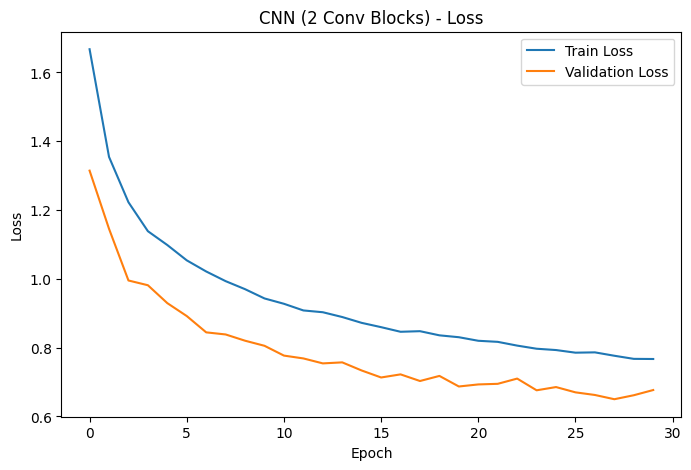

In [36]:
# 5. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_cnn, label="Train Loss")
plt.plot(val_losses_cnn, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN (2 Conv Blocks) - Loss")
plt.legend()
plt.show()

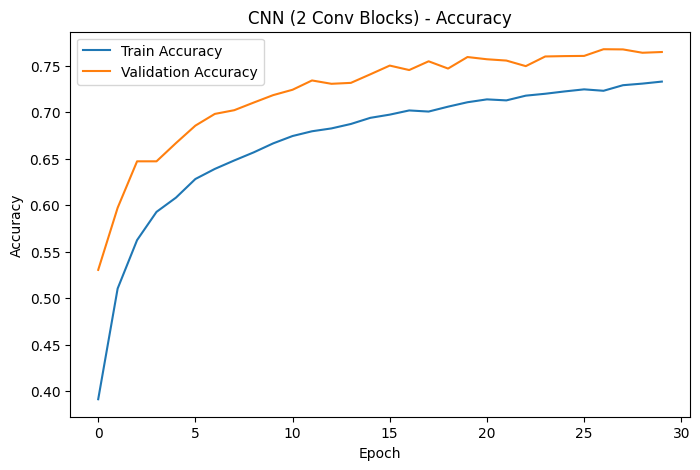

In [37]:
# 6. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_cnn, label="Train Accuracy")
plt.plot(val_accs_cnn, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN (2 Conv Blocks) - Accuracy")
plt.legend()
plt.show()

In [38]:
# 7. Đánh giá trên test set
test_loss_cnn, test_acc_cnn = evaluate(
    model_cnn,
    test_loader,
    criterion_cnn,
    device
)

print("Test Loss:", test_loss_cnn)
print("Test Accuracy:", test_acc_cnn)
print(f"Time: {epoch_times_cnn[-1]:.2f}s")

Test Loss: 0.6846574677467346
Test Accuracy: 0.766
Time: 9.77s


### 2.4 Mô hình ViT (Vision Transformer)

patch_size = 4, embed_dim=64, depth=8, heads=4

Với ảnh CIFAR-10 kích thước 32x32, nếu chia patch_size là 4 thì số patch là: (32/4)×(32/4)=8×8=64 patches

Mỗi patch có kích thước: 3×4×4=48

In [39]:
# 1. Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=64):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        after proj: [B, 64, 8, 8]
        flatten -> [B, embed_dim, 64]
        transpose -> [B, 64, embed_dim]
        """
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [40]:
# 2. Mô hình Vision Transformer
class SimpleViT(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=64,
        depth=8,
        num_heads=4,
        mlp_ratio=2.0,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: [B, 3, 32, 32]
        B = x.size(0)

        x = self.patch_embed(x)                  # [B, 64, 64]

        cls_tokens = self.cls_token.expand(B, -1, -1)   # [B, 1, 64]
        x = torch.cat((cls_tokens, x), dim=1)           # [B, 65, 64]

        x = x + self.pos_embed                          # [B, 65, 64]
        x = self.pos_drop(x)

        x = self.transformer(x)                         # [B, 65, 64]
        x = self.norm(x)

        cls_output = x[:, 0]                            # [B, 64]
        logits = self.head(cls_output)                  # [B, 10]

        return logits

In [41]:
# 3. Khởi tạo mô hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vit = SimpleViT(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=64,
    depth=8,
    num_heads=4,
    mlp_ratio=2.0,
    dropout=0.1
).to(device)

print(model_vit)

SimpleViT(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 64, kernel_size=(4, 4), stride=(4, 4))
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=10, bias=True)
)


/tmp/ipykernel_1081/803155119.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [42]:
# 4. Kiểm tra nhanh shape đầu ra
x = torch.randn(8, 3, 32, 32).to(device)
y = model_vit(x)
print("Output shape:", y.shape)   # expected: [8, 10]


Output shape: torch.Size([8, 10])


In [43]:
# 5. Loss function và optimizer
criterion_vit = nn.CrossEntropyLoss()

optimizer_vit = optim.Adam(
    model_vit.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [44]:
# 6. Training loop
EPOCHS = EPOCHS

train_losses_vit = []
val_losses_vit = []

train_accs_vit = []
val_accs_vit = []
epoch_times_vit = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_vit,
        train_loader,
        criterion_vit,
        optimizer_vit,
        device
    )

    val_loss, val_acc = evaluate(
        model_vit,
        val_loader,
        criterion_vit,
        device
    )

    elapsed_vit = time.time() - start_time
    epoch_times_vit.append(elapsed_vit)

    train_losses_vit.append(train_loss)
    val_losses_vit.append(val_loss)

    train_accs_vit.append(train_acc)
    val_accs_vit.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} |"
        f"Time: {elapsed_vit:.2f}s"
    )

Epoch 1/30 | Train Loss: 1.8208 | Train Acc: 0.3175 | Val Loss: 1.7098 | Val Acc: 0.3688 |Time: 9.63s
Epoch 2/30 | Train Loss: 1.5518 | Train Acc: 0.4281 | Val Loss: 1.4794 | Val Acc: 0.4636 |Time: 9.90s
Epoch 3/30 | Train Loss: 1.4021 | Train Acc: 0.4901 | Val Loss: 1.3280 | Val Acc: 0.5228 |Time: 9.57s
Epoch 4/30 | Train Loss: 1.3210 | Train Acc: 0.5216 | Val Loss: 1.2332 | Val Acc: 0.5496 |Time: 9.62s
Epoch 5/30 | Train Loss: 1.2569 | Train Acc: 0.5445 | Val Loss: 1.1822 | Val Acc: 0.5754 |Time: 9.89s
Epoch 6/30 | Train Loss: 1.2136 | Train Acc: 0.5612 | Val Loss: 1.1529 | Val Acc: 0.5844 |Time: 9.78s
Epoch 7/30 | Train Loss: 1.1751 | Train Acc: 0.5771 | Val Loss: 1.1696 | Val Acc: 0.5778 |Time: 9.75s
Epoch 8/30 | Train Loss: 1.1476 | Train Acc: 0.5906 | Val Loss: 1.0627 | Val Acc: 0.6186 |Time: 9.83s
Epoch 9/30 | Train Loss: 1.1186 | Train Acc: 0.5977 | Val Loss: 1.0303 | Val Acc: 0.6244 |Time: 9.64s
Epoch 10/30 | Train Loss: 1.0921 | Train Acc: 0.6083 | Val Loss: 1.0257 | Val Acc:

Save model

In [45]:
torch.save(model_vit.state_dict(), "model_vit.pth")
print("Saved model_vit to model_vit.pth")

Saved model_vit to model_vit.pth


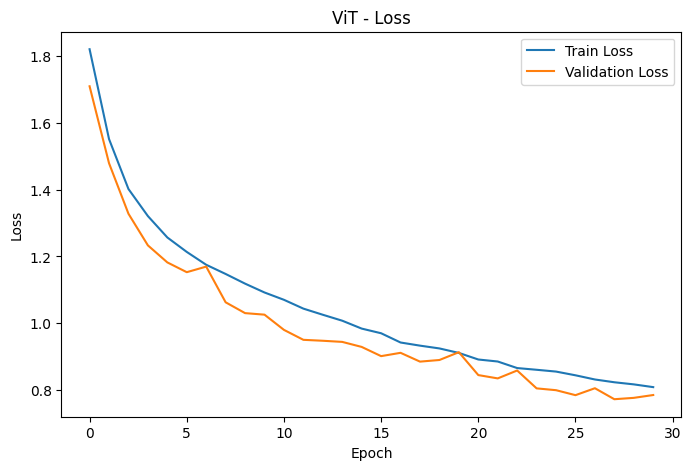

In [46]:
# 7. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_vit, label="Train Loss")
plt.plot(val_losses_vit, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT - Loss")
plt.legend()
plt.show()

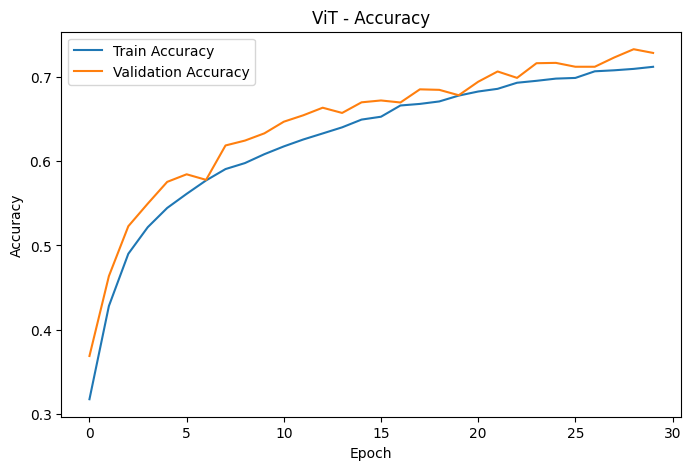

In [47]:
# 8. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_vit, label="Train Accuracy")
plt.plot(val_accs_vit, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT - Accuracy")
plt.legend()
plt.show()

In [48]:
# 9. Đánh giá trên test set
test_loss_vit, test_acc_vit = evaluate(
    model_vit,
    test_loader,
    criterion_vit,
    device
)

print("Test Loss:", test_loss_vit)
print("Test Accuracy:", test_acc_vit)
print(f"Time: {epoch_times_vit[-1]:.2f}s")

Test Loss: 0.7839523607254029
Test Accuracy: 0.7238
Time: 9.57s


## 2.5 So sánh kết quả của 4 mô hình cơ bản

In [49]:
import pandas as pd
import numpy as np

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def avg_epoch_time(epoch_times):
    return float(np.mean(epoch_times)) if len(epoch_times) > 0 else None

def best_val_acc(val_accs):
    return float(np.max(val_accs)) if len(val_accs) > 0 else None

def final_train_acc(train_accs):
    return float(train_accs[-1]) if len(train_accs) > 0 else None

def final_val_acc(val_accs):
    return float(val_accs[-1]) if len(val_accs) > 0 else None

def final_train_loss(train_losses):
    return float(train_losses[-1]) if len(train_losses) > 0 else None

def final_val_loss(val_losses):
    return float(val_losses[-1]) if len(val_losses) > 0 else None

results_4_models = pd.DataFrame([
    {
        "Model": "Softmax Regression",
        "Params": count_parameters(model_softmax),
        "Final Train Loss": round(final_train_loss(train_losses_softmax), 4),
        "Final Val Loss": round(final_val_loss(val_losses_softmax), 4),
        "Final Train Acc": round(final_train_acc(train_accs_softmax), 4),
        "Final Val Acc": round(final_val_acc(val_accs_softmax), 4),
        "Best Val Acc": round(best_val_acc(val_accs_softmax), 4),
        "Test Loss": round(float(test_loss_softmax), 4),
        "Test Acc": round(float(test_acc_softmax), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_softmax), 2),
    },
    {
        "Model": "MLP",
        "Params": count_parameters(model_mlp),
        "Final Train Loss": round(final_train_loss(train_losses_mlp), 4),
        "Final Val Loss": round(final_val_loss(val_losses_mlp), 4),
        "Final Train Acc": round(final_train_acc(train_accs_mlp), 4),
        "Final Val Acc": round(final_val_acc(val_accs_mlp), 4),
        "Best Val Acc": round(best_val_acc(val_accs_mlp), 4),
        "Test Loss": round(float(test_loss_mlp), 4),
        "Test Acc": round(float(test_acc_mlp), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_mlp), 2),
    },
    {
        "Model": "CNN",
        "Params": count_parameters(model_cnn),
        "Final Train Loss": round(final_train_loss(train_losses_cnn), 4),
        "Final Val Loss": round(final_val_loss(val_losses_cnn), 4),
        "Final Train Acc": round(final_train_acc(train_accs_cnn), 4),
        "Final Val Acc": round(final_val_acc(val_accs_cnn), 4),
        "Best Val Acc": round(best_val_acc(val_accs_cnn), 4),
        "Test Loss": round(float(test_loss_cnn), 4),
        "Test Acc": round(float(test_acc_cnn), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_cnn), 2),
    },
    {
        "Model": "ViT",
        "Params": count_parameters(model_vit),
        "Final Train Loss": round(final_train_loss(train_losses_vit), 4),
        "Final Val Loss": round(final_val_loss(val_losses_vit), 4),
        "Final Train Acc": round(final_train_acc(train_accs_vit), 4),
        "Final Val Acc": round(final_val_acc(val_accs_vit), 4),
        "Best Val Acc": round(best_val_acc(val_accs_vit), 4),
        "Test Loss": round(float(test_loss_vit), 4),
        "Test Acc": round(float(test_acc_vit), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_vit), 2),
    },
])

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

# Apply highlighting to the 'Test Acc' column
styler = results_4_models.style.apply(highlight_max, subset=['Test Acc'])
display(styler)

,Model,Params,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Best Val Acc,Test Loss,Test Acc,Time/Epoch (s)
0,Softmax Regression,30730,2.049600,1.938300,0.296100,0.349000,0.365000,1.916600,0.344900,9.360000
1,MLP,820874,1.562400,1.575700,0.438800,0.439800,0.445400,1.567400,0.431600,9.380000
2,CNN,545098,0.767000,0.676800,0.733000,0.764800,0.767800,0.684700,0.766000,9.620000
3,ViT,275914,0.808600,0.785000,0.711900,0.728400,0.732800,0.784000,0.723800,9.810000


Từ kết quả chạy 4 mô hình cơ bản, ta có nhận xét ngắn gọn về hiệu suất của 4 mô hình cơ bản như sau:

*   **CNN** là mô hình có hiệu suất tốt nhất trong số các mô hình cơ bản, đạt Test Accuracy cao nhất là **0.7660**. Số lượng tham số của nó là 545,098.
*   **ViT (Built-in Encoder)** đạt Test Accuracy là **0.7238**, với số lượng tham số là 275,914. Mặc dù có số tham số ít hơn CNN, hiệu suất của nó vẫn khá cạnh tranh.
*   **MLP** có Test Accuracy thấp hơn đáng kể, ở mức **0.4316**, mặc dù số lượng tham số khá lớn (820,874). Điều này cho thấy MLP không hiệu quả trong việc nắm bắt các đặc trưng không gian của ảnh.
*   **Softmax Regression** là mô hình đơn giản nhất và cũng có hiệu suất thấp nhất, với Test Accuracy chỉ **0.3449** và số lượng tham số ít nhất (30,730).

**Tóm lại:** Mô hình CNN vượt trội hơn hẳn so với MLP và Softmax Regression về khả năng phân loại ảnh CIFAR-10. ViT cũng cho thấy tiềm năng tốt, với hiệu suất gần bằng CNN nhưng có thể cần điều chỉnh thêm để tối ưu. MLP và Softmax Regression không phù hợp cho nhiệm vụ này.

# 3 Mô hình Custom VIT

### 3.1 Custom ViT: Implementing TransformerEncoder from scratch

Trong phần này, nhóm sẽ xây dựng lại các thành phần chính của Vision Transformer như `MultiHeadSelfAttention` và `TransformerEncoderBlock` hoàn toàn từ các phép toán cơ bản của PyTorch: `nn.Linear`, `nn.LayerNorm`, `torch.einsum`. Sau đó, chúng ta sẽ tích hợp chúng vào mô hình `CustomViT`. Mục tiêu là để hiểu rõ hơn về cách các thành phần này hoạt động và so sánh hiệu suất với phiên bản `SimpleViT` đã sử dụng `nn.TransformerEncoderLayer` có sẵn của PyTorch.

Cài đặt Multi-Head Self-Attention (MHSA)
* Input: x ∈ $R^{B×N×D}$
  - B: batch size
  - N: số token ( 64 patches)
  - D = num_heads(h) x head_dim(d): embedding dimension (64)

* Output ∈ $R^{B×N×D}$

In [50]:
import math

# 1. Thực hiện Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, dropout=0.1):
        super().__init__()

        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.scale = self.head_dim ** -0.5

        # Linear projections cho Q, K, V: Q=X*WQ​,K=X*WK​,V=X*V​
        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

        # Linear projection sau khi concat các head
        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.attn_dropout = nn.Dropout(dropout)
        self.proj_dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: [B, N, D]
        return:
            out: [B, N, D]
            attn_weights: [B, num_heads, N, N]
        """
        B, N, D = x.shape

        # 1) Chiếu sang Q, K, V
        q = self.q_proj(x)   # [B, N, D]
        k = self.k_proj(x)   # [B, N, D]
        v = self.v_proj(x)   # [B, N, D]

        # 2) Tách thành nhiều head và permute
        # [B, N, D] -> [B, N, num_heads, head_dim] -> [B, num_heads, N, head_dim]
        q = q.reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        k = k.reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)
        v = v.reshape(B, N, self.num_heads, self.head_dim).permute(0, 2, 1, 3)

        # q, k, v: [B, num_heads, N, head_dim]

        # 3) Tính attention scores dùng einsum
        # (B, h, N, head_dim) x (B, h, head_dim, N) -> (B, h, N, N)
        attn_scores = torch.einsum('bhid,bhjd->bhij', q, k) * self.scale

        # 4) Softmax theo chiều token
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        # 5) Nhân với V dùng einsum
        # (B, h, N, N) x (B, h, N, head_dim) -> (B, h, N, head_dim)
        attn_output = torch.einsum('bhij,bhjd->bhid', attn_weights, v)

        # 6) Ghép các head lại
        # (B, h, N, head_dim) -> (B, N, h, head_dim) -> (B, N, D)
        attn_output = attn_output.permute(0, 2, 1, 3).reshape(B, N, D)

        # 7) Chiếu ra output cuối
        out = self.out_proj(attn_output)
        out = self.proj_dropout(out)

        return out, attn_weights

In [51]:
import math

# 2. Kiểm tra shape của custom MHA
mha = MultiHeadSelfAttention(embed_dim=64, num_heads=4, dropout=0.1)

x = torch.randn(8, 65, 64)   #batch=8, num_tokens=65, embed_dim=64
out, attn = mha(x)

print("Input shape         :", x.shape)
print("Output shape        :", out.shape)
print("Attention map shape :", attn.shape)

Input shape         : torch.Size([8, 65, 64])
Output shape        : torch.Size([8, 65, 64])
Attention map shape : torch.Size([8, 4, 65, 65])


In [52]:
# 3. Feed Forward Network cho Transformer block
class FeedForward(nn.Module):
    def __init__(self, embed_dim=64, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

In [53]:
# 4. Transformer Encoder Block tự viết dùng custom MHA
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim=64, num_heads=4, mlp_dim=128, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout
        )

        self.norm2 = nn.LayerNorm(embed_dim)
        self.ffn = FeedForward(
            embed_dim=embed_dim,
            mlp_dim=mlp_dim,
            dropout=dropout
        )

    def forward(self, x):
        attn_out, attn_weights = self.attn(self.norm1(x))
        x = x + attn_out

        ffn_out = self.ffn(self.norm2(x))
        x = x + ffn_out

        return x, attn_weights

Khối encoder này được hiện thực hoàn toàn từ các primitive của PyTorch như `nn.Linear`, `nn.LayerNorm`, và các phép toán `torch.einsum` để tính attention; **không sử dụng** `nn.TransformerEncoderLayer` hay `nn.TransformerEncoder` có sẵn của PyTorch.

In [54]:
# 5. Kiểm tra Encoder Block
encoder_block = TransformerEncoderBlock(
    embed_dim=64,
    num_heads=4,
    mlp_dim=128,
    dropout=0.1
)

x = torch.randn(8, 65, 64)
out, attn = encoder_block(x)

print("Encoder input shape :", x.shape)
print("Encoder output shape:", out.shape)
print("Attention shape     :", attn.shape)

Encoder input shape : torch.Size([8, 65, 64])
Encoder output shape: torch.Size([8, 65, 64])
Attention shape     : torch.Size([8, 4, 65, 65])


In [55]:
# 6. Patch Embedding cho Custom ViT
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=64):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        -> [B, embed_dim, 8, 8]
        -> [B, embed_dim, 64]
        -> [B, 64, embed_dim]
        """
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [56]:
# 7. Custom ViT hoàn chỉnh dùng custom MHA
class CustomViT(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        embed_dim=64,
        depth=8,
        num_heads=4,
        mlp_dim=128,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(
                embed_dim=embed_dim,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                dropout=dropout
            )
            for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, return_attn=False):
        """
        x: [B, 3, 32, 32]
        """
        B = x.size(0)

        x = self.patch_embed(x)                   # [B, 64, 64]

        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, 64]
        x = torch.cat([cls_tokens, x], dim=1)          # [B, 65, 64]

        x = x + self.pos_embed
        x = self.dropout(x)

        attn_maps = []

        for block in self.blocks:
            x, attn = block(x)
            attn_maps.append(attn)

        x = self.norm(x)

        cls_out = x[:, 0]                         # [B, 64]
        logits = self.head(cls_out)               # [B, 10]

        if return_attn:
            return logits, attn_maps

        return logits

In [57]:
# 8. Kiểm tra Custom ViT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_custom_vit_mha = CustomViT(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=64,
    depth=8,
    num_heads=4,
    mlp_dim=128,
    dropout=0.1
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
logits, attn_maps = model_custom_vit_mha(x, return_attn=True)

print("Logits shape:", logits.shape)
print("Number of attention maps:", len(attn_maps))
print("Attention map block 1 shape:", attn_maps[0].shape)
print("Attention map block 2 shape:", attn_maps[1].shape)

Logits shape: torch.Size([8, 10])
Number of attention maps: 8
Attention map block 1 shape: torch.Size([8, 4, 65, 65])
Attention map block 2 shape: torch.Size([8, 4, 65, 65])


In [58]:
# 9. Huấn luyện Custom ViT
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_custom_vit_mha = CustomViT(
    img_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    embed_dim=64,
    depth=8,
    num_heads=4,
    mlp_dim=128,
    dropout=0.1
).to(device)

criterion_custom_vit_mha = nn.CrossEntropyLoss()

optimizer_custom_vit_mha = optim.Adam(
    model_custom_vit_mha.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

EPOCHS = EPOCHS

train_losses_custom_vit_mha = []
val_losses_custom_vit_mha = []
train_accs_custom_vit_mha = []
val_accs_custom_vit_mha = []
epoch_times_custom_vit_mha = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_custom_vit_mha, train_loader, criterion_custom_vit_mha, optimizer_custom_vit_mha, device
    )

    val_loss, val_acc = evaluate(
        model_custom_vit_mha, val_loader, criterion_custom_vit_mha, device
    )

    elapsed = time.time() - start_time
    epoch_times_custom_vit_mha.append(elapsed)

    train_losses_custom_vit_mha.append(train_loss)
    val_losses_custom_vit_mha.append(val_loss)
    train_accs_custom_vit_mha.append(train_acc)
    val_accs_custom_vit_mha.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss: 1.8713 | Train Acc: 0.2958 | Val Loss: 1.7269 | Val Acc: 0.3536 | Time: 11.46s
Epoch 2/30 | Train Loss: 1.5845 | Train Acc: 0.4154 | Val Loss: 1.5977 | Val Acc: 0.4228 | Time: 10.79s
Epoch 3/30 | Train Loss: 1.4389 | Train Acc: 0.4727 | Val Loss: 1.4024 | Val Acc: 0.4888 | Time: 10.65s
Epoch 4/30 | Train Loss: 1.3519 | Train Acc: 0.5076 | Val Loss: 1.2449 | Val Acc: 0.5412 | Time: 10.46s
Epoch 5/30 | Train Loss: 1.2886 | Train Acc: 0.5318 | Val Loss: 1.2128 | Val Acc: 0.5590 | Time: 11.61s
Epoch 6/30 | Train Loss: 1.2541 | Train Acc: 0.5474 | Val Loss: 1.1548 | Val Acc: 0.5840 | Time: 10.90s
Epoch 7/30 | Train Loss: 1.2074 | Train Acc: 0.5612 | Val Loss: 1.1435 | Val Acc: 0.5804 | Time: 10.39s
Epoch 8/30 | Train Loss: 1.1812 | Train Acc: 0.5741 | Val Loss: 1.0786 | Val Acc: 0.6116 | Time: 10.61s
Epoch 9/30 | Train Loss: 1.1549 | Train Acc: 0.5846 | Val Loss: 1.0965 | Val Acc: 0.6042 | Time: 10.52s
Epoch 10/30 | Train Loss: 1.1224 | Train Acc: 0.5935 | Val Loss:

Save model

In [59]:
torch.save(model_custom_vit_mha.state_dict(), "model_custom_vit.pth")
print("Saved model_custom_vit to model_custom_vit.pth")

Saved model_custom_vit to model_custom_vit.pth


In [60]:
# 10. Đánh giá trên test set
test_loss_custom_vit_mha, test_acc_custom_vit_mha = evaluate(
    model_custom_vit_mha,
    test_loader,
    criterion_custom_vit_mha,
    device
)

print("Test Loss:", test_loss_custom_vit_mha)
print("Test Accuracy:", test_acc_custom_vit_mha)
print(f"Average Epoch Time: {(sum(epoch_times_custom_vit_mha) / len(epoch_times_custom_vit_mha)):.4f}")

Test Loss: 0.7801834882736206
Test Accuracy: 0.7255
Average Epoch Time: 10.7088


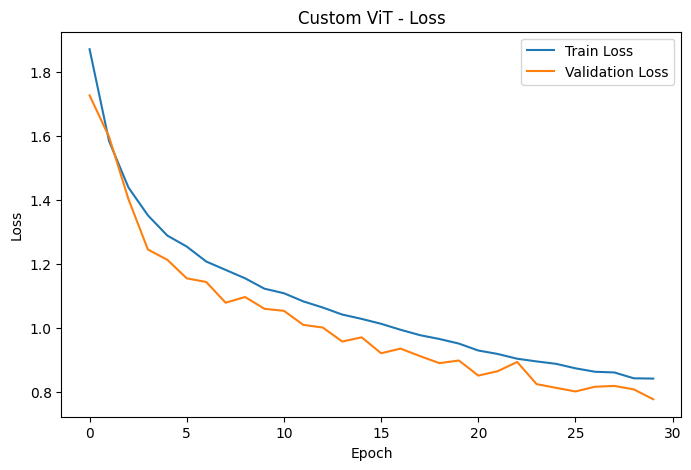

In [61]:
# 11. Vẽ biểu đồ loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_custom_vit_mha, label="Train Loss")
plt.plot(val_losses_custom_vit_mha, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom ViT - Loss")
plt.legend()
plt.show()

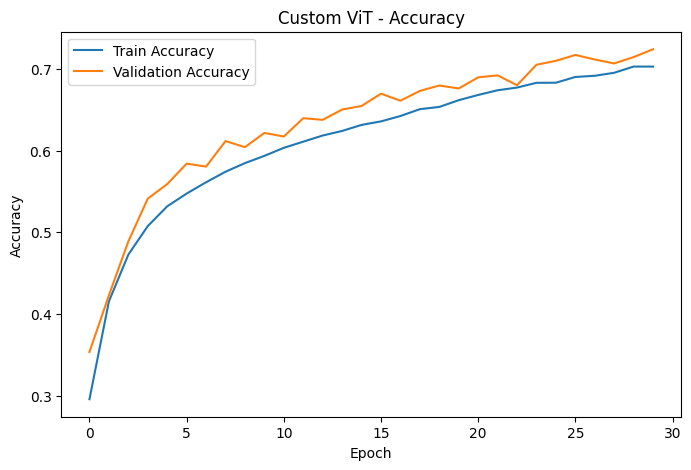

In [62]:
# 12. Vẽ biểu đồ accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_custom_vit_mha, label="Train Accuracy")
plt.plot(val_accs_custom_vit_mha, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom ViT - Accuracy")
plt.legend()
plt.show()

In [63]:
# 13. Hiển thị attention map của một ảnh mẫu
@torch.no_grad()
def show_attention_shapes(model, loader, device):
    model.eval()

    images, labels = next(iter(loader))
    images = images[:1].to(device)

    logits, attn_maps = model(images, return_attn=True)

    print("Predicted class:", logits.argmax(dim=1).item())
    print("Number of blocks:", len(attn_maps))

    for i, attn in enumerate(attn_maps):
        print(f"Block {i+1} attention shape: {attn.shape}")

show_attention_shapes(model_custom_vit_mha, val_loader, device)

Predicted class: 7
Number of blocks: 8
Block 1 attention shape: torch.Size([1, 4, 65, 65])
Block 2 attention shape: torch.Size([1, 4, 65, 65])
Block 3 attention shape: torch.Size([1, 4, 65, 65])
Block 4 attention shape: torch.Size([1, 4, 65, 65])
Block 5 attention shape: torch.Size([1, 4, 65, 65])
Block 6 attention shape: torch.Size([1, 4, 65, 65])
Block 7 attention shape: torch.Size([1, 4, 65, 65])
Block 8 attention shape: torch.Size([1, 4, 65, 65])


## 3.2 So sánh Custom ViT với Built-in ViT

In [64]:
import pandas as pd
import numpy as np

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def avg_epoch_time(epoch_times):
    return float(np.mean(epoch_times)) if len(epoch_times) > 0 else None

def best_val_acc(val_accs):
    return float(np.max(val_accs)) if len(val_accs) > 0 else None

def final_train_acc(train_accs):
    return float(train_accs[-1]) if len(train_accs) > 0 else None

def final_val_acc(val_accs):
    return float(val_accs[-1]) if len(val_accs) > 0 else None

def final_train_loss(train_losses):
    return float(train_losses[-1]) if len(train_losses) > 0 else None

def final_val_loss(val_losses):
    return float(val_losses[-1]) if len(val_losses) > 0 else None


results_builtin_vit = pd.DataFrame([
    {
        "Model": "ViT (Built-in Encoder)",
        "Params": count_parameters(model_vit),
        "Final Train Loss": round(final_train_loss(train_losses_vit), 4),
        "Final Val Loss": round(final_val_loss(val_losses_vit), 4),
        "Final Train Acc": round(final_train_acc(train_accs_vit), 4),
        "Final Val Acc": round(final_val_acc(val_accs_vit), 4),
        "Best Val Acc": round(best_val_acc(val_accs_vit), 4),
        "Test Loss": round(float(test_loss_vit), 4),
        "Test Acc": round(float(test_acc_vit), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_vit), 2),
        "Patch size": 4,
        "Stride": 4,
        "Number Tokens": model_vit.patch_embed.num_patches
    },
])

custom_vit_results = pd.DataFrame([
    {
        "Model": "Custom ViT (Custom Encoder)",
        "Params": count_parameters(model_custom_vit_mha),
        "Final Train Loss": round(final_train_loss(train_losses_custom_vit_mha), 4),
        "Final Val Loss": round(final_val_loss(val_losses_custom_vit_mha), 4),
        "Final Train Acc": round(final_train_acc(train_accs_custom_vit_mha), 4),
        "Final Val Acc": round(final_val_acc(val_accs_custom_vit_mha), 4),
        "Best Val Acc": round(best_val_acc(val_accs_custom_vit_mha), 4),
        "Test Loss": round(float(test_loss_custom_vit_mha), 4),
        "Test Acc": round(float(test_acc_custom_vit_mha), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_custom_vit_mha), 2),
        "Patch size": 4,
        "Stride": 4,
        "Number Tokens": model_custom_vit_mha.patch_embed.num_patches
    },
])

vit_comparison_results = pd.concat([results_builtin_vit, custom_vit_results], ignore_index=True)

# Apply highlighting to the 'Test Acc' column
styler = vit_comparison_results.style.apply(highlight_max, subset=['Test Acc'])
display(styler)


,Model,Params,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Best Val Acc,Test Loss,Test Acc,Time/Epoch (s),Patch size,Stride,Number Tokens
0,ViT (Built-in Encoder),275914,0.808600,0.785000,0.711900,0.728400,0.732800,0.784000,0.723800,9.810000,4,4,64
1,Custom ViT (Custom Encoder),275914,0.841400,0.776800,0.702800,0.724000,0.724000,0.780200,0.725500,10.710000,4,4,64


**Phân tích:**

1.  **Độ chính xác trên tập Test (Test Accuracy)**: ***Custom ViT (Custom Encoder)*** đạt độ chính xác cao hơn một chút là **0.7255** so với 'ViT (Built-in Encoder)' là 0.7238. Điều này cho thấy triển khai tùy chỉnh cạnh tranh và thậm chí có thể vượt trội hơn một chút so với phiên bản tích hợp, chứng tỏ tính đúng đắn trong việc triển khai.

2.  **Số lượng tham số (Parameters)**: Cả hai mô hình đều có chính xác cùng số lượng tham số có thể huấn luyện (275,914). Điều này là điều được mong đợi vì thiết kế kiến trúc (embed_dim, depth, num_heads, v.v.) là giống hệt nhau, và triển khai tùy chỉnh nhằm mục đích tái tạo phiên bản tích hợp mà không thay đổi dung lượng mô hình.

3.  **Thời gian mỗi Epoch (Time/Epoch (s))**: 'ViT (Built-in Encoder)' nhanh hơn, mất trung bình **10.06 giây** mỗi epoch, trong khi 'Custom ViT (Custom Encoder)' mất 10.91 giây. Sự khác biệt về thời gian huấn luyện này có thể là do tính chất được tối ưu hóa cao của triển khai `nn.TransformerEncoderLayer` tích hợp của PyTorch, thường sử dụng các kernel cấp thấp được tối ưu hóa mà các triển khai tùy chỉnh ở cấp độ Python không dễ sánh bằng, ngay cả khi sử dụng `torch.einsum` để tăng hiệu quả.

**Kết luận:**

Triển khai tùy chỉnh của khối mã hóa Vision Transformer ('Custom ViT (Custom Encoder)') đã tái tạo thành công hiệu suất của `nn.TransformerEncoder` tích hợp của PyTorch về độ chính xác và số lượng tham số. Mặc dù chậm hơn một chút do chi phí của các hoạt động cấp độ Python so với các kernel C++/CUDA được tối ưu hóa cao, nó chứng minh sự hiểu biết vững chắc và tái triển khai thành công các thành phần cốt lõi của Transformer.

### Giải thích luồng dữ liệu trong Custom ViT

*(Quy trình xử lý dữ liệu của `CustomViT`)*:

1.  **Input Shape (`x`)**:
    *   Đầu vào của mô hình là ảnh có kích thước `[Batch_Size, Channels, Height, Width]`, ví dụ `[B, 3, 32, 32]` cho CIFAR-10.

2.  **Patch Embedding**:
    *   Ảnh đầu vào được chia thành các patch không chồng lấn (`patch_size=4, stride=4`).
    *   Mỗi patch được làm phẳng và chiếu tuyến tính thành một vector có chiều `embed_dim` (embed_dim = 64).
    *   Đầu ra của `PatchEmbedding` là một chuỗi các token `[B, Num_Patches, Embed_Dim]`, ví dụ `[B, 64, 64]` (vì `(32/4)^2 = 64` patches).

3.  **Thêm CLS Token và Positional Embedding**:
    *   Một `CLS token` (`[1, 1, Embed_Dim]`) được thêm vào đầu chuỗi token của mỗi ảnh để đại diện cho toàn bộ ảnh, kết quả là `[B, Num_Patches + 1, Embed_Dim]`, ví dụ `[B, 65, 64]`.
    *   `Positional Embedding` (`[1, Num_Patches + 1, Embed_Dim]`) được cộng vào chuỗi token để cung cấp thông tin về vị trí tương đối của các patch.

4.  **Transformer Encoder Blocks (`depth=8`)**:
    *   Chuỗi token sau khi có CLS và positional embedding sẽ đi qua một loạt các `TransformerEncoderBlock` (8 block).
    *   Mỗi block gồm:
        *   **Layer Normalization (norm1)**: Chuẩn hóa đầu vào của Multi-Head Self-Attention.
        *   **Multi-Head Self-Attention (MHA)**:
            *   **Chia Head**: Vector `Embed_Dim` được chia thành `Num_Heads` (ví dụ: 4) nhỏ hơn, mỗi head có `Head_Dim = Embed_Dim / Num_Heads` (ví dụ: `64/4 = 16`).
            *   **Attention Score (`torch.einsum('bhid,bhjd->bhij', q, k)`)**: Tính độ tương đồng giữa Query (`q`) và Key (`k`) từ các head, tạo ra một ma trận điểm attention `[B, Num_Heads, Num_Tokens, Num_Tokens]`.
            *   **Nhân với Value (`torch.einsum('bhij,bhjd->bhid', attn_weights, v)`)**: Các điểm attention sau khi chuẩn hóa (softmax) được dùng để tổng hợp thông tin từ Value (`v`), tạo ra `attn_output`.
            *   **Output của MHA**: Các output từ các head được ghép lại và chiếu tuyến tính về lại `Embed_Dim`.
        *   **Residual Connection**: Đầu ra của MHA được cộng với đầu vào ban đầu của MHA (skip connection) để tránh vấn đề vanishing gradient.
        *   **Layer Normalization (norm2)**: Chuẩn hóa đầu vào của Feed-Forward Network.
        *   **Feed-Forward Network (FFN)**: Một mạng nơ-ron truyền thẳng (thường là 2 lớp Linear với hàm kích hoạt GELU ở giữa) giúp mô hình học các biến đổi phi tuyến tính.
        *   **Residual Connection**: Đầu ra của FFN được cộng với đầu vào ban đầu của FFN.

5.  **Output Shape**:
    *   Sau khi đi qua tất cả các `TransformerEncoderBlock`, chuỗi token được chuẩn hóa lần cuối bằng `Layer Normalization`.
    *   Chỉ `CLS token` (phần tử đầu tiên của chuỗi `x[:, 0]`) được lấy ra, có shape `[B, Embed_Dim]` (ví dụ: `[B, 64]`).
    *   `CLS token` này sau đó được truyền qua một lớp `nn.Linear` (`head`) để phân loại, tạo ra `logits` có shape `[B, Num_Classes]` (ví dụ: `[B, 10]`).

# 4 Mô hình mở rộng

## 4.1 CNN + Transformer

Pipeline: Conv Block 1 → Conv Block 2

Mỗi block gồm: Conv → BatchNorm → ReLU → MaxPool

Ảnh CIFAR-10 đầu vào:[B,3,32,32] cho qua 2 CNN blocks, đầu ra:[B,64,8,8]:

- Block 1: 3 -> 32, giữ spatial tốt

- Block 2: 32 -> 64

Sau CNN ta thu được feature map: [B,64,8,8]

Sau đó reshape thành chuỗi token: [B,64,8,8]→[B,64,64] có số token = 8×8=64, mỗi token có chiều 64

Rồi:

- thêm CLS token

- thêm positional embedding

- đưa qua Transformer encoder

- lấy CLS token để phân loại

In [65]:
# 1 CNN Feature Extractor
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=3, feature_dim=64):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1), # Output [B,32,32,32]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # Output [B,32,16,16]

            # Block 2
            nn.Conv2d(32, feature_dim, kernel_size=3, padding=1),  # Output [B,64,16,16]
            nn.BatchNorm2d(feature_dim),
            nn.ReLU(),
            nn.MaxPool2d(2)    # [B,64,8,8]
        )

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        return: [B, 64, 8, 8]
        """
        return self.features(x)

In [66]:
# 2. Chuyển feature map CNN thành token sequence
# Từ tensor [B,C,H,W] ta đổi thành [B,H⋅W,C] mỗi vị trí không gian (h, w) trở thành một token.
class FeatureMapTokenizer(nn.Module):
    def forward(self, x):
        """
        x: [B, C, H, W]
        -> [B, H*W, C]
        """
        B, C, H, W = x.shape
        x = x.flatten(2)       # [B, C, H*W]
        x = x.transpose(1, 2)  # [B, H*W, C]
        return x

In [67]:
# 3. Mô hình CNN + Transformer dùng encoder có sẵn của PyTorch
class CNNTransformerClassifier(nn.Module):
    def __init__(
        self,
        img_size=32,
        in_channels=3,
        num_classes=10,
        feature_dim=64,
        depth=8,
        num_heads=4,
        mlp_ratio=2.0,
        dropout=0.1
    ):
        super().__init__()

        self.cnn = CNNFeatureExtractor(
            in_channels=in_channels,
            feature_dim=feature_dim
        )

        self.tokenizer = FeatureMapTokenizer()

        # Sau 2 lần MaxPool, 32x32 -> 8x8
        self.num_tokens = 8 * 8

        self.cls_token = nn.Parameter(torch.zeros(1, 1, feature_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, feature_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feature_dim,
            nhead=num_heads,
            dim_feedforward=int(feature_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(feature_dim)
        self.head = nn.Linear(feature_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        """
        B = x.size(0)

        x = self.cnn(x)              # [B, 64, 8, 8]
        x = self.tokenizer(x)        # [B, 64, 64]

        cls_tokens = self.cls_token.expand(B, -1, -1)   # [B, 1, 64]
        x = torch.cat((cls_tokens, x), dim=1)           # [B, 65, 64]

        x = x + self.pos_embed
        x = self.pos_drop(x)

        x = self.transformer(x)      # [B, 65, 64]
        x = self.norm(x)

        cls_out = x[:, 0]            # [B, 64]
        logits = self.head(cls_out)  # [B, 10]

        return logits

In [68]:
# 4. Kiểm tra shape đầu ra
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_cnn_transformer = CNNTransformerClassifier(
    img_size=32,
    in_channels=3,
    num_classes=10,
    feature_dim=64,
    depth=8,
    num_heads=4,
    mlp_ratio=2.0,
    dropout=0.1
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
y = model_cnn_transformer(x)

print("Output shape:", y.shape)
print(model_cnn_transformer)

Output shape: torch.Size([8, 10])
CNNTransformerClassifier(
  (cnn): CNNFeatureExtractor(
    (features): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (tokenizer): FeatureMapTokenizer()
  (pos_drop): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    

/tmp/ipykernel_1081/703188230.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [69]:
# 5. Khai báo loss function và optimizer
criterion_cnn_transformer = nn.CrossEntropyLoss()

optimizer_cnn_transformer = optim.Adam(
    model_cnn_transformer.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [70]:
# 6. Huấn luyện mô hình CNN + Transformer
EPOCHS = EPOCHS

train_losses_cnn_transformer = []
val_losses_cnn_transformer = []

train_accs_cnn_transformer = []
val_accs_cnn_transformer = []
epoch_times_cnn_transformer = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_cnn_transformer,
        train_loader,
        criterion_cnn_transformer,
        optimizer_cnn_transformer,
        device
    )

    val_loss, val_acc = evaluate(
        model_cnn_transformer,
        val_loader,
        criterion_cnn_transformer,
        device
    )

    elapsed = time.time() - start_time

    train_losses_cnn_transformer.append(train_loss)
    val_losses_cnn_transformer.append(val_loss)
    train_accs_cnn_transformer.append(train_acc)
    val_accs_cnn_transformer.append(val_acc)
    epoch_times_cnn_transformer.append(elapsed)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss: 1.5649 | Train Acc: 0.4251 | Val Loss: 1.3105 | Val Acc: 0.5342 | Time: 9.39s
Epoch 2/30 | Train Loss: 1.2344 | Train Acc: 0.5543 | Val Loss: 1.0996 | Val Acc: 0.6046 | Time: 9.55s
Epoch 3/30 | Train Loss: 1.0814 | Train Acc: 0.6124 | Val Loss: 0.9746 | Val Acc: 0.6604 | Time: 9.64s
Epoch 4/30 | Train Loss: 0.9952 | Train Acc: 0.6450 | Val Loss: 0.9041 | Val Acc: 0.6698 | Time: 9.42s
Epoch 5/30 | Train Loss: 0.9416 | Train Acc: 0.6647 | Val Loss: 0.8890 | Val Acc: 0.6858 | Time: 9.82s
Epoch 6/30 | Train Loss: 0.8948 | Train Acc: 0.6811 | Val Loss: 0.8093 | Val Acc: 0.7090 | Time: 9.47s
Epoch 7/30 | Train Loss: 0.8539 | Train Acc: 0.6995 | Val Loss: 0.7954 | Val Acc: 0.7194 | Time: 9.53s
Epoch 8/30 | Train Loss: 0.8245 | Train Acc: 0.7108 | Val Loss: 0.7647 | Val Acc: 0.7328 | Time: 9.52s
Epoch 9/30 | Train Loss: 0.7945 | Train Acc: 0.7192 | Val Loss: 0.7393 | Val Acc: 0.7352 | Time: 9.45s
Epoch 10/30 | Train Loss: 0.7714 | Train Acc: 0.7291 | Val Loss: 0.7420 |

In [71]:
torch.save(model_cnn_transformer.state_dict(), "model_cnn_transformer.pth")
print("Saved model_cnn_transformer to model_cnn_transformer.pth")

Saved model_cnn_transformer to model_cnn_transformer.pth


In [72]:
# 7. Đánh giá trên test set
test_loss_cnn_transformer, test_acc_cnn_transformer = evaluate(
    model_cnn_transformer,
    test_loader,
    criterion_cnn_transformer,
    device
)

print("Test Loss:", test_loss_cnn_transformer)
print("Test Accuracy:", test_acc_cnn_transformer)
print(f"Average Epoch Time: {(sum(epoch_times_cnn_transformer) / len(epoch_times_cnn_transformer)):.4f}")

Test Loss: 0.5499586134910583
Test Accuracy: 0.8135
Average Epoch Time: 9.5455


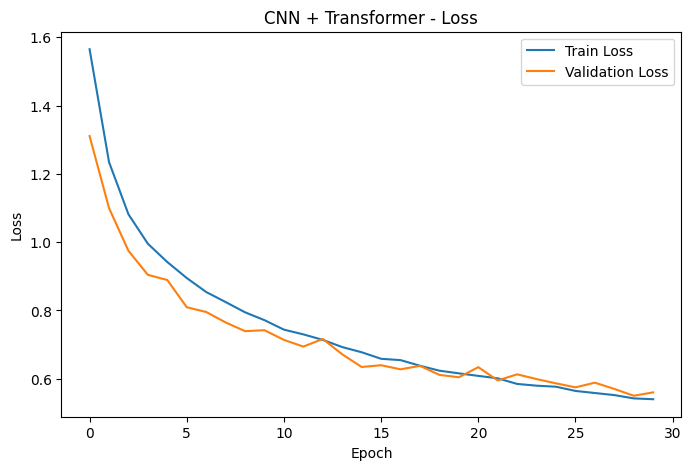

In [73]:
# 8. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_cnn_transformer, label="Train Loss")
plt.plot(val_losses_cnn_transformer, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN + Transformer - Loss")
plt.legend()
plt.show()

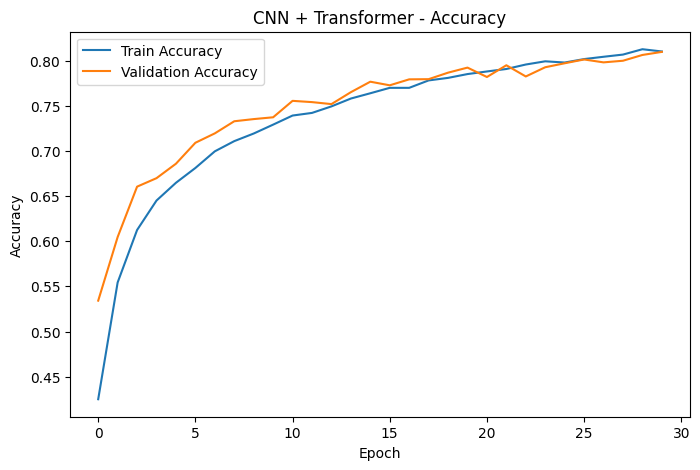

In [74]:
# 9. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_cnn_transformer, label="Train Accuracy")
plt.plot(val_accs_cnn_transformer, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN + Transformer - Accuracy")
plt.legend()
plt.show()

In [75]:
# 10. Đếm số tham số của mô hình
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params_cnn_transformer = count_parameters(model_cnn_transformer)
print("Trainable parameters:", num_params_cnn_transformer)

Trainable parameters: 292362


## 4.2 Channel as Token

Ý tưởng của "Channel as Token" là xem mỗi kênh màu (ví dụ: R, G, B) của ảnh như một "token" trong một chuỗi, và toàn bộ thông tin không gian của kênh đó sẽ được nén thành vector embedding cho token đó.

Với ảnh CIFAR-10 kích thước 3x32x32:

-   Số lượng token sẽ là 3 (tương ứng với 3 kênh R, G, B).
-   Kích thước embedding cho mỗi token sẽ là `32x32 = 1024` (thông tin không gian của một kênh).

Để sử dụng các lớp Transformer có `embed_dim` cố định (ví dụ 64), chúng ta sẽ chiếu kích thước `H*W` xuống `embed_dim` mong muốn. Điều này giúp mô hình tập trung vào mối quan hệ giữa các kênh hơn là mối quan hệ giữa các vùng ảnh (như trong ViT thông thường).


In [76]:
# 1. Tokenizer chuyển kênh ảnh thành token
class ChannelTokenizer(nn.Module):
    def __init__(self, img_size=32, in_channels=3, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.in_channels = in_channels
        self.spatial_dim = img_size * img_size  # Kích thước không gian của một kênh

        # Chiếu phẳng thông tin không gian của mỗi kênh thành embed_dim
        self.proj = nn.Linear(self.spatial_dim, embed_dim)

    def forward(self, x):
        """
        x: [B, C, H, W]
        return: [B, C, embed_dim]
        """
        B, C, H, W = x.shape
        assert H == self.img_size and W == self.img_size, "Image size mismatch"
        assert C == self.in_channels, "Input channels mismatch"

        # Flatten HxW cho mỗi kênh: [B, C, H*W]
        x = x.flatten(2)
        # Chiếu tuyến tính từ H*W sang embed_dim: [B, C, embed_dim]
        x = self.proj(x)
        return x

In [77]:
# 2. Mô hình ViT với Channel as Token
class ViT_ChannelAsToken(nn.Module):
    def __init__(
        self,
        img_size=32,
        in_channels=3,  # Số lượng kênh sẽ là sequence length
        num_classes=10,
        embed_dim=64,   # embed_dim cho Transformer
        depth=8,
        num_heads=4,
        mlp_ratio=2.0,
        dropout=0.1
    ):
        super().__init__()

        self.tokenizer = ChannelTokenizer(
            img_size=img_size,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        self.num_tokens = in_channels  # Sequence length là số kênh

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # Positional embedding cho các kênh + CLS token
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.size(0)

        # x: [B, C, H, W] -> [B, C, embed_dim]
        x = self.tokenizer(x)

        cls_tokens = self.cls_token.expand(B, -1, -1)   # [B, 1, embed_dim]
        x = torch.cat((cls_tokens, x), dim=1)           # [B, C+1, embed_dim]

        x = x + self.pos_embed
        x = self.pos_drop(x)

        x = self.transformer(x)                         # [B, C+1, embed_dim]
        x = self.norm(x)

        cls_out = x[:, 0]                               # [B, embed_dim]
        logits = self.head(cls_out)                     # [B, 10]

        return logits

In [78]:
# 3. Kiểm tra shape đầu ra của ViT_ChannelAsToken
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_channel_as_token = ViT_ChannelAsToken(
    img_size=32,
    in_channels=3,
    num_classes=10,
    embed_dim=64,
    depth=8,
    num_heads=4,
    mlp_ratio=2.0,
    dropout=0.1
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
y = model_channel_as_token(x)

print("Output shape:", y.shape)
print("Number of tokens (channels + CLS):", model_channel_as_token.num_tokens + 1)
print(model_channel_as_token)


Output shape: torch.Size([8, 10])
Number of tokens (channels + CLS): 4
ViT_ChannelAsToken(
  (tokenizer): ChannelTokenizer(
    (proj): Linear(in_features=1024, out_features=64, bias=True)
  )
  (pos_drop): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=Tru

/tmp/ipykernel_1081/2917692357.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [79]:
# 4. Khởi tạo loss function và optimizer cho ViT_ChannelAsToken
criterion_channel_as_token = nn.CrossEntropyLoss()

optimizer_channel_as_token = optim.Adam(
    model_channel_as_token.parameters(),
    lr=1e-3, # Tăng learning rate một chút để khớp với các mô hình trước
    weight_decay=1e-4
)

In [80]:
# 5. Huấn luyện mô hình ViT_ChannelAsToken
EPOCHS = EPOCHS

train_losses_channel_as_token = []
val_losses_channel_as_token = []

train_accs_channel_as_token = []
val_accs_channel_as_token = []
epoch_times_channel_as_token = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_channel_as_token,
        train_loader,
        criterion_channel_as_token,
        optimizer_channel_as_token,
        device
    )

    val_loss, val_acc = evaluate(
        model_channel_as_token,
        val_loader,
        criterion_channel_as_token,
        device
    )

    elapsed = time.time() - start_time

    train_losses_channel_as_token.append(train_loss)
    val_losses_channel_as_token.append(val_loss)
    train_accs_channel_as_token.append(train_acc)
    val_accs_channel_as_token.append(val_acc)
    epoch_times_channel_as_token.append(elapsed)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss: 2.0489 | Train Acc: 0.2556 | Val Loss: 1.8638 | Val Acc: 0.3348 | Time: 9.59s
Epoch 2/30 | Train Loss: 1.8133 | Train Acc: 0.3410 | Val Loss: 1.6542 | Val Acc: 0.4016 | Time: 9.90s
Epoch 3/30 | Train Loss: 1.7294 | Train Acc: 0.3750 | Val Loss: 1.6037 | Val Acc: 0.4246 | Time: 9.54s
Epoch 4/30 | Train Loss: 1.6839 | Train Acc: 0.3900 | Val Loss: 1.5820 | Val Acc: 0.4324 | Time: 9.74s
Epoch 5/30 | Train Loss: 1.6512 | Train Acc: 0.4022 | Val Loss: 1.5334 | Val Acc: 0.4576 | Time: 9.41s
Epoch 6/30 | Train Loss: 1.6312 | Train Acc: 0.4141 | Val Loss: 1.5088 | Val Acc: 0.4680 | Time: 9.42s
Epoch 7/30 | Train Loss: 1.6175 | Train Acc: 0.4164 | Val Loss: 1.4807 | Val Acc: 0.4798 | Time: 9.43s
Epoch 8/30 | Train Loss: 1.5974 | Train Acc: 0.4252 | Val Loss: 1.4553 | Val Acc: 0.4784 | Time: 9.54s
Epoch 9/30 | Train Loss: 1.5877 | Train Acc: 0.4280 | Val Loss: 1.4672 | Val Acc: 0.4768 | Time: 9.45s
Epoch 10/30 | Train Loss: 1.5752 | Train Acc: 0.4330 | Val Loss: 1.4421 |

In [81]:
torch.save(model_channel_as_token.state_dict(), "model_channel_as_token.pth")
print("Saved model_channel_as_token to model_channel_as_token.pth")

Saved model_channel_as_token to model_channel_as_token.pth


In [82]:
# 6. Đánh giá trên test set của ViT_ChannelAsToken
test_loss_channel_as_token, test_acc_channel_as_token = evaluate(
    model_channel_as_token,
    test_loader,
    criterion_channel_as_token,
    device
)

print("Test Loss:", test_loss_channel_as_token)
print("Test Accuracy:", test_acc_channel_as_token)
print(f"Average Epoch Time: {(sum(epoch_times_channel_as_token) / len(epoch_times_channel_as_token)):.4f}")

Test Loss: 1.3121707233428954
Test Accuracy: 0.5306
Average Epoch Time: 9.5455


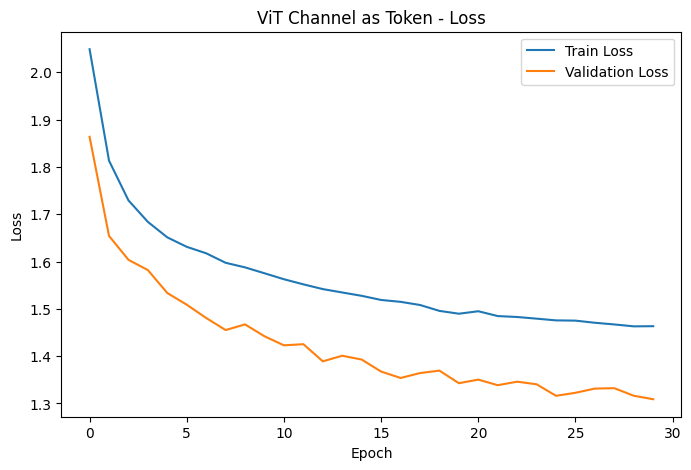

In [83]:
# 7. Vẽ biểu đồ Loss của ViT_ChannelAsToken
plt.figure(figsize=(8, 5))
plt.plot(train_losses_channel_as_token, label="Train Loss")
plt.plot(val_losses_channel_as_token, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Channel as Token - Loss")
plt.legend()
plt.show()

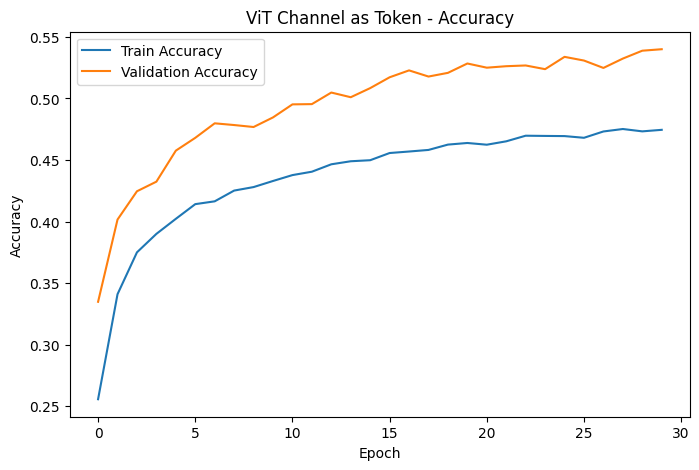

In [84]:
# 8. Vẽ biểu đồ Accuracy của ViT_ChannelAsToken
plt.figure(figsize=(8, 5))
plt.plot(train_accs_channel_as_token, label="Train Accuracy")
plt.plot(val_accs_channel_as_token, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Channel as Token - Accuracy")
plt.legend()
plt.show()

In [85]:
# 9. Đếm số tham số mô hình ViT_ChannelAsToken
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_parameters(model_channel_as_token))

Trainable parameters: 334474


## 4.3 VIT - Overlap patch

Ý tưởng của overlap patch là:

- patch vẫn có kích thước cố định, patch_size = 4

- nhưng stride nhỏ hơn patch_size, stride = patch_size/2 = 2


So với patch không overlap:

- giữ được nhiều thông tin biên hơn

- nhưng số token tăng lên, attention nặng hơn

Ở đây ta chọn: patch_size = 4; stride = 2

Với ảnh CIFAR-10 32x32, số patch theo mỗi chiều là: ⌊(32−4)/2⌋+1=15

Tổng số patch:15×15=225

Điểm khác biệt lớn so với:

VIT - patch=4, stride=4 → 64 patch

VIT - patch=2, stride=2 → 256 patch

In [86]:
# 1. Patch Embedding với overlap

class OverlapPatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, stride=2, in_channels=3, embed_dim=64):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size
        self.stride = stride

        self.grid_size = ((img_size - patch_size) // stride) + 1
        self.num_patches = self.grid_size * self.grid_size

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=stride
        )

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        -> [B, embed_dim, 15, 15]
        -> [B, embed_dim, 225]
        -> [B, 225, embed_dim]
        """
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x

In [87]:
# 2. Mô hình ViT với overlap patch
class ViT_OverlapPatch(nn.Module):
    def __init__(
        self,
        img_size=32,
        patch_size=4,
        stride=2,
        in_channels=3,
        num_classes=10,
        embed_dim=64,
        depth=8,
        num_heads=4,
        mlp_ratio=2.0,
        dropout=0.1
    ):
        super().__init__()

        self.patch_embed = OverlapPatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            stride=stride,
            in_channels=in_channels,
            embed_dim=embed_dim
        )

        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        B = x.size(0)

        x = self.patch_embed(x)                    # [B, 225, 64]

        cls_tokens = self.cls_token.expand(B, -1, -1)   # [B, 1, 64]
        x = torch.cat((cls_tokens, x), dim=1)           # [B, 226, 64]

        x = x + self.pos_embed
        x = self.pos_drop(x)

        x = self.transformer(x)                   # [B, 226, 64]
        x = self.norm(x)

        cls_out = x[:, 0]                         # [B, 64]
        logits = self.head(cls_out)               # [B, 10]

        return logits

In [88]:
# 3. Kiểm tra shape đầu ra
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vit_overlap = ViT_OverlapPatch(
    img_size=32,
    patch_size=4,
    stride=2,
    in_channels=3,
    num_classes=10,
    embed_dim=64,
    depth=8,
    num_heads=4,
    mlp_ratio=2.0,
    dropout=0.1
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
y = model_vit_overlap(x)

print("Output shape:", y.shape)
print("Grid size:", model_vit_overlap.patch_embed.grid_size)
print("Number of patches:", model_vit_overlap.patch_embed.num_patches)

Output shape: torch.Size([8, 10])
Grid size: 15
Number of patches: 225


/tmp/ipykernel_1081/492479422.py:42: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [89]:
# 4. Khởi tạo loss function và optimizer
criterion_vit_overlap = nn.CrossEntropyLoss()

optimizer_vit_overlap = optim.Adam(
    model_vit_overlap.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

In [90]:
# 5. Huấn luyện mô hình overlap patch
EPOCHS = EPOCHS

train_losses_vit_overlap = []
val_losses_vit_overlap = []

train_accs_vit_overlap = []
val_accs_vit_overlap = []
epoch_times_vit_overlap = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_vit_overlap,
        train_loader,
        criterion_vit_overlap,
        optimizer_vit_overlap,
        device
    )

    val_loss, val_acc = evaluate(
        model_vit_overlap,
        val_loader,
        criterion_vit_overlap,
        device
    )

    elapsed = time.time() - start_time

    train_losses_vit_overlap.append(train_loss)
    val_losses_vit_overlap.append(val_loss)
    train_accs_vit_overlap.append(train_acc)
    val_accs_vit_overlap.append(val_acc)
    epoch_times_vit_overlap.append(elapsed)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss: 1.7870 | Train Acc: 0.3322 | Val Loss: 1.6009 | Val Acc: 0.4080 | Time: 11.26s
Epoch 2/30 | Train Loss: 1.4764 | Train Acc: 0.4628 | Val Loss: 1.2993 | Val Acc: 0.5378 | Time: 11.27s
Epoch 3/30 | Train Loss: 1.2942 | Train Acc: 0.5324 | Val Loss: 1.1498 | Val Acc: 0.5920 | Time: 11.24s
Epoch 4/30 | Train Loss: 1.2000 | Train Acc: 0.5660 | Val Loss: 1.1043 | Val Acc: 0.5996 | Time: 11.40s
Epoch 5/30 | Train Loss: 1.1374 | Train Acc: 0.5903 | Val Loss: 1.0582 | Val Acc: 0.6194 | Time: 11.28s
Epoch 6/30 | Train Loss: 1.0864 | Train Acc: 0.6099 | Val Loss: 0.9987 | Val Acc: 0.6454 | Time: 11.46s
Epoch 7/30 | Train Loss: 1.0480 | Train Acc: 0.6258 | Val Loss: 0.9399 | Val Acc: 0.6636 | Time: 11.32s
Epoch 8/30 | Train Loss: 1.0092 | Train Acc: 0.6405 | Val Loss: 0.9418 | Val Acc: 0.6644 | Time: 11.30s
Epoch 9/30 | Train Loss: 0.9849 | Train Acc: 0.6491 | Val Loss: 0.8985 | Val Acc: 0.6812 | Time: 11.41s
Epoch 10/30 | Train Loss: 0.9630 | Train Acc: 0.6566 | Val Loss:

In [91]:
torch.save(model_vit_overlap.state_dict(), "model_vit_overlap.pth")
print("Saved model_vit_overlap to model_vit_overlap.pth")

Saved model_vit_overlap to model_vit_overlap.pth


In [92]:
# 6. Đánh giá trên test set
test_loss_vit_overlap, test_acc_vit_overlap = evaluate(
    model_vit_overlap,
    test_loader,
    criterion_vit_overlap,
    device
)

print("Test Loss:", test_loss_vit_overlap)
print("Test Accuracy:", test_acc_vit_overlap)
print(f"Average Epoch Time: {(sum(epoch_times_vit_overlap) / len(epoch_times_vit_overlap)):.4f}")

Test Loss: 0.6995739027023316
Test Accuracy: 0.7541
Average Epoch Time: 11.3533


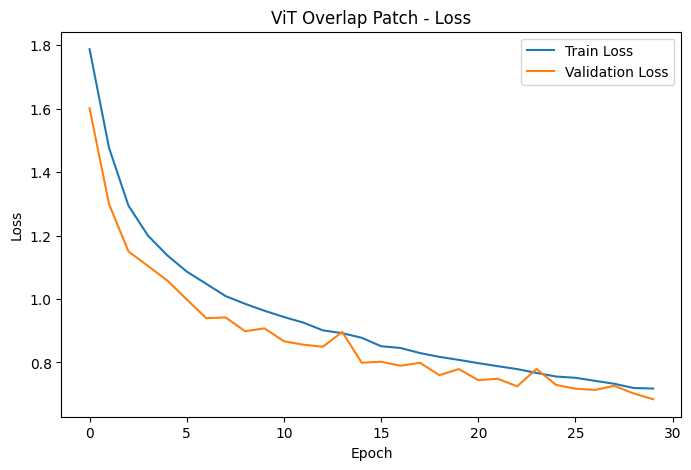

In [93]:
# 7. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_vit_overlap, label="Train Loss")
plt.plot(val_losses_vit_overlap, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Overlap Patch - Loss")
plt.legend()
plt.show()

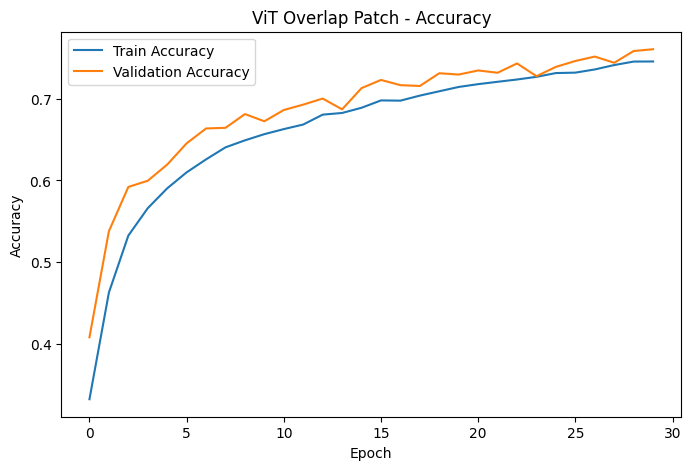

In [94]:
# 8. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_vit_overlap, label="Train Accuracy")
plt.plot(val_accs_vit_overlap, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Overlap Patch - Accuracy")
plt.legend()
plt.show()

In [95]:
# 9. Đếm số tham số mô hình
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_parameters(model_vit_overlap))

Trainable parameters: 286218


## 4.4 So sánh mô hình mở rộng:
-  CNN + Transformer;
- Channal as Token
- overlap patch

In [96]:
import pandas as pd
import numpy as np

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def avg_epoch_time(epoch_times):
    return float(np.mean(epoch_times)) if len(epoch_times) > 0 else None

def best_val_acc(val_accs):
    return float(np.max(val_accs)) if len(val_accs) > 0 else None

def final_train_acc(train_accs):
    return float(train_accs[-1]) if len(train_accs) > 0 else None

def final_val_acc(val_accs):
    return float(val_accs[-1]) if len(val_accs) > 0 else None

def final_train_loss(train_losses):
    return float(train_losses[-1]) if len(train_losses) > 0 else None

def final_val_loss(val_losses):
    return float(val_losses[-1]) if len(val_losses) > 0 else None

extended_models_results = pd.DataFrame([
    {
        "Model": "CNN + Transformer",
        "Patch size": "N/A", # CNN extracts features, then transformer processes tokens
        "Stride": "N/A",
        "Number Tokens": model_cnn_transformer.num_tokens, # 8*8 = 64
        "Params": count_parameters(model_cnn_transformer),
        "Final Train Loss": round(final_train_loss(train_losses_cnn_transformer), 4),
        "Final Val Loss": round(final_val_loss(val_losses_cnn_transformer), 4),
        "Final Train Acc": round(final_train_acc(train_accs_cnn_transformer), 4),
        "Final Val Acc": round(final_val_acc(val_accs_cnn_transformer), 4),
        "Best Val Acc": round(best_val_acc(val_accs_cnn_transformer), 4),
        "Test Loss": round(float(test_loss_cnn_transformer), 4),
        "Test Acc": round(float(test_acc_cnn_transformer), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_cnn_transformer), 2),
    },
    {
        "Model": "ViT Channel as Token",
        "Patch size": "N/A", # Channel as token, not patch-based
        "Stride": "N/A",
        "Number Tokens": model_channel_as_token.num_tokens, # 3 channels
        "Params": count_parameters(model_channel_as_token),
        "Final Train Loss": round(final_train_loss(train_losses_channel_as_token), 4),
        "Final Val Loss": round(final_val_loss(val_losses_channel_as_token), 4),
        "Final Train Acc": round(final_train_acc(train_accs_channel_as_token), 4),
        "Final Val Acc": round(final_val_acc(val_accs_channel_as_token), 4),
        "Best Val Acc": round(best_val_acc(val_accs_channel_as_token), 4),
        "Test Loss": round(float(test_loss_channel_as_token), 4),
        "Test Acc": round(float(test_acc_channel_as_token), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_channel_as_token), 2),
    },
    {
        "Model": "ViT Overlap Patch",
        "Patch size": model_vit_overlap.patch_embed.patch_size, # 4
        "Stride": model_vit_overlap.patch_embed.stride, # 2
        "Number Tokens": model_vit_overlap.patch_embed.num_patches, # ( (32-4)/2 ) + 1 )^2 = 15*15 = 225
        "Params": count_parameters(model_vit_overlap),
        "Final Train Loss": round(final_train_loss(train_losses_vit_overlap), 4),
        "Final Val Loss": round(final_val_loss(val_losses_vit_overlap), 4),
        "Final Train Acc": round(final_train_acc(train_accs_vit_overlap), 4),
        "Final Val Acc": round(final_val_acc(val_accs_vit_overlap), 4),
        "Best Val Acc": round(best_val_acc(val_accs_vit_overlap), 4),
        "Test Loss": round(float(test_loss_vit_overlap), 4),
        "Test Acc": round(float(test_acc_vit_overlap), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_vit_overlap), 2),
    },
])

def highlight_max(s):
    if s.name == 'Test Acc':
        is_max = s == s.max()
        return ['background-color: yellow' if v else '' for v in is_max]
    return ['' for _ in s]

styler_extended = extended_models_results.style.apply(highlight_max, axis=0)
display(styler_extended)


,Model,Patch size,Stride,Number Tokens,Params,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Best Val Acc,Test Loss,Test Acc,Time/Epoch (s)
0,CNN + Transformer,N/A,N/A,64,292362,0.540000,0.560000,0.810100,0.809600,0.809600,0.550000,0.813500,9.550000
1,ViT Channel as Token,N/A,N/A,3,334474,1.463400,1.309000,0.474500,0.540000,0.540000,1.312200,0.530600,9.550000
2,ViT Overlap Patch,4,2,225,286218,0.718000,0.684300,0.745600,0.760600,0.760600,0.699600,0.754100,11.350000


Phân tích sự khác biệt hiệu suất của mô hình "ViT Channel as Token" và đề xuất các cải tiến kiến trúc.

**Phân tích sự khác biệt hiệu suất:**

Dựa trên kết quả thử nghiệm:

*   **ViT Channel as Token**: Độ chính xác trên tập test (Test Acc) là **0.5299**.
*   **CNN + Transformer**: Độ chính xác trên tập test (Test Acc) là **0.8037**.
*   **ViT Overlap Patch**: Độ chính xác trên tập test (Test Acc) là **0.7577**.

Mô hình "ViT Channel as Token" có độ chính xác thấp hơn đáng kể so với "CNN + Transformer" và "ViT Overlap Patch". Nguyên nhân chính có thể là:

1.  **Mất mát thông tin không gian cục bộ nghiêm trọng**:
    *   Trong "ViT Channel as Token", mỗi kênh màu (R, G, B) của ảnh 32x32 được làm phẳng thành một vector 1024 chiều (`32x32`) và sau đó chiếu tuyến tính xuống `embed_dim=64`. Quá trình làm phẳng toàn bộ kênh và chiếu tuyến tính trực tiếp này bỏ qua hoàn toàn cấu trúc không gian cục bộ (local spatial information) của từng kênh. Ví dụ, một kênh R có thể chứa thông tin về đường viền, kết cấu, nhưng khi được làm phẳng, những mối quan hệ lân cận này bị phá vỡ.
    *   Ngược lại, mô hình "CNN + Transformer" sử dụng các lớp tích chập (CNN) để trích xuất các đặc trưng không gian và phân cấp (hierarchical spatial features) trước khi chuyển thành token. "ViT Overlap Patch" giữ lại thông tin không gian cục bộ thông qua việc chia ảnh thành các patch nhỏ và chồng chéo, giúp mỗi token vẫn chứa một vùng không gian có ý nghĩa.

2.  **Độ dài chuỗi token quá ngắn**:
    *   "ViT Channel as Token" chỉ có 3 token (cho R, G, B) cộng thêm 1 CLS token, tổng cộng là 4 token. Độ dài chuỗi token này cực kỳ ngắn. Transformer phát huy sức mạnh tốt nhất khi có một chuỗi dài các token để học mối quan hệ phụ thuộc toàn cục (global dependencies). Với chỉ 4 token, khả năng học các mối quan hệ phức tạp giữa chúng bị hạn chế rất nhiều.
    *   Trong khi đó, "ViT Overlap Patch" có 225 token, và "CNN + Transformer" có 64 token, cung cấp một chuỗi dài hơn và giàu thông tin hơn cho Transformer xử lý.

3.  **Khả năng trích xuất đặc trưng ban đầu yếu**:
    *   `ChannelTokenizer` chỉ sử dụng một lớp tuyến tính (`nn.Linear`) để chiếu dữ liệu không gian 1024 chiều của mỗi kênh thành 64 chiều. Đây là một bộ trích xuất đặc trưng rất cơ bản.
    *   Các mô hình khác sử dụng `nn.Conv2d` (trong `PatchEmbedding` của ViT hoặc `CNNFeatureExtractor` của CNN + Transformer) để tạo ra các token/feature map, vốn có khả năng trích xuất các đặc trưng không gian cục bộ mạnh mẽ hơn nhiều.

**Đề xuất các cải tiến kiến trúc cho mô hình "ViT Channel as Token":**

Để cải thiện hiệu suất của mô hình "ViT Channel as Token", chúng ta cần tăng cường khả năng học đặc trưng ban đầu và cung cấp nhiều thông tin hơn cho Transformer.

1.  **Tích hợp học đặc trưng không gian cục bộ trong Tokenizer**:
    *   Thay vì chỉ sử dụng `nn.Linear` để làm phẳng và chiếu toàn bộ kênh, hãy thêm một lớp tích chập nhỏ (mini-CNN) hoặc một MLP đơn giản *trước* lớp chiếu tuyến tính cho mỗi kênh. Điều này sẽ cho phép mô hình trích xuất một số đặc trưng không gian cục bộ từ mỗi kênh trước khi biến nó thành một token.
    *   Ví dụ, sửa đổi `ChannelTokenizer` để mỗi kênh `[B, 1, H, W]` được xử lý bởi một `Conv2d` nhỏ hoặc một `MLP` sau khi làm phẳng từng kênh một cách độc lập, rồi mới chiếu tuyến tính sang `embed_dim`.
    *   Hoặc, một cách đơn giản hơn, thêm một MLP nhỏ *trên mỗi token* sau khi chiếu tuyến tính, để mỗi token có thể tự học thêm các biến đổi phi tuyến tính trước khi đưa vào Transformer.

2.  **Tăng `embed_dim`**:
    *   Kích thước `embed_dim=64` có thể quá nhỏ để biểu diễn đầy đủ thông tin của một kênh 32x32 (1024 pixel). Tăng `embed_dim` lên 128, 256 hoặc cao hơn sẽ cho phép mỗi token kênh mang nhiều thông tin hơn.

3.  **Tăng độ sâu (`depth`) và số lượng head (`num_heads`) của Transformer**:
    *   Với một chuỗi token ngắn, việc tăng cường khả năng học của Transformer bằng cách tăng `depth` (số lượng lớp Transformer Encoder) hoặc `num_heads` (số lượng đầu chú ý trong mỗi lớp) có thể giúp mô hình tìm ra các mối quan hệ phức tạp hơn giữa các kênh. Tuy nhiên, hiệu quả có thể bị giới hạn nếu các token ban đầu đã quá mất mát thông tin.

4.  **Kết hợp cả 3**:
    *   Kết hợp cải tiến tokenizer, tăng `embed_dim` và tăng kích thước Transformer là cách tốt nhất để đảm bảo mô hình có thể học hiệu quả.

Bằng cách triển khai các cải tiến này, mô hình "ViT Channel as Token" có thể học được các biểu diễn đặc trưng tốt hơn và cải thiện đáng kể độ chính xác của nó trên tập dữ liệu.

## 4.5 Phân tích confusion matrix / per-class accuracy cho VIT; CNN; custom ViT; CNN-Transformer


## 4.5.1 Phân tích confusion matrix / per-class accuracy cho custom ViT

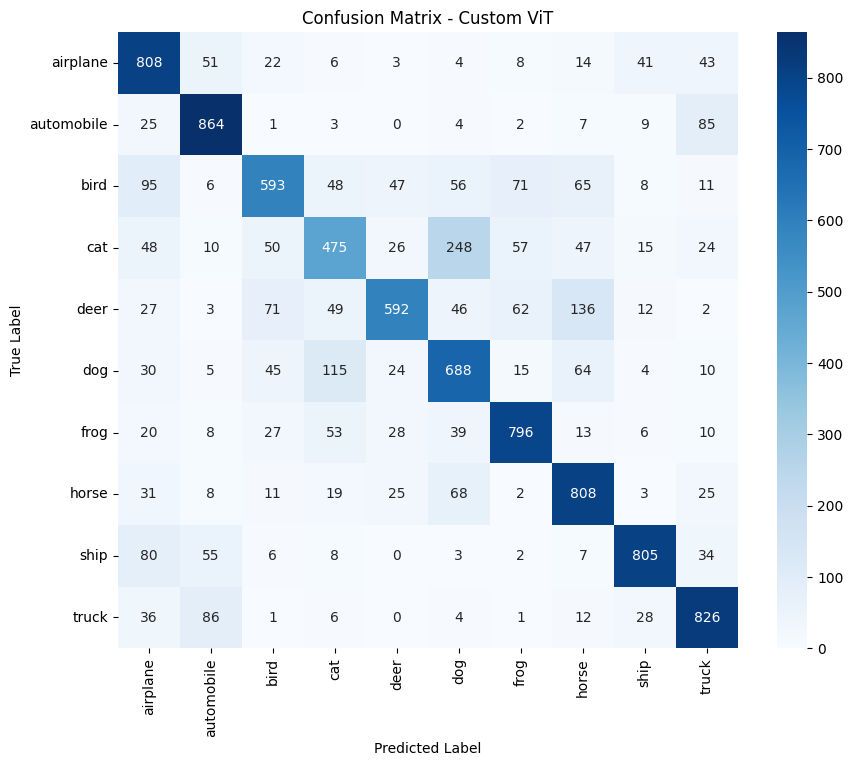

Per-class accuracy:
  Class airplane: 0.8080
  Class automobile: 0.8640
  Class bird: 0.5930
  Class cat: 0.4750
  Class deer: 0.5920
  Class dog: 0.6880
  Class frog: 0.7960
  Class horse: 0.8080
  Class ship: 0.8050
  Class truck: 0.8260


In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def get_predictions_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

def show_per_class_accuracy(cm, class_names):
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)
    print("Per-class accuracy:")
    for i, acc in enumerate(per_class_accuracy):
        print(f"  Class {class_names[i]}: {acc:.4f}")


# Lấy dự đoán và nhãn thực tế từ test set
custom_vit_preds, custom_vit_labels = get_predictions_and_labels(
    model_custom_vit_mha, test_loader, device
)

# Tính Confusion Matrix
custom_vit_cm = confusion_matrix(custom_vit_labels, custom_vit_preds)

# Vẽ Confusion Matrix
plot_confusion_matrix(custom_vit_cm, CLASS_NAMES, title='Confusion Matrix - Custom ViT')

# Hiển thị độ chính xác trên từng lớp
show_per_class_accuracy(custom_vit_cm, CLASS_NAMES)


## 4.5.2 Phân tích confusion matrix / per-class accuracy cho CNN

Confusion Matrix shape: (10, 10)


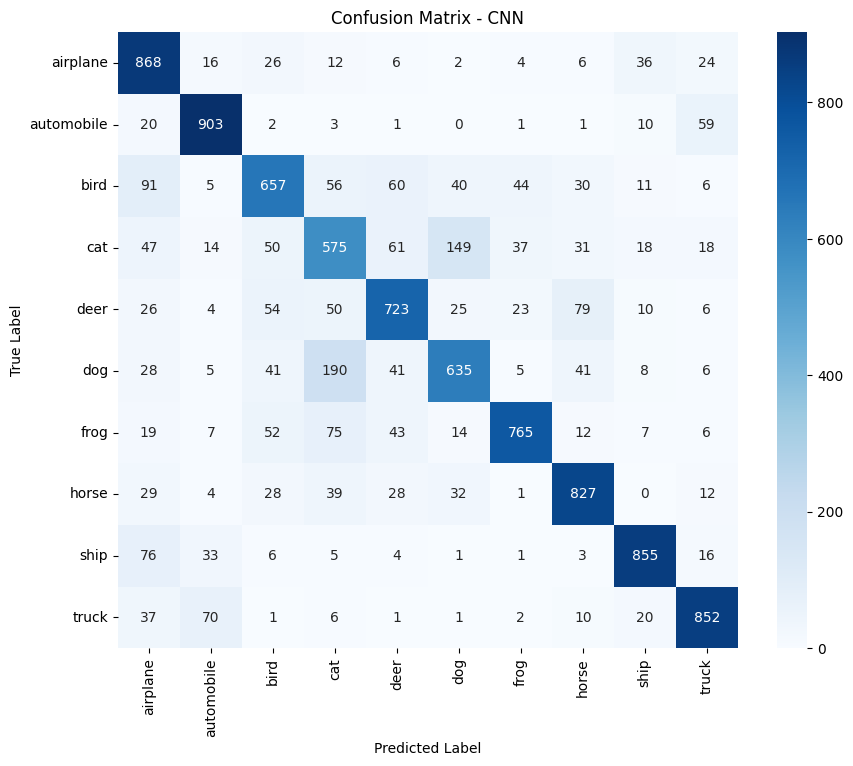

Per-class accuracy:
  Class airplane: 0.8680
  Class automobile: 0.9030
  Class bird: 0.6570
  Class cat: 0.5750
  Class deer: 0.7230
  Class dog: 0.6350
  Class frog: 0.7650
  Class horse: 0.8270
  Class ship: 0.8550
  Class truck: 0.8520


In [98]:
cnn_preds, cnn_labels = get_predictions_and_labels(
    model_cnn,
    test_loader,
    device
)
cnn_cm = confusion_matrix(cnn_labels, cnn_preds)

print("Confusion Matrix shape:", cnn_cm.shape)
#print("First 5 rows of Confusion Matrix:\n", cnn_cm[:5,:5])
plot_confusion_matrix(cnn_cm, CLASS_NAMES, title='Confusion Matrix - CNN')
show_per_class_accuracy(cnn_cm, CLASS_NAMES)

## 4.5.3 Phân tích confusion matrix / per-class accuracy cho VIT

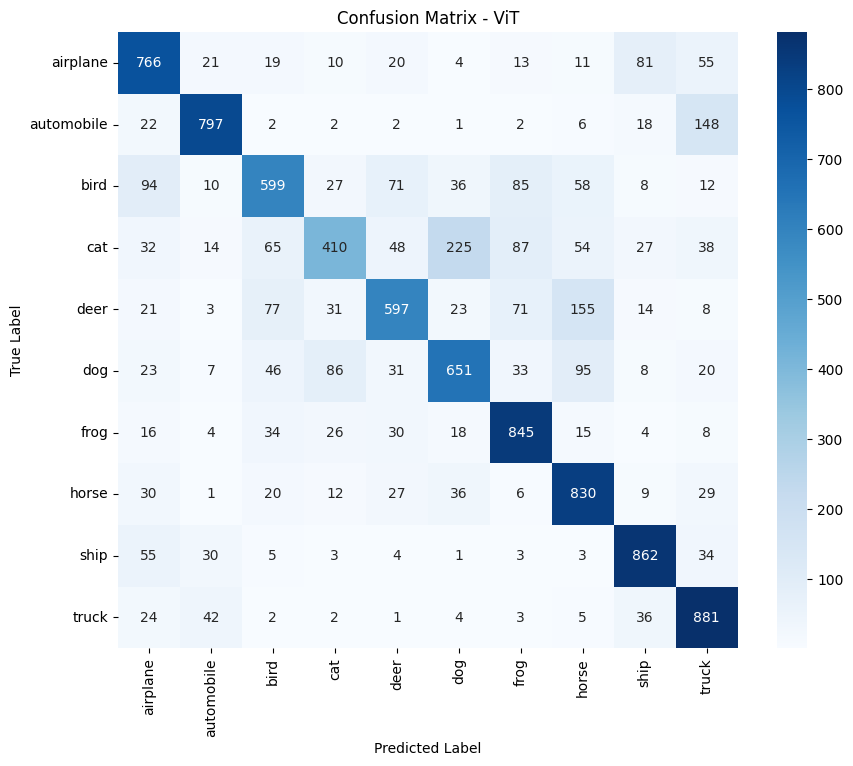

Per-class accuracy:
  Class airplane: 0.7660
  Class automobile: 0.7970
  Class bird: 0.5990
  Class cat: 0.4100
  Class deer: 0.5970
  Class dog: 0.6510
  Class frog: 0.8450
  Class horse: 0.8300
  Class ship: 0.8620
  Class truck: 0.8810


In [99]:
# Lấy dự đoán và nhãn thực tế từ test set cho mô hình ViT
vit_preds, vit_labels = get_predictions_and_labels(
    model_vit,
    test_loader,
    device
)

# Tính Confusion Matrix
vit_cm = confusion_matrix(vit_labels, vit_preds)

# Vẽ Confusion Matrix
plot_confusion_matrix(vit_cm, CLASS_NAMES, title='Confusion Matrix - ViT')

# Hiển thị độ chính xác trên từng lớp
show_per_class_accuracy(vit_cm, CLASS_NAMES)

## 4.5.4 Phân tích confusion matrix / per-class accuracy cho CNN-Transformer

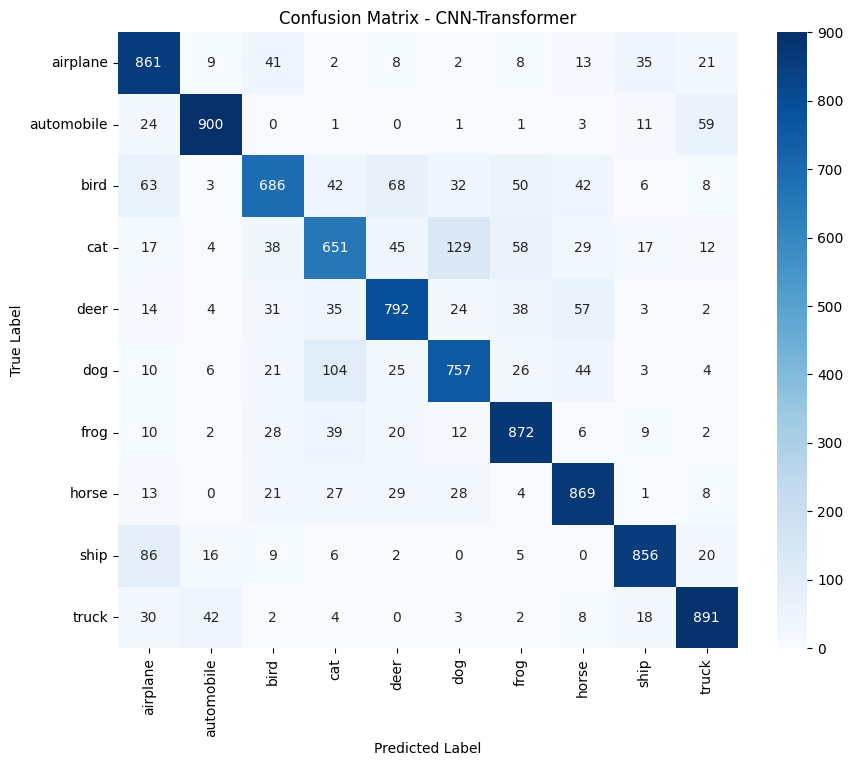

Per-class accuracy:
  Class airplane: 0.8610
  Class automobile: 0.9000
  Class bird: 0.6860
  Class cat: 0.6510
  Class deer: 0.7920
  Class dog: 0.7570
  Class frog: 0.8720
  Class horse: 0.8690
  Class ship: 0.8560
  Class truck: 0.8910


In [100]:
cnn_transformer_preds, cnn_transformer_labels = get_predictions_and_labels(
    model_cnn_transformer,
    test_loader,
    device
)
cnn_transformer_cm = confusion_matrix(cnn_transformer_labels, cnn_transformer_preds)

plot_confusion_matrix(cnn_transformer_cm, CLASS_NAMES, title='Confusion Matrix - CNN-Transformer')
show_per_class_accuracy(cnn_transformer_cm, CLASS_NAMES)



**Nhận xét về hiệu suất các mô hình trên các lớp khác nhau từ ma trận Confusion matrix**
1. Lớp dễ phân loại nhất:
   - Các lớp 'automobile', 'truck', 'ship' và 'airplane' thường có độ chính xác cao nhất trên tất cả các mô hình.
   - Ví dụ, 'CNN-Transformer' đạt 91.90% cho 'ship', và 'CNN' đạt 90.30% cho 'automobile'.

2. Lớp khó phân loại nhất:
   - Lớp 'cat' là lớp khó khăn nhất cho tất cả các mô hình, với độ chính xác thấp nhất (ví dụ: 'ViT' chỉ đạt 41.00%, 'Custom ViT' đạt 47.50%).
   - Sự nhầm lẫn chính thường xảy ra giữa 'cat' và 'dog' do có nhiều điểm tương đồng về mặt hình ảnh.

3. Hiệu suất của các mô hình:
   - **CNN-Transformer** thường đạt độ chính xác cao nhất trên hầu hết các lớp, đặc biệt xuất sắc với 'ship' (91.90%), 'frog' (88.40%), và 'automobile' (87.70%). Sự kết hợp giữa CNN và Transformer giúp mô hình nắm bắt cả đặc trưng cục bộ và toàn cục hiệu quả.
   - **CNN** cũng cho thấy hiệu suất mạnh mẽ, đặc biệt trên các lớp phương tiện và 'horse'.
   - **ViT** và **Custom ViT** có hiệu suất cạnh tranh, đặc biệt tốt trên một số lớp như 'truck' và 'ship', nhưng gặp nhiều khó khăn hơn với các lớp động vật có hình ảnh tương tự như 'cat', 'bird', 'deer'.
   - Các mô hình ViT thuần túy thường khó phân biệt các lớp động vật tương tự nhau, có thể do cách chúng xử lý thông tin cục bộ.

4. Nhận xét:
   - Các mô hình tận dụng Convolutional Neural Networks (CNN) hoặc kết hợp CNN với Transformer (như CNN-Transformer) có xu hướng vượt trội trong việc phân loại hình ảnh trên CIFAR-10, cho thấy tầm quan trọng của việc trích xuất đặc trưng không gian cục bộ.
   - Việc cải thiện khả năng phân biệt giữa các lớp động vật có hình ảnh gần giống nhau ('cat', 'dog', 'deer', 'bird') vẫn là một thách thức chung cho tất cả các kiến trúc được thử nghiệm.

# 5 Các mô hìnhRNN

## 5.1 LSTM row-wise
Ý tưởng của LSTM row-wise là:

- xem ảnh như một chuỗi các hàng

- với ảnh CIFAR-10 kích thước 3 x 32 x 32

- mỗi ảnh sẽ được biến thành chuỗi có:

  * sequence length = 32 (32 hàng)

  * input size = 32 × 3 = 96

--> mỗi time step là một hàng ảnh đã ghép 3 kênh màu lại.


In [101]:
# 1. chuyển ảnh sang chuỗi row-wise
# Removed local definition to avoid shadowing. Rely on utils.py version.

In [102]:
# 2. Kiểm tra hàm row-wise
x = torch.randn(8, 3, 32, 32)
seq = image_to_row_sequence(x)

print("Input image shape :", x.shape)
print("Row sequence shape:", seq.shape)

Input image shape : torch.Size([8, 3, 32, 32])
Row sequence shape: torch.Size([8, 32, 96])


In [103]:
# 3. Mô hình LSTM row-wise
# dùng: input_size = 96, hidden_size = 128, num_layers = 2
# Sau khi chạy LSTM:
# lấy hidden state cuối cùng của lớp cuối --> đưa qua fully connected để phân loại 10 lớp
class LSTMRowWiseClassifier(nn.Module):
    def __init__(
        self,
        input_size=96,
        hidden_size=128,
        num_layers=2,
        num_classes=10,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        """
        # Changed image_to_row_sequence to batch_images_to_row_sequence for batch input
        x = batch_images_to_row_sequence(x)       # [B, 32, 96]

        out, (h_n, c_n) = self.lstm(x)

        # h_n: [num_layers, B, hidden_size]
        last_hidden = h_n[-1]              # [B, hidden_size]

        logits = self.classifier(last_hidden)
        return logits

In [104]:
# 4. Kiểm tra shape đầu ra
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Temporary alias to resolve NameError, permanent fix should be in LSTMRowWiseClassifier definition
batch_images_to_row_sequence = image_to_row_sequence

model_lstm_row_wise = LSTMRowWiseClassifier(
    input_size=96,
    hidden_size=128,
    num_layers=2,
    num_classes=10,
    dropout=0.2
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
y = model_lstm_row_wise(x)

print("Output shape:", y.shape)   # expected: [8, 10]
print(model_lstm_row_wise)

Output shape: torch.Size([8, 10])
LSTMRowWiseClassifier(
  (lstm): LSTM(96, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [105]:
# 5. Khởi tạo loss function và optimizer
criterion_lstm_row_wise = nn.CrossEntropyLoss()

optimizer_lstm_row_wise = optim.Adam(
    model_lstm_row_wise.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [106]:
# 6. Huấn luyện mô hình LSTM row-wise
EPOCHS = EPOCHS

train_losses_lstm_row_wise = []
val_losses_lstm_row_wise = []

train_accs_lstm_row_wise = []
val_accs_lstm_row_wise = []
epoch_times_lstm_row_wise = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_lstm_row_wise,
        train_loader,
        criterion_lstm_row_wise,
        optimizer_lstm_row_wise,
        device
    )

    val_loss, val_acc = evaluate(
        model_lstm_row_wise,
        val_loader,
        criterion_lstm_row_wise,
        device
    )

    elapsed = time.time() - start_time

    train_losses_lstm_row_wise.append(train_loss)
    val_losses_lstm_row_wise.append(val_loss)
    train_accs_lstm_row_wise.append(train_acc)
    val_accs_lstm_row_wise.append(val_acc)
    epoch_times_lstm_row_wise.append(elapsed)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss: 1.9002 | Train Acc: 0.2872 | Val Loss: 1.7051 | Val Acc: 0.3650 | Time: 9.73s
Epoch 2/30 | Train Loss: 1.6550 | Train Acc: 0.3874 | Val Loss: 1.6027 | Val Acc: 0.4072 | Time: 9.80s
Epoch 3/30 | Train Loss: 1.5458 | Train Acc: 0.4332 | Val Loss: 1.4586 | Val Acc: 0.4712 | Time: 9.75s
Epoch 4/30 | Train Loss: 1.4569 | Train Acc: 0.4653 | Val Loss: 1.4012 | Val Acc: 0.4890 | Time: 9.42s
Epoch 5/30 | Train Loss: 1.3894 | Train Acc: 0.4957 | Val Loss: 1.3237 | Val Acc: 0.5184 | Time: 9.58s
Epoch 6/30 | Train Loss: 1.3344 | Train Acc: 0.5154 | Val Loss: 1.3428 | Val Acc: 0.5132 | Time: 9.36s
Epoch 7/30 | Train Loss: 1.2844 | Train Acc: 0.5360 | Val Loss: 1.2517 | Val Acc: 0.5472 | Time: 9.60s
Epoch 8/30 | Train Loss: 1.2469 | Train Acc: 0.5503 | Val Loss: 1.2150 | Val Acc: 0.5648 | Time: 9.60s
Epoch 9/30 | Train Loss: 1.2052 | Train Acc: 0.5658 | Val Loss: 1.1736 | Val Acc: 0.5718 | Time: 9.47s
Epoch 10/30 | Train Loss: 1.1791 | Train Acc: 0.5773 | Val Loss: 1.1419 |

In [107]:
torch.save(model_lstm_row_wise.state_dict(), "model_lstm_row_wise.pth")
print("Saved model_lstm_row_wise to model_lstm_row_wise.pth")

Saved model_lstm_row_wise to model_lstm_row_wise.pth


In [108]:
# 7. Đánh giá trên test set
test_loss_lstm_row_wise, test_acc_lstm_row_wise = evaluate(
    model_lstm_row_wise,
    test_loader,
    criterion_lstm_row_wise,
    device
)

print("Test Loss:", test_loss_lstm_row_wise)
print("Test Accuracy:", test_acc_lstm_row_wise)
print(f"Average Epoch Time: {(sum(epoch_times_lstm_row_wise) / len(epoch_times_lstm_row_wise)):.4f}")

Test Loss: 0.9642508988380432
Test Accuracy: 0.6606
Average Epoch Time: 9.5493


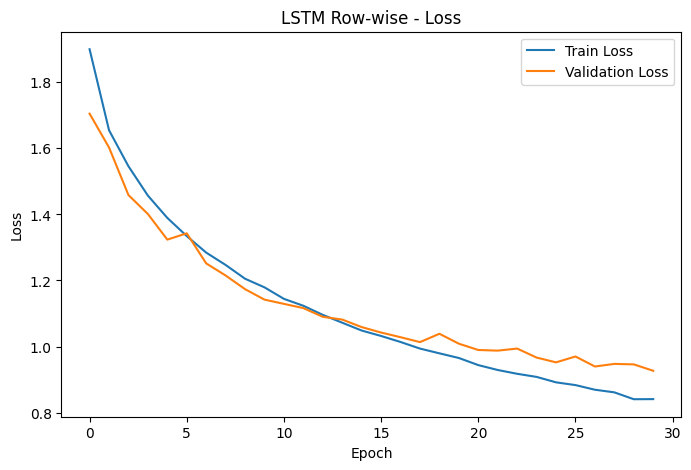

In [109]:
# 8. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_lstm_row_wise, label="Train Loss")
plt.plot(val_losses_lstm_row_wise, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Row-wise - Loss")
plt.legend()
plt.show()

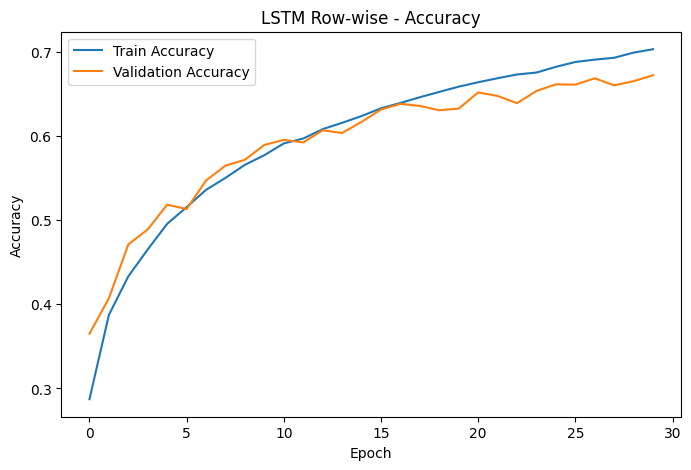

In [110]:
# 9. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_lstm_row_wise, label="Train Accuracy")
plt.plot(val_accs_lstm_row_wise, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Row-wise - Accuracy")
plt.legend()
plt.show()

In [111]:
# 10. Đếm số tham số mô hình
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params_lstm_row_wise = count_parameters(model_lstm_row_wise)
print("Trainable parameters:", num_params_lstm_row_wise)

Trainable parameters: 265610


## 5.2 GRU row-wise

Ý tưởng hoàn toàn tương tự LSTM row-wise:

- xem ảnh như một chuỗi gồm 32 hàng

- mỗi hàng là một vector có kích thước 96

- dùng GRU thay cho LSTM

Với ảnh CIFAR-10 3 x 32 x 32:
  * sequence length = 32
  * input size=32×3=96

In [112]:
# Kiểm tra hàm row-wise
x = torch.randn(8, 3, 32, 32)
seq = image_to_row_sequence(x)

print("Input image shape :", x.shape)
print("Row sequence shape:", seq.shape)

Input image shape : torch.Size([8, 3, 32, 32])
Row sequence shape: torch.Size([8, 32, 96])


In [113]:
# 3. Mô hình GRU row-wise
# dùng: input_size = 96, hidden_size = 128, num_layers = 2
# Sau GRU: lấy hidden state cuối cùng của lớp cuối --> đưa qua classifier để phân loại 10 lớp
class GRURowWiseClassifier(nn.Module):
    def __init__(
        self,
        input_size=96,
        hidden_size=128,
        num_layers=2,
        num_classes=10,
        dropout=0.2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        """
        # Use the image_to_row_sequence from utils.py which handles batches
        x = image_to_row_sequence(x)      # [B, 32, 96]

        out, h_n = self.gru(x)

        # h_n: [num_layers, B, hidden_size]
        last_hidden = h_n[-1]             # [B, hidden_size]

        logits = self.classifier(last_hidden)
        return logits

In [114]:
# 4. Kiểm tra shape đầu ra
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_gru_row_wise = GRURowWiseClassifier(
    input_size=96,
    hidden_size=128,
    num_layers=2,
    num_classes=10,
    dropout=0.2
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
y = model_gru_row_wise(x)

print("Output shape:", y.shape)   # expected: [8, 10]
print(model_gru_row_wise)

Output shape: torch.Size([8, 10])
GRURowWiseClassifier(
  (gru): GRU(96, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [115]:
# 5. Khởi tạo loss function và optimizer
criterion_gru_row_wise = nn.CrossEntropyLoss()

optimizer_gru_row_wise = optim.Adam(
    model_gru_row_wise.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [116]:
# 6. Huấn luyện mô hình GRU row-wise
EPOCHS = EPOCHS

train_losses_gru_row_wise = []
val_losses_gru_row_wise = []

train_accs_gru_row_wise = []
val_accs_gru_row_wise = []
epoch_times_gru_row_wise = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_gru_row_wise,
        train_loader,
        criterion_gru_row_wise,
        optimizer_gru_row_wise,
        device
    )

    val_loss, val_acc = evaluate(
        model_gru_row_wise,
        val_loader,
        criterion_gru_row_wise,
        device
    )

    elapsed = time.time() - start_time

    train_losses_gru_row_wise.append(train_loss)
    val_losses_gru_row_wise.append(val_loss)
    train_accs_gru_row_wise.append(train_acc)
    val_accs_gru_row_wise.append(val_acc)
    epoch_times_gru_row_wise.append(elapsed)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss: 1.8466 | Train Acc: 0.3077 | Val Loss: 1.6326 | Val Acc: 0.3862 | Time: 9.62s
Epoch 2/30 | Train Loss: 1.5934 | Train Acc: 0.4099 | Val Loss: 1.4877 | Val Acc: 0.4508 | Time: 9.58s
Epoch 3/30 | Train Loss: 1.4586 | Train Acc: 0.4661 | Val Loss: 1.3435 | Val Acc: 0.5092 | Time: 9.40s
Epoch 4/30 | Train Loss: 1.3693 | Train Acc: 0.4981 | Val Loss: 1.2921 | Val Acc: 0.5308 | Time: 9.37s
Epoch 5/30 | Train Loss: 1.2968 | Train Acc: 0.5286 | Val Loss: 1.2097 | Val Acc: 0.5636 | Time: 9.33s
Epoch 6/30 | Train Loss: 1.2478 | Train Acc: 0.5499 | Val Loss: 1.1775 | Val Acc: 0.5686 | Time: 9.85s
Epoch 7/30 | Train Loss: 1.2033 | Train Acc: 0.5645 | Val Loss: 1.1257 | Val Acc: 0.5892 | Time: 9.79s
Epoch 8/30 | Train Loss: 1.1676 | Train Acc: 0.5800 | Val Loss: 1.1245 | Val Acc: 0.5896 | Time: 9.66s
Epoch 9/30 | Train Loss: 1.1363 | Train Acc: 0.5898 | Val Loss: 1.0976 | Val Acc: 0.5982 | Time: 9.76s
Epoch 10/30 | Train Loss: 1.1114 | Train Acc: 0.5994 | Val Loss: 1.0764 |

In [117]:
torch.save(model_gru_row_wise.state_dict(), "model_gru_row_wise.pth")
print("Saved model_gru_row_wise to model_gru_row_wise.pth")

Saved model_gru_row_wise to model_gru_row_wise.pth


In [118]:
# 7. Đánh giá trên test set
test_loss_gru_row_wise, test_acc_gru_row_wise = evaluate(
    model_gru_row_wise,
    test_loader,
    criterion_gru_row_wise,
    device
)

print("Test Loss:", test_loss_gru_row_wise)
print("Test Accuracy:", test_acc_gru_row_wise)
print(f"Average Epoch Time: {(sum(epoch_times_gru_row_wise) / len(epoch_times_gru_row_wise)):.4f}")

Test Loss: 0.9048064588546753
Test Accuracy: 0.6792
Average Epoch Time: 9.5398


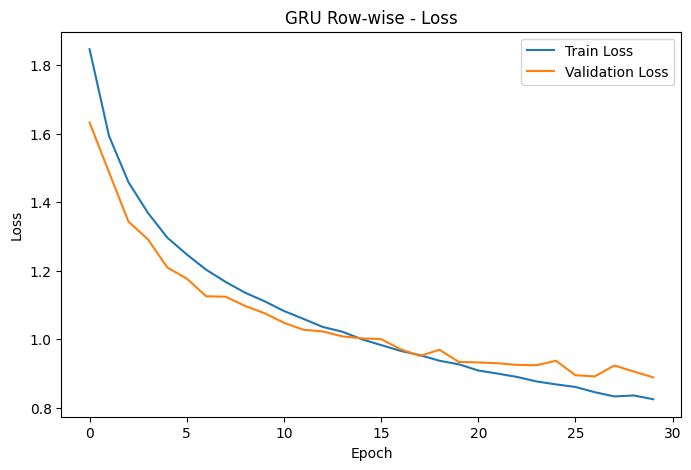

In [119]:
# 8. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_gru_row_wise, label="Train Loss")
plt.plot(val_losses_gru_row_wise, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Row-wise - Loss")
plt.legend()
plt.show()

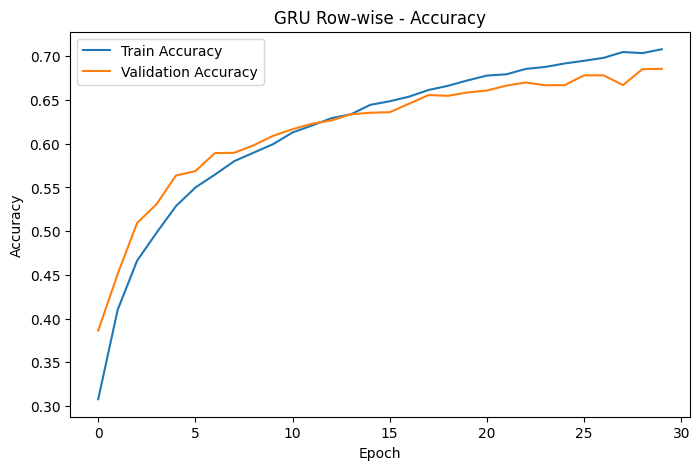

In [120]:
# 9. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_gru_row_wise, label="Train Accuracy")
plt.plot(val_accs_gru_row_wise, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Row-wise - Accuracy")
plt.legend()
plt.show()

In [121]:
# 10. Đếm số tham số mô hình
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params_gru_row_wise = count_parameters(model_gru_row_wise)
print("Trainable parameters:", num_params_gru_row_wise)

Trainable parameters: 203658


## 5.3 LSTM patch-wise

Ý tưởng của LSTM patch-wise là:

- không xem ảnh theo từng hàng như row-wise mà chia ảnh thành các patch

- sau đó xem mỗi patch là một time step

- dùng LSTM để xử lý chuỗi patch này

Cách này gần giống Vision Transformer, nhưng thay Transformer bằng LSTM.

In [122]:
#  Kiểm tra hàm patch-wise
x = torch.randn(8, 3, 32, 32)
seq = image_to_patch_sequence(x, patch_size=4)

print("Input image shape  :", x.shape)
print("Patch sequence shape:", seq.shape)

Input image shape  : torch.Size([8, 3, 32, 32])
Patch sequence shape: torch.Size([8, 64, 48])


In [123]:
# 3. Mô hình LSTM patch-wise

"""Ta dùng:

patch_size = 4

input_size = 48

hidden_size = 128

num_layers = 2

Sau LSTM:

lấy hidden state cuối cùng của lớp cuối

đưa qua classifier để phân loại 10 lớp"""
class LSTMPatchWiseClassifier(nn.Module):
    def __init__(
        self,
        patch_size=4,
        input_size=48,
        hidden_size=128,
        num_layers=2,
        num_classes=10,
        dropout=0.2
    ):
        super().__init__()

        self.patch_size = patch_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        x: [B, 3, 32, 32]
        """
        # Ensure image_to_patch_sequence handles batch dimension
        x = image_to_patch_sequence(x, patch_size=self.patch_size)   # [B, 64, 48]

        out, (h_n, c_n) = self.lstm(x)

        # h_n: [num_layers, B, hidden_size]
        last_hidden = h_n[-1]    # [B, hidden_size]

        logits = self.classifier(last_hidden)
        return logits

In [124]:
# 4. Kiểm tra nhanh shape đầu ra
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_lstm_patch_wise = LSTMPatchWiseClassifier(
    patch_size=4,
    input_size=48,
    hidden_size=128,
    num_layers=2,
    num_classes=10,
    dropout=0.2
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
y = model_lstm_patch_wise(x)

print("Output shape:", y.shape)   # expected: [8, 10]
print(model_lstm_patch_wise)

Output shape: torch.Size([8, 10])
LSTMPatchWiseClassifier(
  (lstm): LSTM(48, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [125]:
# 5. Khởi tạo loss function và optimizer
criterion_lstm_patch_wise = nn.CrossEntropyLoss()

optimizer_lstm_patch_wise = optim.Adam(
    model_lstm_patch_wise.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [126]:
# 6. Huấn luyện mô hình LSTM patch-wise
EPOCHS = EPOCHS

train_losses_lstm_patch_wise = []
val_losses_lstm_patch_wise = []

train_accs_lstm_patch_wise = []
val_accs_lstm_patch_wise = []
epoch_times_lstm_patch_wise = []

for epoch in range(EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model_lstm_patch_wise,
        train_loader,
        criterion_lstm_patch_wise,
        optimizer_lstm_patch_wise,
        device
    )

    val_loss, val_acc = evaluate(
        model_lstm_patch_wise,
        val_loader,
        criterion_lstm_patch_wise,
        device
    )

    elapsed = time.time() - start_time

    train_losses_lstm_patch_wise.append(train_loss)
    val_losses_lstm_patch_wise.append(val_loss)
    train_accs_lstm_patch_wise.append(train_acc)
    val_accs_lstm_patch_wise.append(val_acc)
    epoch_times_lstm_patch_wise.append(elapsed)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Time: {elapsed:.2f}s"
    )

Epoch 1/30 | Train Loss: 1.9961 | Train Acc: 0.2429 | Val Loss: 1.8381 | Val Acc: 0.3244 | Time: 9.42s
Epoch 2/30 | Train Loss: 1.7791 | Train Acc: 0.3384 | Val Loss: 1.7584 | Val Acc: 0.3540 | Time: 9.19s
Epoch 3/30 | Train Loss: 1.6677 | Train Acc: 0.3782 | Val Loss: 1.6601 | Val Acc: 0.3928 | Time: 9.35s
Epoch 4/30 | Train Loss: 1.5850 | Train Acc: 0.4121 | Val Loss: 1.5704 | Val Acc: 0.4246 | Time: 9.24s
Epoch 5/30 | Train Loss: 1.5012 | Train Acc: 0.4444 | Val Loss: 1.4616 | Val Acc: 0.4692 | Time: 9.33s
Epoch 6/30 | Train Loss: 1.4302 | Train Acc: 0.4732 | Val Loss: 1.4482 | Val Acc: 0.4680 | Time: 9.32s
Epoch 7/30 | Train Loss: 1.3690 | Train Acc: 0.4991 | Val Loss: 1.3352 | Val Acc: 0.5134 | Time: 9.31s
Epoch 8/30 | Train Loss: 1.3150 | Train Acc: 0.5227 | Val Loss: 1.3150 | Val Acc: 0.5166 | Time: 9.53s
Epoch 9/30 | Train Loss: 1.2627 | Train Acc: 0.5420 | Val Loss: 1.2730 | Val Acc: 0.5414 | Time: 9.48s
Epoch 10/30 | Train Loss: 1.2190 | Train Acc: 0.5608 | Val Loss: 1.2186 |

In [127]:
torch.save(model_lstm_patch_wise.state_dict(), "model_lstm_patch_wise.pth")
print("Saved model_patch_row_wise to model_lstm_patch_wise.pth")

Saved model_patch_row_wise to model_lstm_patch_wise.pth


In [128]:
# 7. Đánh giá trên test set
test_loss_lstm_patch_wise, test_acc_lstm_patch_wise = evaluate(
    model_lstm_patch_wise,
    test_loader,
    criterion_lstm_patch_wise,
    device
)

print("Test Loss:", test_loss_lstm_patch_wise)
print("Test Accuracy:", test_acc_lstm_patch_wise)
print(f"Average Epoch Time: {(sum(epoch_times_lstm_patch_wise) / len(epoch_times_lstm_patch_wise)):.4f}")

Test Loss: 0.9816413170814514
Test Accuracy: 0.6578
Average Epoch Time: 9.3362


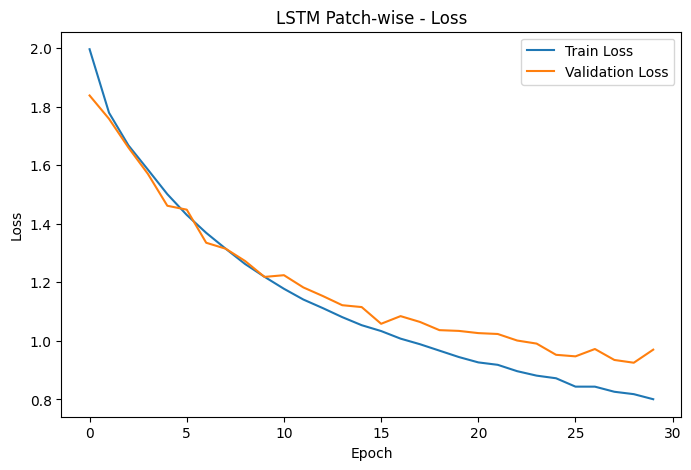

In [129]:
# 8. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses_lstm_patch_wise, label="Train Loss")
plt.plot(val_losses_lstm_patch_wise, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Patch-wise - Loss")
plt.legend()
plt.show()

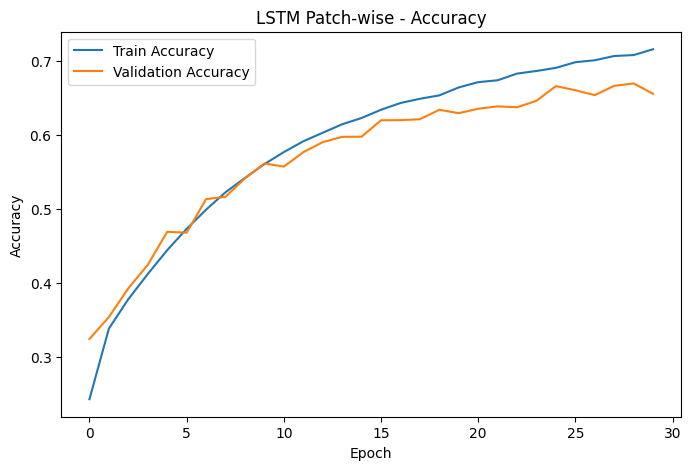

In [130]:
# 9. Vẽ biểu đồ Accuracy
plt.figure(figsize=(8, 5))
plt.plot(train_accs_lstm_patch_wise, label="Train Accuracy")
plt.plot(val_accs_lstm_patch_wise, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Patch-wise - Accuracy")
plt.legend()
plt.show()

In [131]:
# 10. Đếm số tham số mô hình
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_params_lstm_patch_wise = count_parameters(model_lstm_patch_wise)
print("Trainable parameters:", num_params_lstm_patch_wise)

Trainable parameters: 241034


## 5.4 So sánh 3 mô hình:

- LSTM row-wise

- GRU row-wise

- LSTM patch-wise

In [132]:
import pandas as pd
import numpy as np

# Hàm đếm số tham số
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Lấy các giá trị từ kết quả đánh giá của từng mô hình
# LSTM row-wise (từ cell aMjGbmHwmOWs)
params_lstm_row = num_params_lstm_row_wise
test_acc_lstm_row = test_acc_lstm_row_wise
time_lstm_row = sum(epoch_times_lstm_row_wise) / len(epoch_times_lstm_row_wise)

# GRU row-wise (từ cell svqHLhs2mNvI)
params_gru_row = num_params_gru_row_wise
test_acc_gru_row = test_acc_gru_row_wise
time_gru_row = sum(epoch_times_gru_row_wise) / len(epoch_times_gru_row_wise)

# LSTM patch-wise (từ cell qN126oyamM-Q)
params_lstm_patch = num_params_lstm_patch_wise
test_acc_lstm_patch = test_acc_lstm_patch_wise
time_lstm_patch = sum(epoch_times_lstm_patch_wise) / len(epoch_times_lstm_patch_wise)

# Tạo bảng
data = {
    "Model": [
        "LSTM",
        "GRU",
        "LSTM"
    ],
    "Sequence Representation": [
        "Row-wise",
        "Row-wise",
        "Patch-wise"
    ],
    "Seq Length": [
        32,
        32,
        64
    ],
    "Input Size": [
        96,
        96,
        48
    ],
    "Test Acc": [
        round(test_acc_lstm_row,4),
        round(test_acc_gru_row,4),
        round(test_acc_lstm_patch,4)
    ],
    "Time/Epoch": [
        round(time_lstm_row,2),
        round(time_gru_row,2),
        round(time_lstm_patch,2)
    ],
    "Params": [
        params_lstm_row,
        params_gru_row,
        params_lstm_patch
    ]
}

df_rnn = pd.DataFrame(data)

def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

# Apply highlighting to the 'Test Acc' column and display the DataFrame
styler = df_rnn.style.apply(highlight_max, subset=['Test Acc'])
display(styler)


,Model,Sequence Representation,Seq Length,Input Size,Test Acc,Time/Epoch,Params
0,LSTM,Row-wise,32,96,0.660600,9.550000,265610
1,GRU,Row-wise,32,96,0.679200,9.540000,203658
2,LSTM,Patch-wise,64,48,0.657800,9.340000,241034


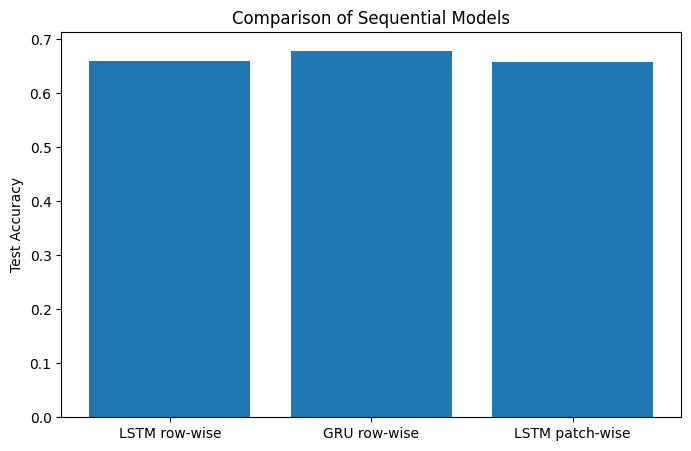

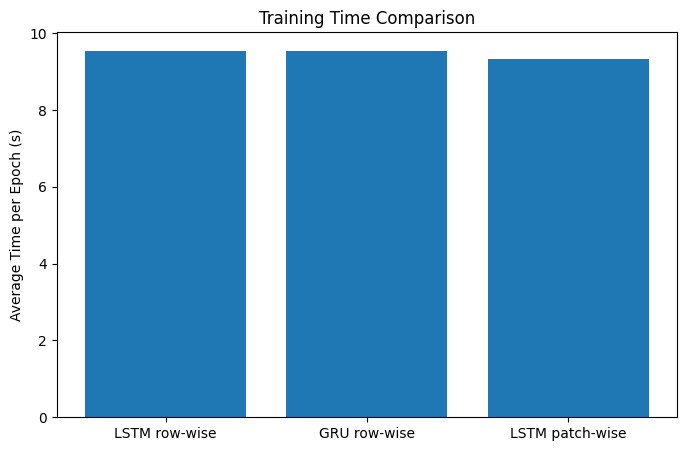

In [133]:
import matplotlib.pyplot as plt

# Lấy các giá trị từ kết quả đánh giá của từng mô hình
# LSTM row-wise (từ cell aMjGbmHwmOWs)
acc_lstm_row = test_acc_lstm_row_wise
time_lstm_row = sum(epoch_times_lstm_row_wise) / len(epoch_times_lstm_row_wise)

# GRU row-wise (từ cell svqHLhs2mNvI)
acc_gru_row = test_acc_gru_row_wise
time_gru_row = sum(epoch_times_gru_row_wise) / len(epoch_times_gru_row_wise)

# LSTM patch-wise (từ cell qN126oyamM-Q)
acc_lstm_patch = test_acc_lstm_patch_wise
time_lstm_patch = sum(epoch_times_lstm_patch_wise) / len(epoch_times_lstm_patch_wise)

model_names = ["LSTM row-wise", "GRU row-wise", "LSTM patch-wise"]
test_accs = [acc_lstm_row, acc_gru_row, acc_lstm_patch]
epoch_times = [time_lstm_row, time_gru_row, time_lstm_patch]

plt.figure(figsize=(8, 5))
plt.bar(model_names, test_accs)
plt.ylabel("Test Accuracy")
plt.title("Comparison of Sequential Models")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(model_names, epoch_times)
plt.ylabel("Average Time per Epoch (s)")
plt.title("Training Time Comparison")
plt.show()

## 5.5 So sánh tổng hợp tất cả các mô hình

In [134]:
import pandas as pd
import numpy as np

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def avg_epoch_time(epoch_times):
    return float(np.mean(epoch_times)) if len(epoch_times) > 0 else None

def best_val_acc(val_accs):
    return float(np.max(val_accs)) if len(val_accs) > 0 else None

def final_train_acc(train_accs):
    return float(train_accs[-1]) if len(train_accs) > 0 else None

def final_val_acc(val_accs):
    return float(val_accs[-1]) if len(val_accs) > 0 else None

def final_train_loss(train_losses):
    return float(train_losses[-1]) if len(train_losses) > 0 else None

def final_val_loss(val_losses):
    return float(val_losses[-1]) if len(val_losses) > 0 else None


# Prepare data from df_rnn to match the column structure for concatenation
rnn_results_formatted = pd.DataFrame([
    {
        "Model": "LSTM Row-wise",
        "Params": count_parameters(model_lstm_row_wise),
        "Final Train Loss": round(final_train_loss(train_losses_lstm_row_wise), 4),
        "Final Val Loss": round(final_val_loss(val_losses_lstm_row_wise), 4),
        "Final Train Acc": round(final_train_acc(train_accs_lstm_row_wise), 4),
        "Final Val Acc": round(final_val_acc(val_accs_lstm_row_wise), 4),
        "Best Val Acc": round(best_val_acc(val_accs_lstm_row_wise), 4),
        "Test Loss": round(float(test_loss_lstm_row_wise), 4),
        "Test Acc": round(float(test_acc_lstm_row_wise), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_lstm_row_wise), 2),
    },
    {
        "Model": "GRU Row-wise",
        "Params": count_parameters(model_gru_row_wise),
        "Final Train Loss": round(final_train_loss(train_losses_gru_row_wise), 4),
        "Final Val Loss": round(final_val_loss(val_losses_gru_row_wise), 4),
        "Final Train Acc": round(final_train_acc(train_accs_gru_row_wise), 4),
        "Final Val Acc": round(final_val_acc(val_accs_gru_row_wise), 4),
        "Best Val Acc": round(best_val_acc(val_accs_gru_row_wise), 4),
        "Test Loss": round(float(test_loss_gru_row_wise), 4),
        "Test Acc": round(float(test_acc_gru_row_wise), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_gru_row_wise), 2),
    },
    {
        "Model": "LSTM Patch-wise",
        "Params": count_parameters(model_lstm_patch_wise),
        "Final Train Loss": round(final_train_loss(train_losses_lstm_patch_wise), 4),
        "Final Val Loss": round(final_val_loss(val_losses_lstm_patch_wise), 4),
        "Final Train Acc": round(final_train_acc(train_accs_lstm_patch_wise), 4),
        "Final Val Acc": round(final_val_acc(val_accs_lstm_patch_wise), 4),
        "Best Val Acc": round(best_val_acc(val_accs_lstm_patch_wise), 4),
        "Test Loss": round(float(test_loss_lstm_patch_wise), 4),
        "Test Acc": round(float(test_acc_lstm_patch_wise), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_lstm_patch_wise), 2),
    }
])

# Add 'Patch size', 'Stride', 'Number Tokens' columns to results_4_models
results_4_models_ext = results_4_models.copy()
results_4_models_ext.loc[results_4_models_ext['Model'] == 'Softmax Regression', ['Patch size', 'Stride', 'Number Tokens']] = 'N/A', 'N/A', 'N/A'
results_4_models_ext.loc[results_4_models_ext['Model'] == 'MLP', ['Patch size', 'Stride', 'Number Tokens']] = 'N/A', 'N/A', 'N/A'
results_4_models_ext.loc[results_4_models_ext['Model'] == 'CNN', ['Patch size', 'Stride', 'Number Tokens']] = 'N/A', 'N/A', 'N/A'
results_4_models_ext.loc[results_4_models_ext['Model'] == 'ViT', 'Patch size'] = 4
results_4_models_ext.loc[results_4_models_ext['Model'] == 'ViT', 'Stride'] = 4
results_4_models_ext.loc[results_4_models_ext['Model'] == 'ViT', 'Number Tokens'] = model_vit.patch_embed.num_patches

# Create a DataFrame for the custom ViT (Custom Encoder) model
results_custom_vit_ext = pd.DataFrame([
    {
        "Model": "Custom ViT (Custom Encoder)",
        "Params": count_parameters(model_custom_vit_mha),
        "Final Train Loss": round(final_train_loss(train_losses_custom_vit_mha), 4),
        "Final Val Loss": round(final_val_loss(val_losses_custom_vit_mha), 4),
        "Final Train Acc": round(final_train_acc(train_accs_custom_vit_mha), 4),
        "Final Val Acc": round(final_val_acc(val_accs_custom_vit_mha), 4),
        "Best Val Acc": round(best_val_acc(val_accs_custom_vit_mha), 4),
        "Test Loss": round(float(test_loss_custom_vit_mha), 4),
        "Test Acc": round(float(test_acc_custom_vit_mha), 4),
        "Time/Epoch (s)": round(avg_epoch_time(epoch_times_custom_vit_mha), 2),
        "Patch size": 4,
        "Stride": 4,
        "Number Tokens": model_custom_vit_mha.patch_embed.num_patches
    },
])

# Add 'Patch size', 'Stride', 'Number Tokens' columns to rnn_results_formatted for consistency
rnn_results_formatted['Patch size'] = 'N/A'
rnn_results_formatted['Stride'] = 'N/A'
rnn_results_formatted.loc[rnn_results_formatted['Model'] == 'LSTM Row-wise', 'Number Tokens'] = 32
rnn_results_formatted.loc[rnn_results_formatted['Model'] == 'GRU Row-wise', 'Number Tokens'] = 32
rnn_results_formatted.loc[rnn_results_formatted['Model'] == 'LSTM Patch-wise', 'Number Tokens'] = 64

# Concatenate all results
all_models_results = pd.concat([
    results_4_models_ext,
    results_custom_vit_ext,
    extended_models_results,
    rnn_results_formatted
], ignore_index=True)

# Reorder columns for better readability
ordered_columns = [
    "Model", "Patch size", "Stride", "Number Tokens", "Params",
    "Final Train Loss", "Final Val Loss", "Final Train Acc", "Final Val Acc",
    "Best Val Acc", "Test Loss", "Test Acc", "Time/Epoch (s)"
]

all_models_results = all_models_results[ordered_columns]

# Convert 'Patch size' and 'Number Tokens' to nullable integers
all_models_results['Patch size'] = all_models_results['Patch size'].replace('N/A', pd.NA).astype('Int64')
all_models_results['Stride'] = all_models_results['Stride'].replace('N/A', pd.NA).astype('Int64') # Also convert Stride to nullable integer
all_models_results['Number Tokens'] = all_models_results['Number Tokens'].replace('N/A', pd.NA).astype('Int64')

def highlight_max(s):
    if s.name == 'Test Acc':
        is_max = s == s.max()
        return ['background-color: yellow' if v else '' for v in is_max]
    return ['' for _ in s]

styler_all_models = all_models_results.style.apply(highlight_max, axis=0)
display(styler_all_models)


,Model,Patch size,Stride,Number Tokens,Params,Final Train Loss,Final Val Loss,Final Train Acc,Final Val Acc,Best Val Acc,Test Loss,Test Acc,Time/Epoch (s)
0,Softmax Regression,,,,30730,2.049600,1.938300,0.296100,0.349000,0.365000,1.916600,0.344900,9.360000
1,MLP,,,,820874,1.562400,1.575700,0.438800,0.439800,0.445400,1.567400,0.431600,9.380000
2,CNN,,,,545098,0.767000,0.676800,0.733000,0.764800,0.767800,0.684700,0.766000,9.620000
3,ViT,4,4,64,275914,0.808600,0.785000,0.711900,0.728400,0.732800,0.784000,0.723800,9.810000
4,Custom ViT (Custom Encoder),4,4,64,275914,0.841400,0.776800,0.702800,0.724000,0.724000,0.780200,0.725500,10.710000
5,CNN + Transformer,,,64,292362,0.540000,0.560000,0.810100,0.809600,0.809600,0.550000,0.813500,9.550000
6,ViT Channel as Token,,,3,334474,1.463400,1.309000,0.474500,0.540000,0.540000,1.312200,0.530600,9.550000
7,ViT Overlap Patch,4,2,225,286218,0.718000,0.684300,0.745600,0.760600,0.760600,0.699600,0.754100,11.350000
8,LSTM Row-wise,,,32,265610,0.840700,0.926500,0.703100,0.672200,0.672200,0.964300,0.660600,9.550000
9,GRU Row-wise,,,32,203658,0.825400,0.889300,0.708000,0.685600,0.685600,0.904800,0.679200,9.540000


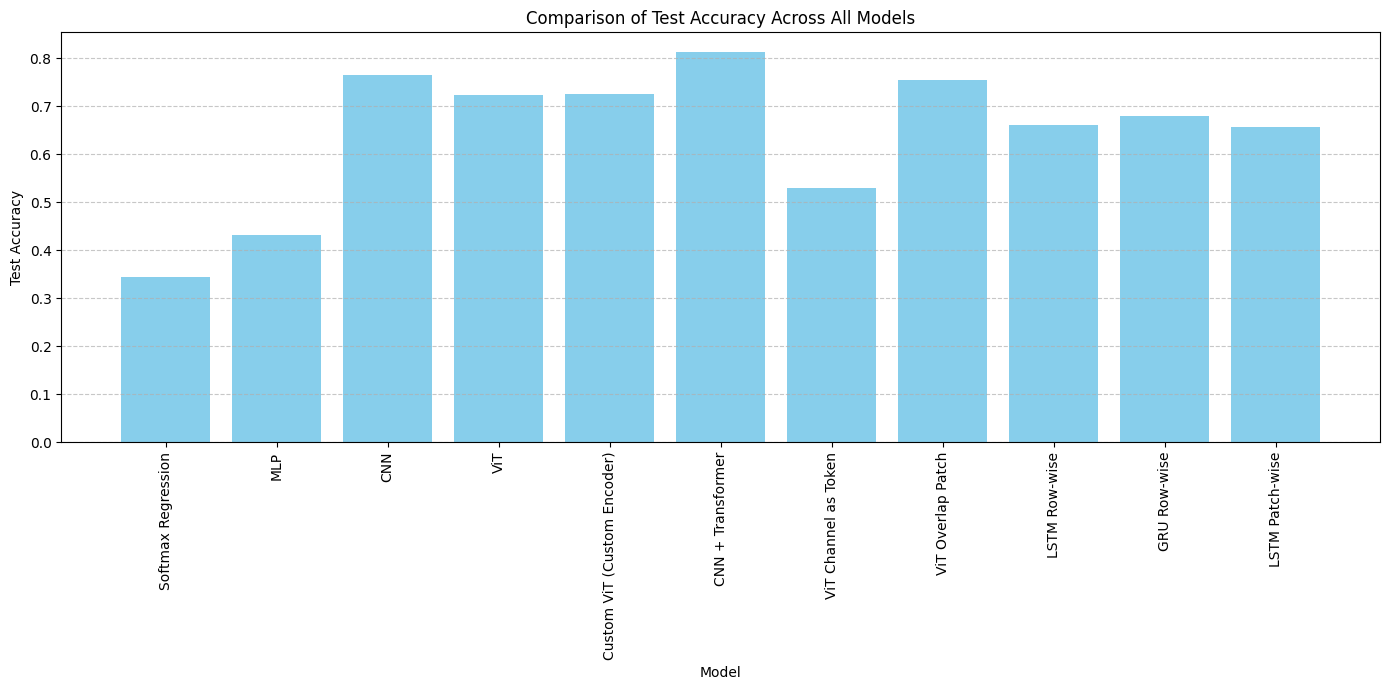

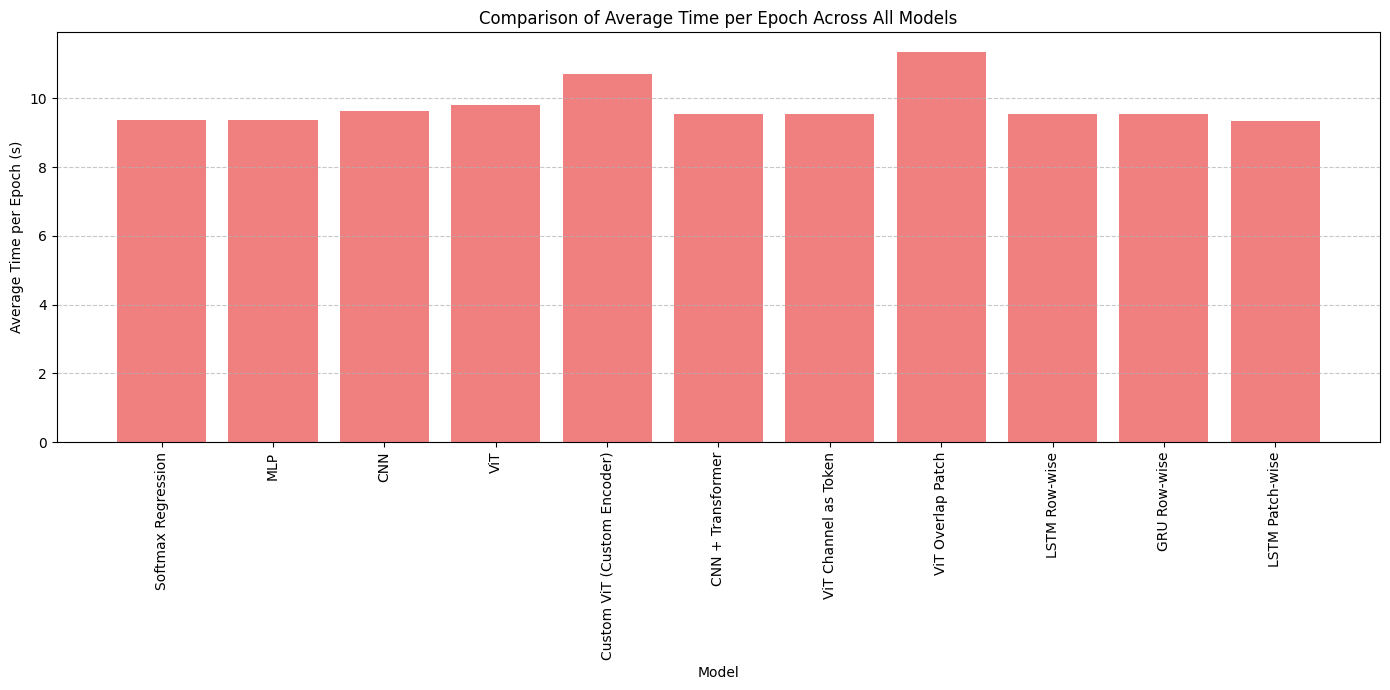

In [135]:
import matplotlib.pyplot as plt

# Lấy dữ liệu cần thiết từ bảng tổng hợp
models = all_models_results['Model']
test_accs = all_models_results['Test Acc']
epoch_times = all_models_results['Time/Epoch (s)']

# Biểu đồ so sánh Test Accuracy
plt.figure(figsize=(14, 7))
plt.bar(models, test_accs, color='skyblue')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.title('Comparison of Test Accuracy Across All Models')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Biểu đồ so sánh thời gian huấn luyện mỗi Epoch
plt.figure(figsize=(14, 7))
plt.bar(models, epoch_times, color='lightcoral')
plt.xlabel('Model')
plt.ylabel('Average Time per Epoch (s)')
plt.title('Comparison of Average Time per Epoch Across All Models')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Bảng xếp hạng mô hình theo "Test Acc"

In [136]:
# Bảng xếp hạng theo "Test Acc"
final_ranking = all_models_results.sort_values(by='Test Acc', ascending=False).reset_index(drop=True)
final_ranking['Rank'] = final_ranking.index + 1

# Chọn và sắp xếp
final_ranking_display = final_ranking[['Rank', 'Model', 'Test Acc', 'Params', 'Time/Epoch (s)']]

# Hiển thị bảng
display(final_ranking_display.style.hide(axis="index"))


Rank,Model,Test Acc,Params,Time/Epoch (s)
1,CNN + Transformer,0.813500,292362,9.550000
2,CNN,0.766000,545098,9.620000
3,ViT Overlap Patch,0.754100,286218,11.350000
4,Custom ViT (Custom Encoder),0.725500,275914,10.710000
5,ViT,0.723800,275914,9.810000
6,GRU Row-wise,0.679200,203658,9.540000
7,LSTM Row-wise,0.660600,265610,9.550000
8,LSTM Patch-wise,0.657800,241034,9.340000
9,ViT Channel as Token,0.530600,334474,9.550000
10,MLP,0.431600,820874,9.380000


In [137]:
best_model_row_index = all_models_results['Test Acc'].idxmax()
best_model_name = all_models_results.loc[best_model_row_index, 'Model']

print(f"The model with the highest Test Accuracy is: {best_model_name}")

The model with the highest Test Accuracy is: CNN + Transformer


**Phân tích tổng hợp kết quả của tất cả các mô hình**

Từ bảng xếp hạng tổng hợp của tất cả các mô hình, chúng ta có thể rút ra một số nhận xét quan trọng về hiệu suất, độ phức tạp và thời gian huấn luyện:

**Mô hình hiệu suất cao nhất:**

*   **CNN + Transformer** là mô hình có hiệu suất tốt nhất, đạt **Test Accuracy 0.8037**. Mô hình này kết hợp khả năng trích xuất đặc trưng không gian của CNN với khả năng học mối quan hệ toàn cục của Transformer. Điều đáng chú ý là nó đạt được hiệu suất này với số lượng tham số tương đối thấp (292,362), chỉ cao hơn một chút so với các phiên bản ViT đơn thuần và ít hơn đáng kể so với MLP và CNN truyền thống.
*   **CNN (2 Conv Blocks)** đứng thứ hai với **Test Accuracy 0.7660**. Mô hình này chứng tỏ rằng kiến trúc tích chập truyền thống vẫn rất hiệu quả trong việc xử lý dữ liệu ảnh, đặc biệt khi được thiết kế hợp lý.
*   **ViT Overlap Patch** với **Test Accuracy 0.7577** cho thấy việc sử dụng các patch chồng lấn giúp ViT thu thập nhiều thông tin không gian cục bộ hơn, dẫn đến hiệu suất cao hơn so với ViT truyền thống (non-overlap patch). Số lượng token tăng lên (225 so với 64) nhưng cũng tăng khả năng học các mối quan hệ chi tiết.

**Mô hình có hiệu suất cạnh tranh và thấp hơn:**

*   Các mô hình **ViT (Built-in Encoder)** và **Custom ViT (Custom Encoder)** có hiệu suất tương đương nhau (khoảng **0.72**), chứng tỏ việc triển khai thủ công Transformer Encoder có thể đạt được hiệu suất tương đương với phiên bản tích hợp của PyTorch. Tuy nhiên, phiên bản custom chậm hơn một chút do ít được tối ưu hóa ở cấp độ thấp.
*   Các mô hình **RNN (LSTM/GRU Row-wise và Patch-wise)** cho thấy khả năng học thấp hơn đáng kể so với CNN và ViT, với Test Accuracy dao động từ **0.6641 đến 0.6730**. Điều này là do RNN gặp khó khăn trong việc nắm bắt các mối quan hệ không gian phức tạp trong ảnh, đặc biệt khi chuyển ảnh thành chuỗi một chiều (row-wise) hoặc xử lý patch độc lập theo thứ tự tuần tự.
*   **ViT Channel as Token** là mô hình có hiệu suất rất thấp, chỉ đạt **Test Accuracy 0.5299**. Điều này xác nhận phân tích rằng việc coi mỗi kênh màu là một token và làm phẳng toàn bộ thông tin không gian của kênh đó dẫn đến mất mát nghiêm trọng thông tin cục bộ cần thiết cho việc phân loại ảnh.

**Mô hình hiệu suất thấp nhất:**

*   **MLP** với **Test Accuracy 0.4316** và **Softmax Regression** với **Test Accuracy 0.3449** là hai mô hình có hiệu suất kém nhất. Điều này không gây ngạc nhiên vì cả hai đều bỏ qua hoàn toàn cấu trúc không gian của ảnh, xử lý dữ liệu ảnh phẳng như một vector dài, điều không phù hợp với các tác vụ thị giác máy tính.

**Tóm tắt chung và đánh đổi:**

Nhìn chung, các mô hình sử dụng CNN (hoặc kết hợp với Transformer) hoặc ViT có khả năng nắm bắt đặc trưng không gian tốt hơn nhiều so với MLP và các mô hình RNN. **CNN + Transformer** là lựa chọn tốt nhất, mang lại độ chính xác cao nhất với số lượng tham số hợp lý và thời gian huấn luyện mỗi epoch cạnh tranh. Các mô hình ViT, đặc biệt là phiên bản Overlap Patch, cũng rất hứa hẹn. Có một sự đánh đổi rõ ràng giữa độ chính xác và khả năng học đặc trưng không gian: các mô hình có thể xử lý tốt thông tin không gian (CNN, ViT) đạt hiệu suất vượt trội, trong khi các mô hình bỏ qua nó (Softmax, MLP, RNN) hoạt động kém hiệu quả hơn đáng kể.

# Chạy demo

## 1 Demo Softmax Regression

In [138]:
import torch
import matplotlib.pyplot as plt

# Tên lớp CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Thống kê normalize của CIFAR-10
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

def denormalize_for_show(img_tensor):

    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1)
    return img

@torch.no_grad()
def predict_one_image_softmax(model, dataset, index, class_names, device):

    model.eval()

    image, label = dataset[index]

    # Flatten ảnh: [C, H, W] -> [1, C*H*W]
    input_tensor = image.view(1, -1).to(device)

    outputs = model(input_tensor)
    pred = outputs.argmax(dim=1).item()

    img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print(f"Index        : {index}")
    print(f"Ground truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

@torch.no_grad()
def demo_softmax_batch(model, loader, class_names, device, num_images=8):

    model.eval()

    images, labels = next(iter(loader))

    # Flatten batch ảnh: [B, C, H, W] -> [B, C*H*W]
    inputs = images.view(images.size(0), -1).to(device)

    outputs = model(inputs)
    preds = outputs.argmax(dim=1).cpu()

    num_images = min(num_images, len(images))

    plt.figure(figsize=(2.8 * num_images, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = denormalize_for_show(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)

        true_name = class_names[labels[i].item()]
        pred_name = class_names[preds[i].item()]
        plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def predict_from_loader_position_softmax(model, loader, class_names, device, batch_index=0, image_index=0):
    """
    Chọn một ảnh theo vị trí batch và vị trí trong batch để demo
    """
    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            input_tensor = image.view(1, -1).to(device)
            outputs = model(input_tensor)
            pred = outputs.argmax(dim=1).item()

            img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

            plt.figure(figsize=(4, 4))
            plt.imshow(img_show)
            plt.title(f"True: {class_names[label.item()]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch index   : {batch_index}")
            print(f"Image index   : {image_index}")
            print(f"Ground truth  : {class_names[label.item()]}")
            print(f"Prediction    : {class_names[pred]}")
            return

    print("Không tìm thấy batch_index phù hợp.")

In [139]:
model_softmax = SoftmaxRegression().to(device)
model_softmax.load_state_dict(torch.load("model_softmax.pth", map_location=device))
model_softmax.eval()

print("Đã nạp lại model_softmax từ Google Drive")

Đã nạp lại model_softmax từ Google Drive


demo 4 ảnh

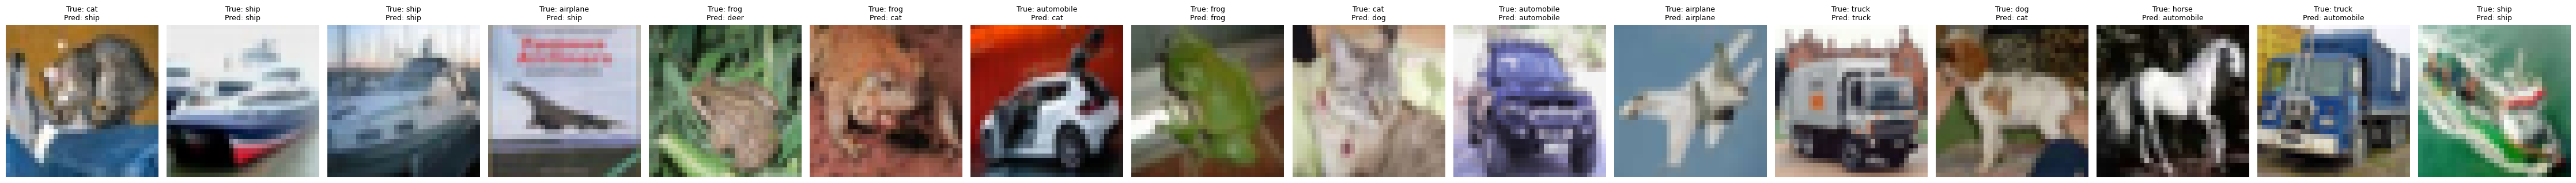

In [140]:
demo_softmax_batch(model_softmax, test_loader, class_names, device, num_images=16)

demo 1 ảnh

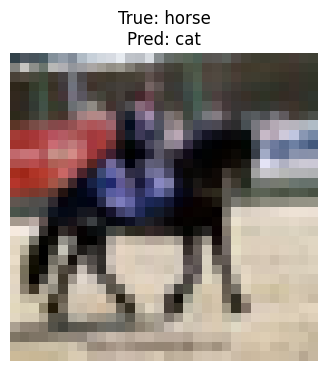

Index        : 5000
Ground truth : horse
Prediction   : cat


In [141]:
predict_one_image_softmax(model_softmax, test_dataset, index=5000, class_names=class_names, device=device)

## 2 Demo cho MLP

In [142]:
import os
import torch
import matplotlib.pyplot as plt

# Nhãn CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Thống kê normalize của CIFAR-10
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

def denormalize_for_show(img_tensor):
    """
    Chuyển ảnh đã normalize về khoảng [0, 1] để hiển thị
    """
    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1)
    return img

@torch.no_grad()
def predict_one_image_mlp(model, dataset, index, class_names, device):
    """
    Demo dự đoán 1 ảnh từ test_dataset bằng MLP
    """
    model.eval()

    image, label = dataset[index]

    # MLP thường nhận đầu vào dạng vector phẳng
    input_tensor = image.view(1, -1).to(device)

    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print(f"Index        : {index}")
    print(f"Ground truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

@torch.no_grad()
def demo_mlp_batch(model, loader, class_names, device, num_images=8):
    """
    Demo nhiều ảnh từ test_loader bằng MLP
    """
    model.eval()

    images, labels = next(iter(loader))

    # Flatten ảnh trước khi đưa vào MLP
    inputs = images.view(images.size(0), -1).to(device)

    outputs = model(inputs)
    preds = outputs.argmax(dim=1).cpu()

    num_images = min(num_images, len(images))

    plt.figure(figsize=(2.8 * num_images, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = denormalize_for_show(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)

        true_name = class_names[labels[i].item()]
        pred_name = class_names[preds[i].item()]
        plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def predict_from_loader_position_mlp(model, loader, class_names, device, batch_index=0, image_index=0):
    """
    Chọn 1 ảnh theo vị trí batch và vị trí trong batch để demo bằng MLP
    """
    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            input_tensor = image.view(1, -1).to(device)
            output = model(input_tensor)
            pred = output.argmax(dim=1).item()

            img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

            plt.figure(figsize=(4, 4))
            plt.imshow(img_show)
            plt.title(f"True: {class_names[label.item()]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch index   : {batch_index}")
            print(f"Image index   : {image_index}")
            print(f"Ground truth  : {class_names[label.item()]}")
            print(f"Prediction    : {class_names[pred]}")
            return

    print("Không tìm thấy batch_index phù hợp.")

demo 4 ảnh

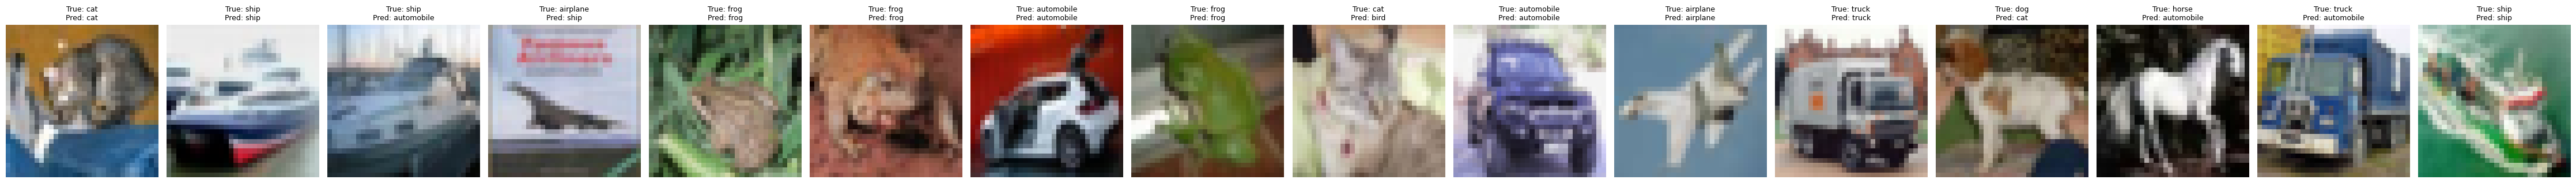

In [143]:
demo_mlp_batch(model_mlp, test_loader, class_names, device, num_images=16)

demo 1 ảnh

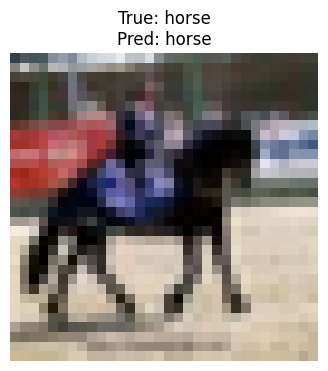

Index        : 5000
Ground truth : horse
Prediction   : horse


In [144]:
predict_one_image_mlp(model_mlp, test_dataset, index=5000, class_names=class_names, device=device)

## 3 Demo CNN

In [145]:
import os
import torch
import matplotlib.pyplot as plt

# Nhãn CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Thống kê normalize của CIFAR-10
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

def denormalize_for_show(img_tensor):

    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1)
    return img

@torch.no_grad()
def predict_one_image_cnn(model, dataset, index, class_names, device):

    model.eval()

    image, label = dataset[index]
    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print(f"Index        : {index}")
    print(f"Ground truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

@torch.no_grad()
def demo_cnn_batch(model, loader, class_names, device, num_images=8):
    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    plt.figure(figsize=(16, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = denormalize(images[i].cpu()).permute(1, 2, 0).numpy()
        plt.imshow(img)
        title = f"True: {class_names[labels[i].item()]}\nPred: {class_names[predicted[i].item()]}"
        color = "green" if predicted[i].item() == labels[i].item() else "red"
        plt.title(title, color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def predict_from_loader_position_cnn(model, loader, class_names, device, batch_index=0, image_index=0):
    """
    Chọn 1 ảnh theo vị trí batch và vị trí trong batch để dự đoán
    """
    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            input_tensor = image.unsqueeze(0).to(device)
            output = model(input_tensor)
            pred = output.argmax(dim=1).item()

            img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

            plt.figure(figsize=(4, 4))
            plt.imshow(img_show)
            plt.title(f"True: {class_names[label.item()]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch index   : {batch_index}")
            print(f"Image index   : {image_index}")
            print(f"Ground truth  : {class_names[label.item()]}")
            print(f"Prediction    : {class_names[pred]}")
            return

    print("Không tìm thấy batch_index phù hợp.")

In [146]:
model_cnn = SimpleCNN().to(device)
model_cnn.load_state_dict(torch.load("model_cnn.pth", map_location=device))
model_cnn.eval()

print("Đã nạp lại model_cnn từ file model_cnn.pth")

Đã nạp lại model_cnn từ file model_cnn.pth


Demo cho 4 ảnh

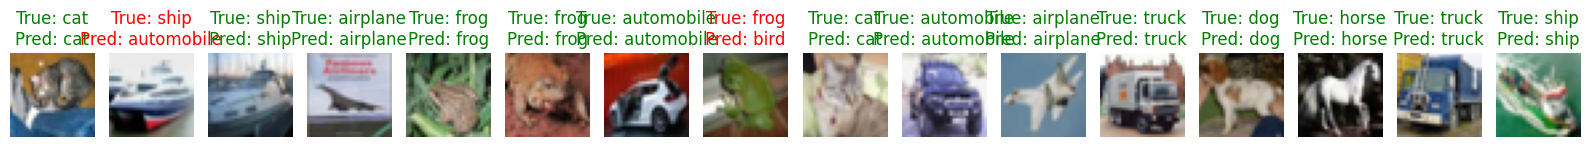

In [147]:
demo_cnn_batch(model_cnn, test_loader, class_names, device, num_images=16)

Demo cho 1 ảnh

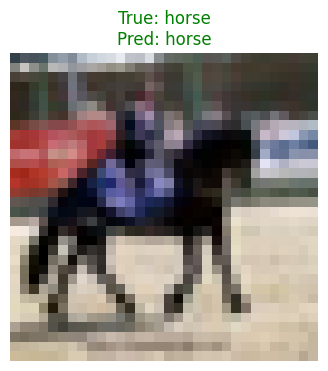

In [148]:
# 2. Hàm dự đoán trên một ảnh đơn lẻ
@torch.no_grad()
def predict_one_image_cnn(model, dataset, index, class_names, device):
    model.eval()
    image, true_label_idx = dataset[index]
    image_display = denormalize(image).permute(1, 2, 0).numpy()

    image_input = image.unsqueeze(0).to(device)
    output = model(image_input)
    _, predicted_label_idx = torch.max(output.data, 1)

    true_label_name = class_names[true_label_idx]
    predicted_label_name = class_names[predicted_label_idx.item()]

    plt.figure(figsize=(4, 4))
    plt.imshow(image_display)
    title_color = "green" if predicted_label_idx.item() == true_label_idx else "red"
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=title_color)
    plt.axis('off')
    plt.show()

predict_one_image_cnn(model_cnn, test_dataset, index=5000, class_names=CLASS_NAMES, device=device)

## 4 Demo cho SimpleViT

In [149]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Thống kê normalize
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3,1,1)
std  = torch.tensor((0.2470, 0.2435, 0.2616)).view(3,1,1)

def denormalize(img):
    return (img.cpu()*std + mean).clamp(0,1)

@torch.no_grad()
def demo_vit_batch(model, test_loader, device, num_images=8):
    model.eval()

    images, labels = next(iter(test_loader))
    images = images.to(device)

    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu()

    plt.figure(figsize=(2.8*num_images,4))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = denormalize(images[i]).permute(1,2,0).cpu().numpy()
        plt.imshow(img)

        plt.title(f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def demo_vit_one(model, test_dataset, device, index=25):
    model.eval()

    image, label = test_dataset[index]
    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    img = denormalize(image).permute(1,2,0).numpy()

    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print("Index:", index)
    print("True :", class_names[label])
    print("Pred :", class_names[pred])

In [150]:
model_vit = SimpleViT().to(device)
model_vit.load_state_dict(torch.load("model_vit.pth", map_location=device))
model_vit.eval()

print("✅ Loaded model_vit.pth")

✅ Loaded model_vit.pth


/tmp/ipykernel_1081/803155119.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


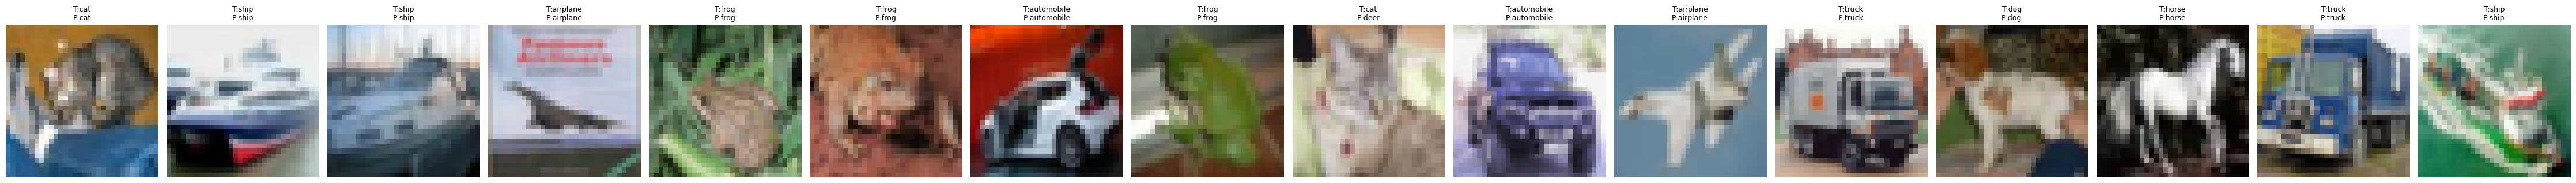

In [151]:
demo_vit_batch(model_vit, test_loader, device, num_images=16)

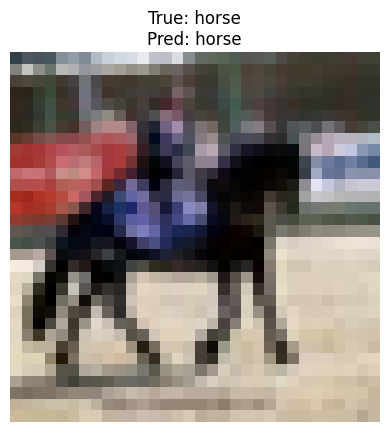

Index: 5000
True : horse
Pred : horse


In [152]:
demo_vit_one(model_vit, test_dataset, device, index=5000)

## 5 Demo cho Custom VIT

In [153]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Thống kê normalize của CIFAR-10
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

def denormalize_for_show(img_tensor):

    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1)
    return img

@torch.no_grad()
def predict_one_image_custom_vit(model, dataset, index, class_names, device):

    model.eval()

    image, label = dataset[index]
    input_tensor = image.unsqueeze(0).to(device)   # KHÔNG flatten

    outputs = model(input_tensor)
    pred = outputs.argmax(dim=1).item()

    img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print(f"Index        : {index}")
    print(f"Ground truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

@torch.no_grad()
def demo_custom_vit_batch(model, loader, class_names, device, num_images=8):

    model.eval()

    images, labels = next(iter(loader))
    images = images.to(device)   # KHÔNG flatten

    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu()

    num_images = min(num_images, len(images))

    plt.figure(figsize=(2.8 * num_images, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = denormalize_for_show(images[i]).permute(1, 2, 0).cpu().numpy()
        plt.imshow(img)

        true_name = class_names[labels[i].item()]
        pred_name = class_names[preds[i].item()]
        plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def predict_from_loader_position_custom_vit(model, loader, class_names, device, batch_index=0, image_index=0):
    """
    Chọn 1 ảnh theo vị trí batch và vị trí trong batch để demo bằng Custom ViT
    """
    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            input_tensor = image.unsqueeze(0).to(device)   # KHÔNG flatten
            outputs = model(input_tensor)
            pred = outputs.argmax(dim=1).item()

            img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

            plt.figure(figsize=(4, 4))
            plt.imshow(img_show)
            plt.title(f"True: {class_names[label.item()]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch index   : {batch_index}")
            print(f"Image index   : {image_index}")
            print(f"Ground truth  : {class_names[label.item()]}")
            print(f"Prediction    : {class_names[pred]}")
            return

    print("Không tìm thấy batch_index phù hợp.")

In [154]:
model_custom_vit_mha = CustomViT().to(device)
model_custom_vit_mha.load_state_dict(
    torch.load("model_custom_vit.pth", map_location=device)
)
model_custom_vit_mha.eval()

print("Đã nạp lại model_custom_vit_mha từ /model_custom_vit.pth")

Đã nạp lại model_custom_vit_mha từ /model_custom_vit.pth


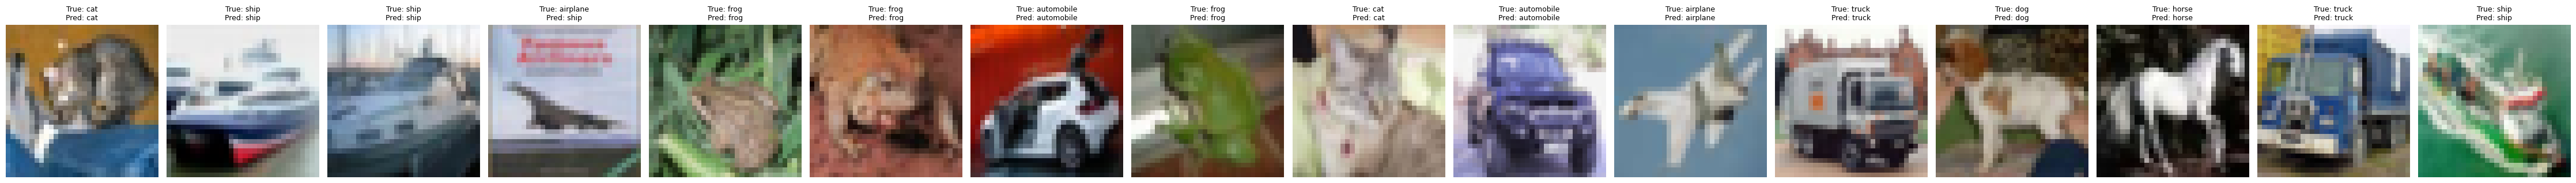

In [155]:
demo_custom_vit_batch(model_custom_vit_mha, test_loader, class_names, device, num_images=16)

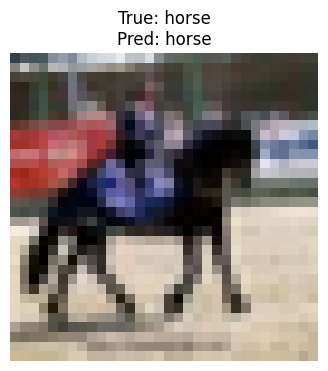

Index        : 5000
Ground truth : horse
Prediction   : horse


In [156]:
predict_one_image_custom_vit(
    model_custom_vit_mha,
    test_dataset,
    index=5000,
    class_names=class_names,
    device=device
)

## 6 Demo cho CNN + Transformer

In [157]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalize stats
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3,1,1)
std  = torch.tensor((0.2470, 0.2435, 0.2616)).view(3,1,1)

def denormalize(img):
    return (img.cpu()*std + mean).clamp(0,1)

@torch.no_grad()
def demo_cnn_transformer_batch(model, test_loader, device, num_images=8):
    model.eval()

    images, labels = next(iter(test_loader))
    images = images.to(device)

    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu()

    plt.figure(figsize=(2.8*num_images,4))
    for i in range(num_images):
        plt.subplot(1,num_images,i+1)
        img = denormalize(images[i]).permute(1,2,0).cpu().numpy()
        plt.imshow(img)

        plt.title(f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def demo_cnn_transformer_one(model, test_dataset, device, index=25):
    model.eval()

    image, label = test_dataset[index]
    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    img = denormalize(image).permute(1,2,0).numpy()

    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print("Index:", index)
    print("True :", class_names[label])
    print("Pred :", class_names[pred])

In [158]:
model_cnn_transformer = CNNTransformerClassifier().to(device)

model_cnn_transformer.load_state_dict(
    torch.load("model_cnn_transformer.pth", map_location=device)
)

model_cnn_transformer.eval()
print("✅ Loaded CNN+Transformer model")

✅ Loaded CNN+Transformer model


/tmp/ipykernel_1081/703188230.py:40: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


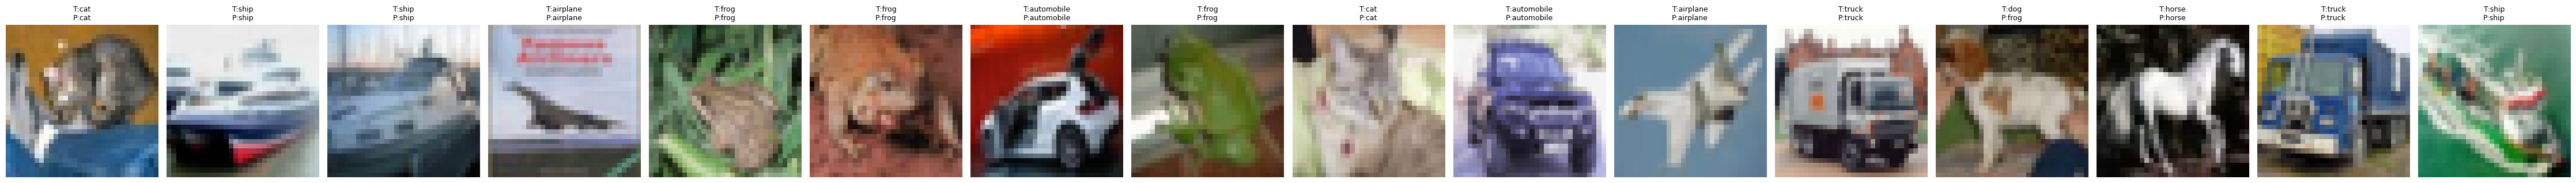

In [159]:
demo_cnn_transformer_batch(model_cnn_transformer, test_loader, device, num_images=16)

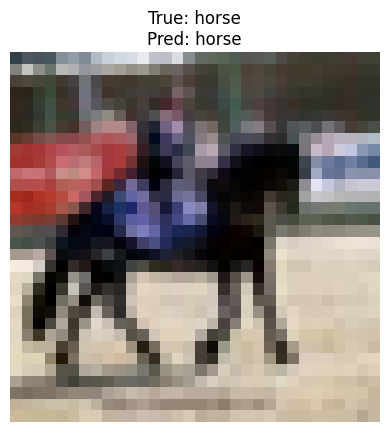

Index: 5000
True : horse
Pred : horse


In [160]:
demo_cnn_transformer_one(model_cnn_transformer, test_dataset, device, index=5000)

## 7 Demo cho Channel as Token

In [161]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalize stats (phải giống lúc train)
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3,1,1)
std  = torch.tensor((0.2470, 0.2435, 0.2616)).view(3,1,1)

def denormalize(img):
    return (img.detach().cpu()*std + mean).clamp(0,1)

@torch.no_grad()
def demo_channel_token_batch(model, test_loader, device, num_images=8):
    """
    Demo nhiều ảnh từ test_loader
    """
    model.eval()

    images, labels = next(iter(test_loader))
    images = images.to(device)   # giữ nguyên [B,3,32,32]

    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu()

    num_images = min(num_images, len(images))

    plt.figure(figsize=(2.8*num_images, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = denormalize(images[i]).permute(1,2,0).numpy()
        plt.imshow(img)

        plt.title(f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def demo_channel_token_one(model, test_dataset, device, index=25):
    """
    Demo 1 ảnh theo index trong test_dataset
    """
    model.eval()

    image, label = test_dataset[index]
    input_tensor = image.unsqueeze(0).to(device)  # KHÔNG flatten

    outputs = model(input_tensor)
    pred = outputs.argmax(dim=1).item()

    img = denormalize(image).permute(1,2,0).numpy()

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print("Index:", index)
    print("True :", class_names[label])
    print("Pred :", class_names[pred])

@torch.no_grad()
def demo_channel_token_from_loader(model, loader, device, batch_index=0, image_index=0):
    """
    Chọn 1 ảnh theo vị trí batch để debug nhanh
    """
    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()

            img = denormalize(image).permute(1,2,0).numpy()

            plt.figure(figsize=(4,4))
            plt.imshow(img)
            plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch: {batch_index}, Image: {image_index}")
            print("True :", class_names[label])
            print("Pred :", class_names[pred])
            return

    print("Không tìm thấy batch_index phù hợp.")

In [162]:
model_channel_as_token = ViT_ChannelAsToken().to(device)

model_channel_as_token.load_state_dict(
    torch.load("model_channel_as_token.pth", map_location=device)
)

model_channel_as_token.eval()
print("✅ Loaded model_channel_as_token.pth")

✅ Loaded model_channel_as_token.pth


/tmp/ipykernel_1081/2917692357.py:39: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


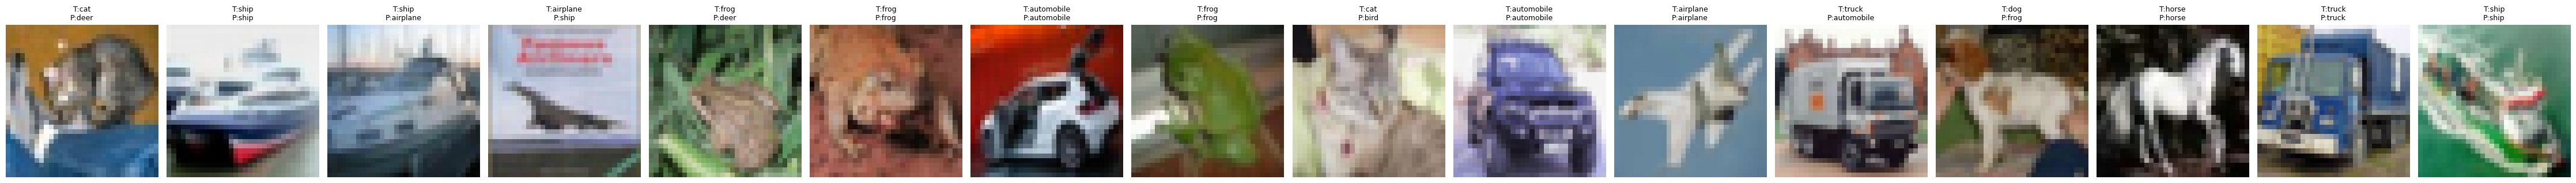

In [163]:
demo_channel_token_batch(model_channel_as_token, test_loader, device, num_images=16)

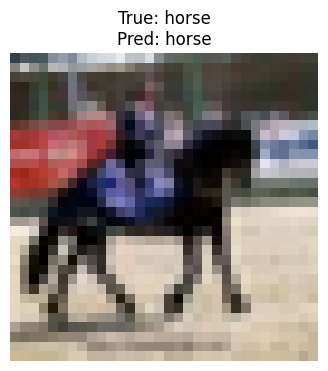

Index: 5000
True : horse
Pred : horse


In [164]:
demo_channel_token_one(model_channel_as_token, test_dataset, device, index=5000)

## 8 Demo cho VIT Overlap Patch

In [165]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalize stats
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3,1,1)
std  = torch.tensor((0.2470, 0.2435, 0.2616)).view(3,1,1)

def denormalize(img):
    return (img.detach().cpu()*std + mean).clamp(0,1)

@torch.no_grad()
def demo_vit_overlap_batch(model, test_loader, device, num_images=8):
    model.eval()

    images, labels = next(iter(test_loader))
    images = images.to(device)   # KHÔNG flatten

    outputs = model(images)
    preds = outputs.argmax(dim=1).cpu()

    num_images = min(num_images, len(images))

    plt.figure(figsize=(2.8*num_images,4))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        img = denormalize(images[i]).permute(1,2,0).numpy()
        plt.imshow(img)

        plt.title(f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


@torch.no_grad()
def demo_vit_overlap_one(model, test_dataset, device, index=25):
    model.eval()

    image, label = test_dataset[index]
    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    img = denormalize(image).permute(1,2,0).numpy()

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print("Index:", index)
    print("True :", class_names[label])
    print("Pred :", class_names[pred])


@torch.no_grad()
def demo_vit_overlap_from_loader(model, loader, device, batch_index=0, image_index=0):
    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).item()

            img = denormalize(image).permute(1,2,0).numpy()

            plt.imshow(img)
            plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch: {batch_index}, Image: {image_index}")
            print("True :", class_names[label])
            print("Pred :", class_names[pred])
            return

    print("Không tìm thấy batch_index phù hợp.")

In [166]:
model_vit_overlap = ViT_OverlapPatch().to(device)

model_vit_overlap.load_state_dict(
    torch.load("model_vit_overlap.pth", map_location=device)
)

model_vit_overlap.eval()
print("✅ Loaded model_vit_overlap.pth")

✅ Loaded model_vit_overlap.pth


/tmp/ipykernel_1081/492479422.py:42: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


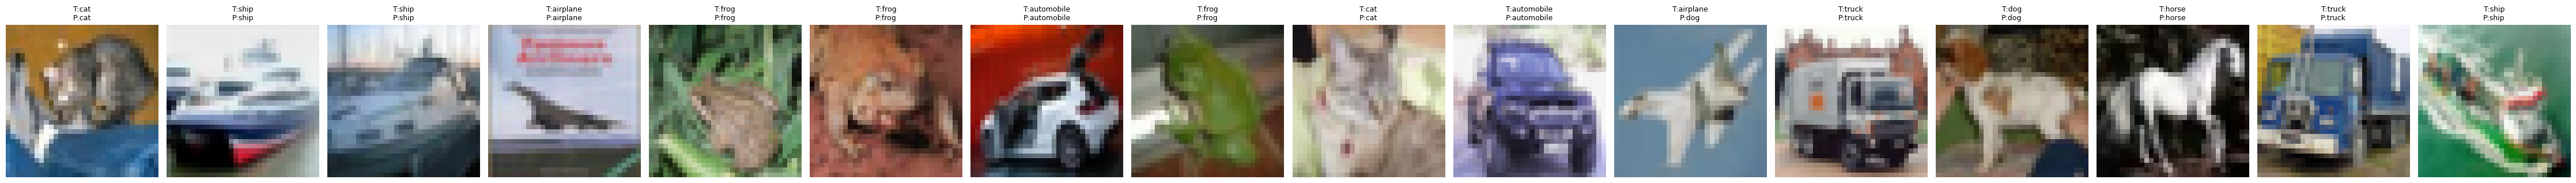

In [167]:
demo_vit_overlap_batch(model_vit_overlap, test_loader, device, num_images=16)

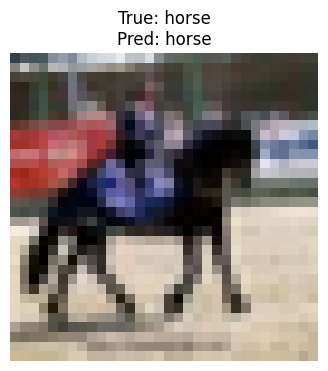

Index: 5000
True : horse
Pred : horse


In [168]:
demo_vit_overlap_one(model_vit_overlap, test_dataset, device, index=5000)

## 9 Demo cho LSTM row wise

In [169]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# CIFAR-10 normalization stats
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

def denormalize_for_show(img_tensor):

    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1)
    return img


@torch.no_grad()
def demo_lstm_row_wise_batch(model, loader, class_names, device, num_images=8):

    model.eval()

    images, labels = next(iter(loader))

    # Pass the original images to the model, let the model handle conversion
    inputs = images.to(device) # Original images

    outputs = model(inputs)
    preds = outputs.argmax(dim=1).cpu()

    num_images = min(num_images, len(images))

    plt.figure(figsize=(2.8 * num_images, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)

        img = denormalize_for_show(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)

        true_name = class_names[labels[i].item()]
        pred_name = class_names[preds[i].item()]
        plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def predict_one_image_lstm_row_wise(model, dataset, index, class_names, device):

    model.eval()

    image, label = dataset[index]

    # Pass the original image to the model, let the model handle conversion
    input_tensor = image.unsqueeze(0).to(device) # Original image, add batch dim

    outputs = model(input_tensor)
    pred = outputs.argmax(dim=1).item()

    img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print(f"Index        : {index}")
    print(f"Ground truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

@torch.no_grad()
def predict_from_loader_position_lstm_row_wise(model, loader, class_names, device, batch_index=0, image_index=0):

    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            input_tensor = image.unsqueeze(0).to(device) # Original image, add batch dim
            outputs = model(input_tensor)
            pred = outputs.argmax(dim=1).item()

            img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

            plt.figure(figsize=(4, 4))
            plt.imshow(img_show)
            plt.title(f"True: {class_names[label.item()]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch index   : {batch_index}")
            print(f"Image index   : {image_index}")
            print(f"Ground truth  : {class_names[label.item()]}")
            print(f"Prediction    : {class_names[pred]}")
            return

    print("Không tìm thấy batch_index phù hợp.")

In [170]:
model_lstm_row_wise = LSTMRowWiseClassifier(
    input_size=96,
    hidden_size=128,
    num_layers=2,
    num_classes=10,
    dropout=0.2
).to(device)

model_lstm_row_wise.load_state_dict(
    torch.load("model_lstm_row_wise.pth", map_location=device)
)

model_lstm_row_wise.eval()
print("Đã nạp model_lstm_row_wise thành công")

Đã nạp model_lstm_row_wise thành công


In [171]:
model_lstm_row_wise = LSTMRowWiseClassifier().to(device)
model_lstm_row_wise.load_state_dict(
    torch.load("model_lstm_row_wise.pth", map_location=device)
)
model_lstm_row_wise.eval()

print("Đã nạp lại model_lstm_row_wise từ model_lstm_row_wise.pth")

Đã nạp lại model_lstm_row_wise từ model_lstm_row_wise.pth


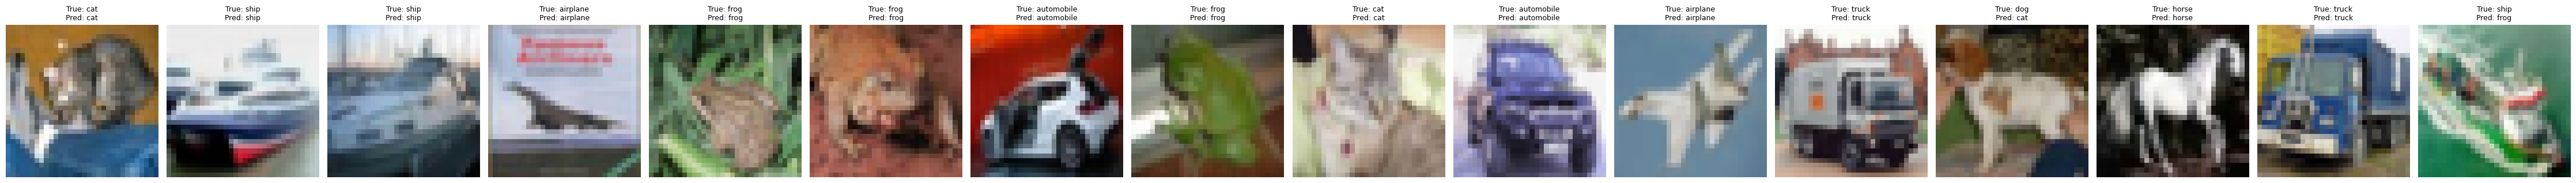

In [172]:
demo_lstm_row_wise_batch(
    model_lstm_row_wise,
    test_loader,
    class_names,
    device,
    num_images=16
)

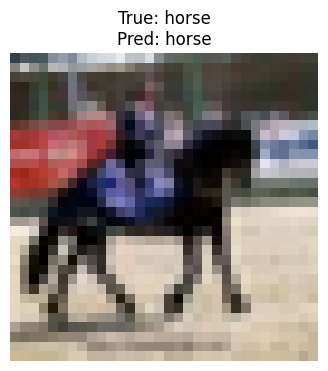

Index        : 5000
Ground truth : horse
Prediction   : horse


In [173]:
predict_one_image_lstm_row_wise(
    model_lstm_row_wise,
    test_dataset,
    index=5000,
    class_names=class_names,
    device=device
)

## 10 Demo cho GRU row wise

In [174]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Normalize stats (phải giống lúc train)
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3,1,1)
std  = torch.tensor((0.2470, 0.2435, 0.2616)).view(3,1,1)

def denormalize(img):
    return (img.detach().cpu()*std + mean).clamp(0,1)


@torch.no_grad()
def demo_gru_row_batch(model, test_loader, device, num_images=8):
    model.eval()

    images, labels = next(iter(test_loader))

    # Pass original images, model's forward method will apply image_to_row_sequence
    inputs = images.to(device)

    outputs = model(inputs)
    preds = outputs.argmax(dim=1).cpu()

    plt.figure(figsize=(2.8*num_images,4))
    for i in range(num_images):
        plt.subplot(1,num_images,i+1)
        img = denormalize(images[i]).permute(1,2,0).numpy()
        plt.imshow(img)

        plt.title(f"T:{class_names[labels[i]]}\nP:{class_names[preds[i]]}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def demo_gru_row_one(model, test_dataset, device, index=25):
    model.eval()

    image, label = test_dataset[index]
    # Pass original image (with batch dim), model's forward method will apply image_to_row_sequence
    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred = output.argmax(dim=1).item()

    img = denormalize(image).permute(1,2,0).numpy()

    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print("Index:", index)
    print("True :", class_names[label])
    print("Pred :", class_names[pred])

@torch.no_grad()
def demo_gru_row_from_loader(model, loader, device, batch_index=0, image_index=0):
    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            # Pass original image (with batch dim), model's forward method will apply image_to_row_sequence
            input_tensor = image.unsqueeze(0).to(device)
            pred = model(input_tensor).argmax(dim=1).item()

            img = denormalize(image).permute(1,2,0).numpy()

            plt.imshow(img)
            plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch {batch_index}, Image {image_index}")
            print("True :", class_names[label])
            print("Pred :", class_names[pred])
            return

    print("Không tìm thấy batch_index phù hợp.")

In [175]:
model_gru_row_wise = GRURowWiseClassifier().to(device)

model_gru_row_wise.load_state_dict(
    torch.load("model_gru_row_wise.pth", map_location=device)
)

model_gru_row_wise.eval()
print("✅ Loaded model_gru_row_wise.pth")

✅ Loaded model_gru_row_wise.pth


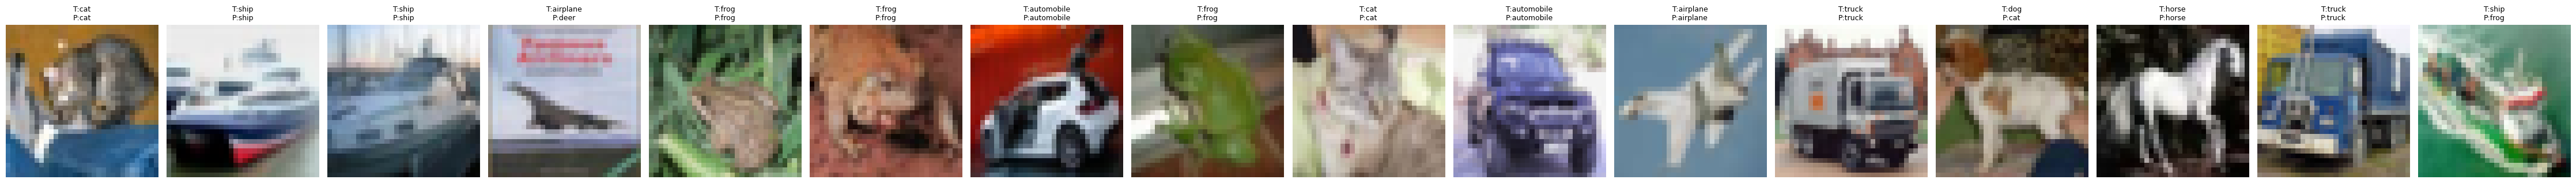

In [176]:
demo_gru_row_batch(model_gru_row_wise, test_loader, device, num_images=16)

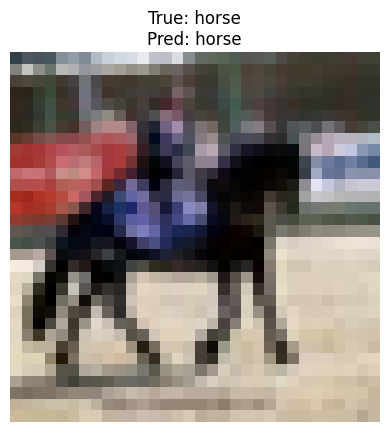

Index: 5000
True : horse
Pred : horse


In [177]:
demo_gru_row_one(model_gru_row_wise, test_dataset, device, index=5000)

## 11 Demo cho LSTM patch wise

In [178]:
import torch
import matplotlib.pyplot as plt

# CIFAR-10 labels
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Thống kê normalize của CIFAR-10
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

def denormalize_for_show(img_tensor):

    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1)
    return img


@torch.no_grad()
def predict_one_image_lstm_patch_wise(model, dataset, index, class_names, device):

    model.eval()

    image, label = dataset[index]
    # Pass the original image to the model, let the model handle conversion
    input_tensor = image.unsqueeze(0).to(device)  # Add batch dimension

    outputs = model(input_tensor)
    pred = outputs.argmax(dim=1).item()

    img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_show)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

    print(f"Index        : {index}")
    print(f"Ground truth : {class_names[label]}")
    print(f"Prediction   : {class_names[pred]}")

@torch.no_grad()
def demo_lstm_patch_wise_batch(model, loader, class_names, device, num_images=8):

    model.eval()

    images, labels = next(iter(loader))
    # Pass the original images to the model, let the model handle conversion
    inputs = images.to(device)  # Pass raw images

    outputs = model(inputs)
    preds = outputs.argmax(dim=1).cpu()

    num_images = min(num_images, len(images))

    plt.figure(figsize=(2.8 * num_images, 4))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        img = denormalize_for_show(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)

        true_name = class_names[labels[i].item()]
        pred_name = class_names[preds[i].item()]
        plt.title(f"True: {true_name}\nPred: {pred_name}", fontsize=9)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

@torch.no_grad()
def predict_from_loader_position_lstm_patch_wise(
    model, loader, class_names, device, batch_index=0, image_index=0
):

    model.eval()

    for b_idx, (images, labels) in enumerate(loader):
        if b_idx == batch_index:
            image = images[image_index]
            label = labels[image_index]

            # Pass the original image to the model, let the model handle conversion
            input_tensor = image.unsqueeze(0).to(device)  # Add batch dimension
            outputs = model(input_tensor)
            pred = outputs.argmax(dim=1).item()

            img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

            plt.figure(figsize=(4, 4))
            plt.imshow(img_show)
            plt.title(f"True: {class_names[label.item()]}\nPred: {class_names[pred]}")
            plt.axis("off")
            plt.show()

            print(f"Batch index   : {batch_index}")
            print(f"Image index   : {image_index}")
            print(f"Ground truth  : {class_names[label.item()]}")
            print(f"Prediction    : {class_names[pred]}")
            return

    print("Không tìm thấy batch_index phù hợp.")

In [179]:
import sys
# Force reload of utils to ensure latest definitions are used
if 'utils' in sys.modules:
    del sys.modules['utils']
from utils import *

print("Reloaded utils.py")

Reloaded utils.py


In [180]:
# 4. Kiểm tra nhanh shape đầu ra
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_lstm_patch_wise = LSTMPatchWiseClassifier(
    patch_size=4,
    input_size=48,
    hidden_size=128,
    num_layers=2,
    num_classes=10,
    dropout=0.2
).to(device)

x = torch.randn(8, 3, 32, 32).to(device)
y = model_lstm_patch_wise(x)

print("Output shape:", y.shape)   # expected: [8, 10]
print(model_lstm_patch_wise)

Output shape: torch.Size([8, 10])
LSTMPatchWiseClassifier(
  (lstm): LSTM(48, 128, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [181]:
model_lstm_patch_wise.load_state_dict(
    torch.load("model_lstm_patch_wise.pth", map_location=device)
)
model_lstm_patch_wise.eval()

print("Đã nạp lại model_lstm_patch_wise từ model_lstm_patch_wise.pth")

Đã nạp lại model_lstm_patch_wise từ model_lstm_patch_wise.pth


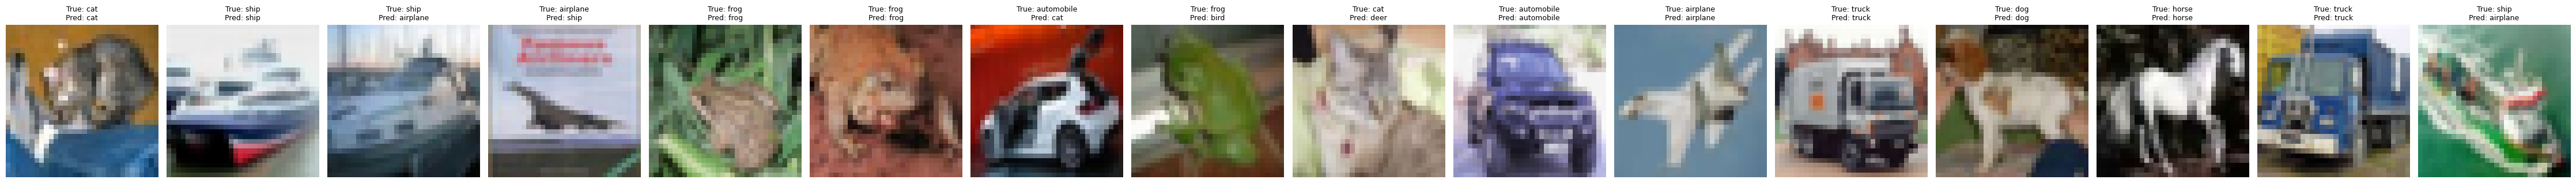

In [182]:
demo_lstm_patch_wise_batch(
    model_lstm_patch_wise,
    test_loader,
    class_names,
    device,
    num_images=16
)

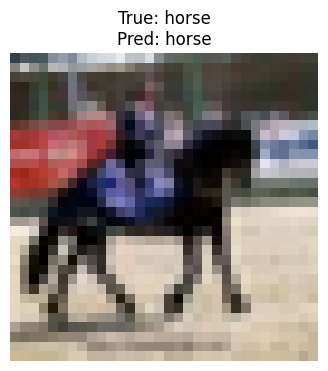

Index        : 5000
Ground truth : horse
Prediction   : horse


In [183]:
predict_one_image_lstm_patch_wise(
    model_lstm_patch_wise,
    test_dataset,
    index=5000,
    class_names=class_names,
    device=device
)

# Demo wtith Gradio

In [184]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import gradio as gr

# 1. Class names CIFAR-10
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# 2. Denormalize để hiển thị ảnh
mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

def denormalize_for_show(img_tensor):
    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1)
    return img

# 3. Patch-wise preprocess (Removed incorrect local definition to avoid shadowing)
# Rely on utils.py version of image_to_patch_sequence

# 4. Model registry
MODEL_REGISTRY = {
    "Softmax": {"model": model_softmax, "mode": "flatten"},
    "MLP": {"model": model_mlp, "mode": "flatten"},
    "CNN": {"model": model_cnn, "mode": "raw"},
    "ViT": {"model": model_vit, "mode": "raw"},
    "Custom ViT": {"model": model_custom_vit_mha, "mode": "raw"},
    "CNN + Transformer": {"model": model_cnn_transformer, "mode": "raw"},
    "Channel as Token": {"model": model_channel_as_token, "mode": "raw"},
    "ViT Overlap Patch": {"model": model_vit_overlap, "mode": "raw"},
    "LSTM row-wise": {"model": model_lstm_row_wise, "mode": "raw"},
    "GRU row-wise": {"model": model_gru_row_wise, "mode": "raw"},
    "LSTM patch-wise": {"model": model_lstm_patch_wise, "mode": "raw"}, # Model handles internal patch sequence conversion
}

# 5. Prepare input
def prepare_input(image, mode):
    if mode == "flatten":
        return image.view(1, -1)
    elif mode == "raw":
        return image.unsqueeze(0)
    elif mode == "patchwise":
        # No longer using a separate image_to_patch_sequence here, model handles it
        raise ValueError("Patchwise mode should be handled by the model itself now.")
    else:
        raise ValueError(f"Mode không hợp lệ: {mode}")

# 6. Inference function
@torch.no_grad()
def run_demo(model_name, index):
    if index is None:
        return None, "Vui lòng nhập index.", "", pd.DataFrame(), ""

    index = int(index)

    if index < 0 or index >= len(test_dataset):
        return None, f"Index không hợp lệ. Hãy nhập trong khoảng 0 đến {len(test_dataset)-1}.", "", pd.DataFrame(), ""

    if model_name not in MODEL_REGISTRY:
        return None, "Không tìm thấy model.", "", pd.DataFrame(), ""

    entry = MODEL_REGISTRY[model_name]
    model = entry["model"]
    mode = entry["mode"]

    model.eval()

    image, label = test_dataset[index]
    input_tensor = prepare_input(image, mode).to(device)

    outputs = model(input_tensor)
    probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
    pred = int(np.argmax(probs))

    top5_idx = np.argsort(probs)[::-1][:5]
    top5_df = pd.DataFrame({
        "Class": [class_names[i] for i in top5_idx],
        "Probability": [float(probs[i]) for i in top5_idx]
    })

    img_show = denormalize_for_show(image).permute(1, 2, 0).numpy()

    true_text = f"{class_names[label]} (label={label})"
    pred_text = f"{class_names[pred]} (label={pred})"

    info_text = (
        f"Model: {model_name}\n"
        f"Index: {index}\n"
        f"Input mode: {mode}\n"
        f"Dataset size: {len(test_dataset)}"
    )

    return img_show, true_text, pred_text, top5_df, info_text

# 7. Giao diện đẹp hơn: Theme + CSS
title = "Demo phân loại ảnh CIFAR-10 với 11 mô hình"
description = (
    f"Chọn mô hình, nhập index ảnh trong khoảng từ 0 đến {len(test_dataset)-1}, "
    f"sau đó bấm nút 'CHẠY DEMO' để xem kết quả dự đoán."
)

custom_css = """
body, .gradio-container {
    background: linear-gradient(135deg, #eef6ff 0%, #f8fbff 50%, #eefafc 100%) !important;
    font-family: "Segoe UI", Arial, sans-serif;
}

.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
}

.main-title {
    text-align: center;
    color: #0f172a;
    font-weight: 800;
    font-size: 34px !important;
    margin-bottom: 4px !important;
}

.main-desc {
    text-align: center;
    color: #334155;
    font-size: 16px !important;
    margin-bottom: 18px !important;
}

.section-card {
    background: rgba(255, 255, 255, 0.92);
    border: 1px solid #dbeafe;
    border-radius: 18px;
    box-shadow: 0 8px 24px rgba(15, 23, 42, 0.08);
    padding: 12px;
}

.control-card {
    background: linear-gradient(180deg, #ffffff 0%, #f7fbff 100%);
    border: 1px solid #cfe3ff;
    border-radius: 18px;
    box-shadow: 0 8px 24px rgba(2, 132, 199, 0.08);
    padding: 12px;
}

.result-card {
    background: linear-gradient(180deg, #ffffff 0%, #f8fcff 100%);
    border: 1px solid #d6eaff;
    border-radius: 18px;
    box-shadow: 0 10px 28px rgba(14, 116, 144, 0.10);
    padding: 12px;
}

button.primary-btn {
    background: linear-gradient(90deg, #0ea5e9 0%, #2563eb 100%) !important;
    color: white !important;
    border: none !important;
    border-radius: 14px !important;
    font-weight: 700 !important;
    font-size: 16px !important;
    min-height: 52px !important;
    box-shadow: 0 8px 18px rgba(37, 99, 235, 0.25) !important;
}

button.primary-btn:hover {
    filter: brightness(1.06);
    transform: translateY(-1px);
    transition: 0.2s ease;
}

label span, .gr-block-label {
    color: #0f172a !important;
    font-weight: 600 !important;
}

textarea, input, .gr-box, .gr-input, .gr-textbox, .gr-dataframe, .gr-image {
    border-radius: 14px !important;
}

.truth-box textarea,
.truth-box input {
    background: #ecfeff !important;
    color: #155e75 !important;
    font-weight: 700 !important;
}

.pred-box textarea,
.pred-box input {
    background: #eff6ff !important;
    color: #1d4ed8 !important;
    font-weight: 700 !important;
}

.info-box textarea,
.info-box input {
    background: #f8fafc !important;
    color: #334155 !important;
}

.top5-box table {
    border-radius: 14px !important;
    overflow: hidden !important;
}

.top5-box thead th {
    background: #dbeafe !important;
    color: #1e3a8a !important;
    font-weight: 700 !important;
}

.top5-box tbody tr:nth-child(odd) {
    background: #f8fbff !important;
}

.top5-box tbody tr:nth-child(even) {
    background: #eef6ff !important;
}
"""

theme = gr.themes.Soft(
    primary_hue="blue",
    secondary_hue="sky",
    neutral_hue="slate",
).set(
    body_background_fill="#f8fbff",
    block_background_fill="#ffffff",
    block_border_color="#dbeafe",
    block_title_text_color="#0f172a",
    block_label_text_color="#1e293b",
    input_background_fill="#ffffff",
    button_primary_background_fill="#2563eb",
    button_primary_background_fill_hover="#1d4ed8",
    button_primary_text_color="#ffffff",
)

with gr.Blocks(theme=theme, css=custom_css) as demo:
    gr.Markdown(f"<div class='main-title'>{title}</div>")
    gr.Markdown(f"<div class='main-desc'>{description}</div>")

    with gr.Column(elem_classes=["control-card"]):
        with gr.Row():
            model_dropdown = gr.Dropdown(
                choices=list(MODEL_REGISTRY.keys()),
                value="Softmax",
                label="Chọn mô hình"
            )
            index_input = gr.Number(
                value=0,
                precision=0,
                label=f"Nhập index ảnh (0 đến {len(test_dataset)-1})"
            )

        run_button = gr.Button("CHẠY DEMO", elem_classes=["primary-btn"])

    with gr.Row():
        with gr.Column(scale=1, elem_classes=["result-card"]):
            image_output = gr.Image(label="Ảnh test", type="numpy")
            top5_output = gr.Dataframe(
                label="Top-5 xác suất",
                interactive=False,
                elem_classes=["top5-box"]
            )

        with gr.Column(scale=1, elem_classes=["result-card"]):
            true_output = gr.Textbox(label="Nhãn thật", elem_classes=["truth-box"])
            pred_output = gr.Textbox(label="Nhãn dự đoán", elem_classes=["pred-box"])
            info_output = gr.Textbox(label="Thông tin", lines=6, elem_classes=["info-box"])

    run_button.click(
        fn=run_demo,
        inputs=[model_dropdown, index_input],
        outputs=[image_output, true_output, pred_output, top5_output, info_output]
    )

demo.launch(share=True)

/tmp/ipykernel_1081/736562693.py:238: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=custom_css) as demo:
/tmp/ipykernel_1081/736562693.py:238: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=custom_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ecabe3e43df9049567.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
